# Lateral-drag form-factor workflow

This notebook builds coastline-only, GIB-only, and combined CICE lateral-drag form-factor files using `shuga.grid.lateral_drag.FormFactors`, then plots regional diagnostics using PyGMT.

The notebook is designed for Gadi paths and the current Antarctic v7.9 coastline / Kaihong Jiao v1.2 grounded-iceberg workflow. Adjust paths and overwrite flags before running.

In [1]:
from __future__ import annotations

import os
import sys
import warnings
from pathlib import Path
from typing import Mapping, Sequence

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from IPython.display import Image, display

xr.set_options(keep_attrs=True)
warnings.filterwarnings('default')

repo_root = Path.home() / 'AFIM' / 'src' / 'mawsons-chest'
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

In [2]:
from shuga.core.types import RunSpec, ClassificationSpec, LateralDragSpec
from shuga.core.paths import ShugaPaths
from shuga.grid.lateral_drag import FormFactors
from shuga import regions

In [3]:
# ------------------------------------------------------------
# PyGMT / GMT diagnostic probes
# ------------------------------------------------------------
from pathlib import Path
import os
import sys
import json
import textwrap
import subprocess
import tempfile
import signal
import inspect

D_probe = Path("/tmp") / f"pygmt_probe_{os.environ.get('USER', 'user')}"
D_probe.mkdir(parents=True, exist_ok=True)

def run_pygmt_probe(name: str, code: str, timeout: int = 90):
    """
    Run a PyGMT probe in a separate Python process.

    This is important because GMT/PyGMT crashes can kill the Jupyter kernel.
    A subprocess crash returns a non-zero return code while leaving this
    notebook alive.

    Common return codes:
      0    : success
      -11  : SIGSEGV / segmentation fault
      -6   : SIGABRT
      -9   : SIGKILL, often memory or scheduler kill
    """
    P_script = D_probe / f"{name}.py"
    P_script.write_text(textwrap.dedent(code), encoding="utf-8")

    env = os.environ.copy()
    env["MPLBACKEND"] = "Agg"
    env["GMT_VERBOSE"] = "d"

    print(f"\n=== PyGMT probe: {name} ===")
    print(f"script: {P_script}")

    proc = subprocess.run(
        [sys.executable, str(P_script)],
        cwd=str(D_probe),
        env=env,
        text=True,
        capture_output=True,
        timeout=timeout,
    )

    print(f"returncode: {proc.returncode}")

    if proc.returncode < 0:
        sig = -proc.returncode
        try:
            print(f"signal: {signal.Signals(sig).name}")
        except Exception:
            print(f"signal: {sig}")

    if proc.stdout:
        print("\n--- stdout ---")
        print(proc.stdout[-6000:])

    if proc.stderr:
        print("\n--- stderr ---")
        print(proc.stderr[-10000:])

    return proc

In [4]:
probe_versions = run_pygmt_probe(
    "00_versions",
    """
    import os, sys, subprocess, inspect
    import numpy as np
    import pygmt

    print("python:", sys.version)
    print("python executable:", sys.executable)
    print("pygmt:", pygmt.__version__)
    print("pygmt path:", pygmt.__file__)
    print("numpy:", np.__version__)
    print("numpy path:", np.__file__)
    print("Figure.colorbar signature:")
    print(inspect.signature(pygmt.Figure.colorbar))
    print("fg_triangle supported:", "fg_triangle" in inspect.signature(pygmt.Figure.colorbar).parameters)

    print("\\npygmt.show_versions():")
    pygmt.show_versions()

    print("\\ngmt --version:")
    subprocess.run(["gmt", "--version"], check=False)

    print("\\ngmt --show-library:")
    subprocess.run(["gmt", "--show-library"], check=False)

    print("\\nselected env vars:")
    for key in ["CONDA_PREFIX", "PYTHONPATH", "LD_LIBRARY_PATH", "GMT_LIBRARY_PATH", "GMT_DATA_SERVER"]:
        print(f"{key}={os.environ.get(key)}")
    """,
)


=== PyGMT probe: 00_versions ===
script: /tmp/pygmt_probe_da1339/00_versions.py
returncode: 0

--- stdout ---
6.5.0
/opt/conda/analysis3-26.02/lib/libgmt.so
python: 3.11.15 | packaged by conda-forge | (main, Mar  5 2026, 16:45:40) [GCC 14.3.0]
python executable: /g/data/xp65/public/apps/med_conda/envs/analysis3-26.02/bin/python
pygmt: v0.15.0
pygmt path: /home/581/da1339/.local/lib/python3.11/site-packages/pygmt/__init__.py
numpy: 1.26.4
numpy path: /g/data/xp65/public/apps/med_conda/envs/analysis3-26.02/lib/python3.11/site-packages/numpy/__init__.py
Figure.colorbar signature:
(self, *, frame=None, cmap=None, position=None, box=None, truncate=None, shading=None, projection=None, equalsize=None, log=None, region=None, verbose=None, scale=None, zfile=None, panel=None, perspective=None, transparency=None, **kwargs)
fg_triangle supported: False

pygmt.show_versions():
PyGMT information:
  version: v0.15.0
System information:
  python: 3.11.15 | packaged by conda-forge | (main, Mar  5 2026

In [ ]:
probe_versions = run_pygmt_probe(
    "00_versions",
    """
    import os, sys, subprocess, inspect
    import numpy as np
    import pygmt

    print("python:", sys.version)
    print("python executable:", sys.executable)
    print("pygmt:", pygmt.__version__)
    print("pygmt path:", pygmt.__file__)
    print("numpy:", np.__version__)
    print("numpy path:", np.__file__)
    print("Figure.colorbar signature:")
    print(inspect.signature(pygmt.Figure.colorbar))
    print("fg_triangle supported:", "fg_triangle" in inspect.signature(pygmt.Figure.colorbar).parameters)

    print("\\npygmt.show_versions():")
    pygmt.show_versions()

    print("\\ngmt --version:")
    subprocess.run(["gmt", "--version"], check=False)

    print("\\ngmt --show-library:")
    subprocess.run(["gmt", "--show-library"], check=False)

    print("\\nselected env vars:")
    for key in ["CONDA_PREFIX", "PYTHONPATH", "LD_LIBRARY_PATH", "GMT_LIBRARY_PATH", "GMT_DATA_SERVER"]:
        print(f"{key}={os.environ.get(key)}")
    """,
)

In [ ]:
probe_basic = run_pygmt_probe(
    "01_basic_basemap",
    """
    import pygmt

    fig = pygmt.Figure()
    fig.basemap(region=[0, 1, 0, 1], projection="X8c/5c", frame=True)
    fig.text(x=0.5, y=0.5, text="basic ok", font="12p,Helvetica,black", justify="CM")
    fig.savefig("01_basic_basemap.png")
    print("wrote 01_basic_basemap.png")
    """,
)

probe_makecpt = run_pygmt_probe(
    "02_makecpt_background_o",
    """
    import pygmt

    pygmt.makecpt(
        cmap="cmocean/matter",
        series=[0, 3],
        continuous=True,
        background="o",
    )
    print("makecpt ok")
    """,
)

probe_colorbar_no_triangle = run_pygmt_probe(
    "03_colorbar_no_triangle",
    """
    import numpy as np
    import pygmt

    x = np.linspace(0.1, 0.9, 20)
    y = np.linspace(0.1, 0.9, 20)
    z = np.linspace(0, 5, 20)  # intentionally > 3

    fig = pygmt.Figure()
    fig.basemap(region=[0, 1, 0, 1], projection="X8c/5c", frame=True)
    pygmt.makecpt(cmap="cmocean/matter", series=[0, 3], continuous=True, background="o")
    fig.plot(x=x, y=y, style="c0.12c", fill=z, cmap=True, pen=None)
    fig.colorbar(frame="xaf+lFF magnitude")
    fig.savefig("03_colorbar_no_triangle.png")
    print("wrote 03_colorbar_no_triangle.png")
    """,
)

probe_colorbar_fg_triangle = run_pygmt_probe(
    "04_colorbar_fg_triangle",
    """
    import numpy as np
    import pygmt

    x = np.linspace(0.1, 0.9, 20)
    y = np.linspace(0.1, 0.9, 20)
    z = np.linspace(0, 5, 20)  # intentionally > 3

    fig = pygmt.Figure()
    fig.basemap(region=[0, 1, 0, 1], projection="X8c/5c", frame=True)
    pygmt.makecpt(cmap="cmocean/matter", series=[0, 3], continuous=True, background="o")
    fig.plot(x=x, y=y, style="c0.12c", fill=z, cmap=True, pen=None)
    fig.colorbar(frame="xaf+lFF magnitude", fg_triangle=True)
    fig.savefig("04_colorbar_fg_triangle.png")
    print("wrote 04_colorbar_fg_triangle.png")
    """,
)

In [ ]:
probe_south_polar = run_pygmt_probe(
    "05_south_polar_coast_colorbar_triangle",
    """
    import numpy as np
    import pygmt

    rng = np.random.default_rng(0)
    lon = rng.uniform(-180, 180, 5000)
    lat = rng.uniform(-80, -62, 5000)
    z = rng.uniform(0, 8, 5000)

    fig = pygmt.Figure()
    fig.basemap(region=[-180, 180, -90, -60], projection="S0/-90/20c", frame=["af", "+tprobe"])
    pygmt.makecpt(cmap="cmocean/matter", series=[0, 3], continuous=True, background="o")
    fig.coast(shorelines="0.4p,black", land="lightgray", water="white")
    fig.plot(x=lon, y=lat, style="s0.05c", fill=z, cmap=True, pen=None)
    fig.colorbar(frame="xaf+lFF magnitude", fg_triangle=True)
    fig.savefig("05_south_polar_coast_colorbar_triangle.png")
    print("wrote 05_south_polar_coast_colorbar_triangle.png")
    """,
    timeout=120,
)

In [ ]:
probe_gib_points_only = run_pygmt_probe(
    "06_south_polar_gib_points_only",
    f"""
    from pathlib import Path
    import numpy as np
    import geopandas as gpd
    import pygmt

    P_GIB = Path({str(GIB_SPECS[gib_ver])!r})

    gdf = gpd.read_file(P_GIB)
    if gdf.crs is None:
        gdf = gdf.set_crs(4326)
    gdf = gdf.to_crs(4326)

    bounds = gdf.bounds
    gdf = gdf.loc[bounds["miny"].to_numpy() <= -60.0].copy()
    pts = gdf.geometry.representative_point()

    lon = np.asarray(pts.x, dtype="float64")
    lat = np.asarray(pts.y, dtype="float64")

    print("n GIB points:", lon.size)
    print("lon range:", np.nanmin(lon), np.nanmax(lon))
    print("lat range:", np.nanmin(lat), np.nanmax(lat))

    fig = pygmt.Figure()
    fig.basemap(region=[-180, 180, -90, -60], projection="S0/-90/20c", frame=["af", "+tGIB point probe"])
    fig.coast(shorelines="0.4p,black", land="lightgray", water="white")
    fig.plot(x=lon, y=lat, style="c0.025c", fill="dodgerblue", pen=None, transparency=30)
    fig.savefig("06_south_polar_gib_points_only.png")
    print("wrote 06_south_polar_gib_points_only.png")
    """,
    timeout=180,
)

## Configuration

Set the form-factor input/output paths and instantiate the `FormFactors` builder.

In [10]:
PROJECT    = 'gv90'
USER       = 'da1339'
HEMISPHERE = 'SH'
ICE_TYPE   = 'FI'
GRID_TYPE  = 'Tc'

ISPD_THRESH  = 5.0e-4
BIN_WINDOW   = 11
BIN_MIN_DAYS = 9
ROLL_WINDOW  = 15

OVERWRITE_COAST    = False
OVERWRITE_GIB      = False
OVERWRITE_COMBINED = True

D_root = Path('/g/data/gv90/da1339')
D_FF   = D_root / 'form_factors'
D_cst  = D_root / 'coastlines' / 'high_res_coast'
D_GIB  = D_root / 'grounded_icebergs' / 'Kaihong_Jiao'
D_FF.mkdir(parents=True, exist_ok=True)

P_Hres_cst = D_cst / 'add_coastline_high_res_polygon_v7_9.shp'

GIB_SPECS = {'v0p9': D_GIB / 'Antarctic_Grounded_Iceberg_Dataset_Sentinel1_v0.9.gpkg',
             'v1p0': D_GIB / 'Antarctic_Grounded_Iceberg_Dataset_Sentinel1_v1.0.gpkg',
             'v1p1': D_GIB / 'Antarctic_Grounded_Iceberg_Dataset_Sentinel1_v1.1.gpkg',
             'v1p2': D_GIB / 'Antarctic_Grounded_Iceberg_Dataset_Sentinel1_v1.2.gpkg'}

cst_ver  = 'v7p9'
gib_ver  = 'v1p2'
cmb_meth = 'max'

P_FF_cst = D_FF / f'FF_ADD-Hres-cst-{cst_ver}_Liu_CICE.nc'
P_FF_gib = D_FF / f'FF_GIB-{gib_ver}_perimeter_Liu_CICE.nc'
P_FF_cmb = D_FF / f'FF_combined_meth-{cmb_meth}_cst-{cst_ver}-Liu_GIB-{gib_ver}-perimeter_Liu_CICE.nc'

D_root_out = Path('/g/data/gv90/da1339/GRAPHICAL/LD-pub-workspace/form-factors')

SH_REGION     = [-180, 180, -90, -60]
SH_PROJECTION = 'S0/-90/20c'
REGION_WIDTH_CM = 16
CPT_CMAP   = 'cmocean/matter'
CPT_SERIES = [0, 3]
POINT_STYLE = 's0.125c'

SHOW_GIB_POINTS_ON_CST = False
SHOW_GIB_POINTS_ON_GIB = True
SHOW_GIB_POINTS_ON_CMB = True

GIB_POINT_STYLE        = "c0.01c"
GIB_POINT_FILL         = "dodgerblue"
GIB_POINT_PEN          = "0.15p,white"
GIB_POINT_TRANSPARENCY = 10

# Keep the displayed FF magnitude colour range fixed.
# Values > 3 are intentionally plotted using the saturated foreground colour.
CPT_CMAP   = "cmocean/matter"
CPT_SERIES = [0, 3]
CPT_FG_TRIANGLE = True

ANTARCTIC_REGIONS = regions.ANTARCTIC_8_REGIONS
ALL_REGIONS = ['SH'] + list(ANTARCTIC_REGIONS.keys())
print(ALL_REGIONS)

run_cfg = RunSpec(
    sim_name   = 'LD-static-Cs1e-3',
    start_date = '1999-01-01',
    end_date   = '1999-12-31',
    hemisphere = HEMISPHERE,
    project    = PROJECT,
    user       = USER,
)

cls_cfg = ClassificationSpec(
    ice_type     = ICE_TYPE,
    grid_type    = GRID_TYPE,
    ispd_thresh  = ISPD_THRESH,
    methods      = ('binary-days',),
    bin_window   = BIN_WINDOW,
    bin_min_days = BIN_MIN_DAYS,
    roll_window  = ROLL_WINDOW,
)

pth_cfg = ShugaPaths(run_cfg=run_cfg, cls_cfg=cls_cfg)
LD_cfg  = LateralDragSpec()
FF      = FormFactors(pth_cfg=pth_cfg, LD_cfg=LD_cfg)

['SH', 'DML', 'WIO', 'EIO', 'Aus', 'VOL', 'AS', 'BS', 'WS']


## Build form-factor products

These cells generate the coastline-only, GIB-only, and combined NetCDF files. For Liu-style length-density fields, keep `clip_max=None` unless you are deliberately running a bounded sensitivity experiment.

In [ ]:
ds_coast = FF.build_FF_from_Hres_coast_Liu(
    P_Hres_cst       = P_Hres_cst,
    P_out            = P_FF_cst,
    source_lat_limit = -60.0,
    overwrite        = OVERWRITE_COAST,
    clip_max         = None,
)

FF.assert_CICE_F2_file_compatibility(P_FF_cst, nx_global=1440, ny_global=1080)

In [ ]:
ds_gib = FF.build_FF_from_GIB_perimeter(
    P_GIB                 = GIB_SPECS[gib_ver],
    P_out                 = P_FF_gib,
    overwrite             = OVERWRITE_GIB,
    include_area_fraction = True,
    area_component_mode   = 'diagnostic',
    clip_max              = None,
)

FF.assert_CICE_F2_file_compatibility(P_FF_gib, nx_global=1440, ny_global=1080)

In [ ]:
ds_cmb = FF.build_FF_combined_CICE(
    P_FF_cst          = P_FF_cst,
    P_FF_GIB          = P_FF_gib,
    P_out             = P_FF_cmb,
    FF_combine_method = cmb_meth,
    overwrite         = OVERWRITE_COMBINED,
    clip_max          = None,
)

FF.assert_CICE_F2_file_compatibility(P_FF_cmb, nx_global=1440, ny_global=1080)

## Quick product summaries

In [ ]:
for path in [P_FF_cst, P_FF_gib, P_FF_cmb]:
    ds = xr.open_dataset(path)
    try:
        print('\n' + '=' * 80)
        print(path)
        print(ds)
        print('FFx max:', float(ds['FFx'].max()))
        print('FFy max:', float(ds['FFy'].max()))
        print('nonzero:', int(((ds['FFx'] > 0) | (ds['FFy'] > 0)).sum()))
        print('diagnostics:', [v for v in ds.data_vars if v not in {'FFx', 'FFy', 'lon', 'lat'}])
    finally:
        ds.close()


## Plotting helpers

The helper cell below is copied from the current PyGMT workflow: plot $|F_{2xy}|$, annotate regional diagnostics, and save one PNG per Antarctic region. If this stabilises, it should move into `shuga/plotting/lateral_drag.py`.

In [11]:
def load_form_factor_dataset(path: Path | str) -> xr.Dataset:
    """Open a form-factor dataset eagerly so the file can be closed safely."""
    with xr.open_dataset(path) as ds:
        return ds.load()


def first_present(ds: xr.Dataset, candidates: list[str]) -> str | None:
    for name in candidates:
        if name in ds:
            return name
    return None


def form_factor_magnitude(ds: xr.Dataset) -> xr.DataArray:
    """Infer $|F_{2xy}|$ from FFx/FFy-like variables."""
    candidates_x = ["FFx", "F2x", "F2E", "F2N_x", "F2_x"]
    candidates_y = ["FFy", "F2y", "F2N", "F2E_y", "F2_y"]
    x = first_present(ds, candidates_x)
    y = first_present(ds, candidates_y)
    if x and y:
        return xr.apply_ufunc(np.hypot, ds[x], ds[y], dask="allowed").rename("FFmag")
    if x:
        return abs(ds[x]).rename("FFmag")
    raise KeyError(f"Could not infer form-factor component fields from {list(ds.data_vars)}")


def infer_lonlat_names(ds: xr.Dataset) -> tuple[str, str]:
    lon_name = first_present(ds, ["lon", "TLON", "ULON", "NLON"])
    lat_name = first_present(ds, ["lat", "TLAT", "ULAT", "NLAT"])
    if lon_name is None or lat_name is None:
        raise KeyError("Need lon/lat variables in form-factor dataset.")
    return lon_name, lat_name


def lon_to_180(lon):
    lon = np.asarray(lon, dtype="float64")
    return ((lon + 180.0) % 360.0) - 180.0


def lon_to_360(lon):
    lon = np.asarray(lon, dtype="float64")
    return lon % 360.0


def central_meridian_from_region(region):
    lon_min, lon_max, *_ = region
    if lon_min <= lon_max:
        return 0.5 * (lon_min + lon_max)
    lon_min_360 = lon_min % 360.0
    lon_max_360 = (lon_max % 360.0) + 360.0
    mc = 0.5 * (lon_min_360 + lon_max_360)
    if mc > 180.0:
        mc -= 360.0
    return mc


def region_plot_params(region_name: str, ANTARCTIC_REGIONS):
    if region_name == "SH":
        return SH_REGION, SH_PROJECTION, False, SH_REGION
    info = ANTARCTIC_REGIONS[region_name]
    plot_region = list(info["plot_region"])
    lon_min, lon_max, lat_min, lat_max = plot_region
    cross_dateline = lon_min > lon_max
    mc = central_meridian_from_region(plot_region)
    projection_template = info.get("projection", "S{MC}/-90/{fig_size}c")
    proj = projection_template.format(MC=f"{mc:g}", fig_size=f"{REGION_WIDTH_CM:g}")
    if cross_dateline:
        lon_min_360 = lon_min % 360.0
        lon_max_360 = (lon_max % 360.0) + 360.0
        plot_region = [lon_min_360, lon_max_360, lat_min, lat_max]
    return plot_region, proj, cross_dateline, [lon_min, lon_max, lat_min, lat_max]


def region_keep_mask(lon, lat, val, region_name: str, ANTARCTIC_REGIONS):
    plot_region, proj, cross_dateline, bounds = region_plot_params(region_name, ANTARCTIC_REGIONS)
    lon = np.asarray(lon)
    lat = np.asarray(lat)
    val = np.asarray(val)
    finite = np.isfinite(lon) & np.isfinite(lat) & np.isfinite(val) & (val > 0)
    if region_name == "SH":
        lon_plot = lon_to_180(lon)
        keep = finite & (lat >= SH_REGION[2]) & (lat <= SH_REGION[3])
        return keep, lon_plot, plot_region, proj
    lon_min, lon_max, lat_min, lat_max = bounds
    if cross_dateline:
        lon_plot = lon_to_360(lon)
        lon_min_360 = lon_min % 360.0
        lon_max_360 = (lon_max % 360.0) + 360.0
        lon_work = lon_plot.copy()
        lon_work[lon_work < lon_min_360] += 360.0
        keep = finite & (lon_work >= lon_min_360) & (lon_work <= lon_max_360) & (lat >= lat_min) & (lat <= lat_max)
        return keep, lon_work, plot_region, proj
    lon_plot = lon_to_180(lon)
    keep = finite & (lon_plot >= lon_min) & (lon_plot <= lon_max) & (lat >= lat_min) & (lat <= lat_max)
    return keep, lon_plot, plot_region, proj


def diagnostic_vars_for_product(product_kind: str) -> list[str]:
    product_kind = str(product_kind).lower().replace("_", "-")
    if product_kind in {"cst-only", "cst", "coast", "coast-only"}:
        return ["coast_n_source_hits"]
    if product_kind in {"gib-only", "gib", "gib-perimeter"}:
        return ["GIB_area_frac", "GIB_n_perimeter_hits"]
    if product_kind in {"cmb", "combined", "combine"}:
        return ["coast_n_source_hits", "GIB_area_frac", "GIB_n_perimeter_hits"]
    raise ValueError(f"Unknown product_kind: {product_kind}")


def _as_flat_region_samples(ds: xr.Dataset, varname: str, region_name: str, ANTARCTIC_REGIONS):
    if varname not in ds:
        return np.array([]), np.array([]), np.array([])
    lon_name, lat_name = infer_lonlat_names(ds)
    lon = ds[lon_name].values.ravel()
    lat = ds[lat_name].values.ravel()
    val = ds[varname].values.ravel()
    keep, _, _, _ = region_keep_mask(lon, lat, val, region_name, ANTARCTIC_REGIONS)
    vv = np.asarray(val[keep], dtype="float64")
    llon = lon_to_180(np.asarray(lon[keep], dtype="float64"))
    llat = np.asarray(lat[keep], dtype="float64")
    good = np.isfinite(vv) & np.isfinite(llon) & np.isfinite(llat) & (vv > 0)
    return vv[good], llon[good], llat[good]


def _fmt_lonlat(lon: float, lat: float) -> str:
    if not np.isfinite(lon) or not np.isfinite(lat):
        return "nan,nan"
    lon_hemi = "E" if lon >= 0 else "W"
    lat_hemi = "N" if lat >= 0 else "S"
    return f"{abs(lon):.2f}{lon_hemi}, {abs(lat):.2f}{lat_hemi}"


def _regional_max_with_location(vv, llon, llat):
    if vv.size == 0:
        return np.nan, np.nan, np.nan
    imax = int(np.nanargmax(vv))
    return float(vv[imax]), float(llon[imax]), float(llat[imax])


def _fmt_stat_value(x: float, varname: str) -> str:
    if not np.isfinite(x):
        return "nan"
    if varname in {"GIB_area_frac"}:
        return f"{x:.3g}"
    if "hits" in varname:
        return f"{x:.0f}"
    if abs(x) >= 1.0e4 or (0 < abs(x) < 1.0e-2):
        return f"{x:.2e}"
    return f"{x:.3g}"


def _diagnostic_single_line(ds, varname, region_name, ANTARCTIC_REGIONS, label_map, include_missing=False):
    if varname not in ds:
        return f"{label_map.get(varname, varname)}: missing" if include_missing else None
    vv, llon, llat = _as_flat_region_samples(ds, varname, region_name, ANTARCTIC_REGIONS)
    lab = label_map.get(varname, varname)
    if vv.size == 0:
        return f"{lab}: n=0"
    vmax, vmax_lon, vmax_lat = _regional_max_with_location(vv, llon, llat)
    p95 = float(np.nanpercentile(vv, 95))
    vsum = float(np.nansum(vv))
    return (f"{lab}: n={vv.size:,}, max={_fmt_stat_value(vmax, varname)} at {_fmt_lonlat(vmax_lon, vmax_lat)}, "
            f"p95={_fmt_stat_value(p95, varname)}, sum={_fmt_stat_value(vsum, varname)}")


def region_diagnostic_stats_text(ds, region_name, ANTARCTIC_REGIONS, product_kind, diagnostics=None, include_missing=False):
    if diagnostics is None:
        diagnostics = diagnostic_vars_for_product(product_kind)
    label_map = {
        "coast_n_source_hits": "CST hits",
        "GIB_area_frac": "GIB area frac",
        "GIB_n_perimeter_hits": "GIB perim hits",
    }
    raw_lines = []
    for v in list(diagnostics):
        line = _diagnostic_single_line(ds, v, region_name, ANTARCTIC_REGIONS, label_map, include_missing)
        if line is not None:
            raw_lines.append(line)
    if len(raw_lines) <= 2:
        return raw_lines
    return [raw_lines[0], " | ".join(raw_lines[1:])]


def _middle_lon_from_plot_lons(lons: Sequence[float]) -> float:
    return 0.5 * (float(lons[0]) + float(lons[1]))


def diagnostic_text_xy(region_name: str, lons: Sequence[float], lats: Sequence[float]) -> tuple[float, float]:
    if str(region_name).upper() == "SH":
        return 0.0, -90.0
    x = _middle_lon_from_plot_lons(lons)
    y = float(lats[0]) - 1.0
    return x, y


def add_region_diagnostic_text(fig, ds, region_name, ANTARCTIC_REGIONS, product_kind, diagnostics=None,
                               lons=None, lats=None, font="12p,Helvetica,black", fill="white@15",
                               pen="0.25p,black", clearance="0.08c/0.08c", justify="CM",
                               no_clip=True, line_lat_offset_deg=0.5, debug=False):
    if lons is None or lats is None:
        raise ValueError("Pass lons=plot_region[0:2], lats=plot_region[2:4].")
    lines = region_diagnostic_stats_text(ds, region_name, ANTARCTIC_REGIONS, product_kind, diagnostics)
    if not lines:
        return
    x_text, y_text = diagnostic_text_xy(region_name, lons, lats)
    if debug:
        print(f"text figure base position: {x_text},{y_text}")
        for k, line in enumerate(lines):
            print(f"diagnostic line {k + 1}: {line}")
    for k, line in enumerate(lines):
        y_line = y_text - k * float(line_lat_offset_deg)
        kwargs = dict(x=x_text, y=y_line, text=line, font=font, justify=justify, no_clip=no_clip)
        if fill is not None:
            kwargs["fill"] = fill
        if pen is not None:
            kwargs["pen"] = pen
        if clearance is not None:
            kwargs["clearance"] = clearance
        fig.text(**kwargs)

def load_gib_location_points(P_GIB: str | Path,
                             hemisphere: str = "SH",
                             source_lat_limit: float | None = -60.0) -> pd.DataFrame:
    """
    Load original grounded-iceberg locations from the source GPKG/SHP/GeoJSON file.

    The Kaihong Jiao GIB product is polygon geometry. For plotting small
    location markers, we use Shapely's representative_point(), which returns a
    point guaranteed to lie within each polygon. This is more robust for
    plotting than a centroid for very irregular polygons.

    Returns
    -------
    pd.DataFrame
        Columns:
            gib_id
            lon
            lat
    """
    import geopandas as gpd

    P_GIB = Path(P_GIB)

    gdf = gpd.read_file(P_GIB)

    if gdf.empty:
        raise RuntimeError(f"No GIB features found in: {P_GIB}")

    if gdf.crs is None:
        gdf = gdf.set_crs(4326)

    gdf_ll = gdf.to_crs(4326)

    # Optional polar-domain source filter. This keeps the plotting overlay
    # consistent with the form-factor generation workflow.
    if source_lat_limit is not None:
        bounds = gdf_ll.bounds

        if str(hemisphere).upper() in {"SH", "S", "SOUTH", "ANT", "ANTARCTIC"}:
            keep = bounds["miny"].to_numpy() <= float(source_lat_limit)
        else:
            keep = bounds["maxy"].to_numpy() >= float(source_lat_limit)

        gdf_ll = gdf_ll.loc[keep].copy()

    if gdf_ll.empty:
        raise RuntimeError(
            f"No GIB features remain after source_lat_limit={source_lat_limit}"
        )

    pts = gdf_ll.geometry.representative_point()

    out = pd.DataFrame(
        {
            "gib_id": np.arange(len(gdf_ll), dtype=np.int64),
            "lon": np.asarray(pts.x, dtype="float64"),
            "lat": np.asarray(pts.y, dtype="float64"),
        }
    )

    out = out[np.isfinite(out["lon"]) & np.isfinite(out["lat"])].reset_index(drop=True)

    return out

def region_keep_points_mask(lon, lat, region_name: str, ANTARCTIC_REGIONS):
    """
    Region mask for point overlays.

    This mirrors region_keep_mask(), but does not require a positive data value.
    It also returns longitudes in the plotting convention needed for the map,
    including dateline-crossing regional plots.
    """
    plot_region, proj, cross_dateline, bounds = region_plot_params(region_name, ANTARCTIC_REGIONS)
    lon = np.asarray(lon, dtype="float64")
    lat = np.asarray(lat, dtype="float64")
    finite = np.isfinite(lon) & np.isfinite(lat)
    if region_name == "SH":
        lon_plot = lon_to_180(lon)
        keep = finite & (lat >= SH_REGION[2]) & (lat <= SH_REGION[3])
        return keep, lon_plot
    lon_min, lon_max, lat_min, lat_max = bounds
    if cross_dateline:
        lon_plot = lon_to_360(lon)
        lon_min_360 = lon_min % 360.0
        lon_max_360 = (lon_max % 360.0) + 360.0
        lon_work = lon_plot.copy()
        lon_work[lon_work < lon_min_360] += 360.0
        keep = (finite & (lon_work >= lon_min_360) & (lon_work <= lon_max_360) & (lat >= lat_min) & (lat <= lat_max))
        return keep, lon_work
    lon_plot = lon_to_180(lon)
    keep = (finite & (lon_plot >= lon_min) & (lon_plot <= lon_max) & (lat >= lat_min) & (lat <= lat_max))
    return keep, lon_plot

def add_gib_location_points(fig,
                            gib_points: pd.DataFrame,
                            region_name: str,
                            ANTARCTIC_REGIONS,
                            style: str = GIB_POINT_STYLE,
                            fill: str = GIB_POINT_FILL,
                            pen: str = GIB_POINT_PEN,
                            transparency: float | int | None = GIB_POINT_TRANSPARENCY,
                            debug: bool = False):
    """
    Add original grounded-iceberg source locations as point overlays.

    The expected input is the DataFrame returned by load_gib_location_points().
    """
    if gib_points is None or len(gib_points) == 0:
        return
    keep, lon_plot = region_keep_points_mask(gib_points["lon"].to_numpy(), gib_points["lat"].to_numpy(),
                                             region_name       = region_name,
                                             ANTARCTIC_REGIONS = ANTARCTIC_REGIONS)
    n_keep = int(np.count_nonzero(keep))
    if debug:
        print(f"GIB point overlay: region={region_name}, n={n_keep:,}")
    if n_keep == 0:
        return
    kwargs = dict(x = lon_plot[keep], y = gib_points["lat"].to_numpy()[keep], style = style, fill = fill, pen = pen)
    if transparency is not None:
        kwargs["transparency"] = transparency
    fig.plot(**kwargs)

def plot_form_factor_pygmt(ds              : xr.Dataset,
                           out             : Path | None = None,
                           title           : str = "Combined lateral-drag form factor",
                           region_name     : str = "SH",
                           ANTARCTIC_REGIONS = None,
                           product_kind    : str = "cmb",
                           diagnostics     : list[str] | None = None,
                           show_diagnostics: bool = True,
                           gib_points      : pd.DataFrame | None = None,
                           show_gib_points : bool = False,
                           cpt_cmap        : str = CPT_CMAP,
                           cpt_series      : Sequence[float] = CPT_SERIES,
                           cpt_fg_triangle : bool = CPT_FG_TRIANGLE):
    import pygmt
    if ANTARCTIC_REGIONS is None:
        ANTARCTIC_REGIONS = {}
    fmag = form_factor_magnitude(ds)
    lon_name, lat_name = infer_lonlat_names(ds)
    lon = ds[lon_name].values.ravel()
    lat = ds[lat_name].values.ravel()
    val = fmag.values.ravel()
    keep, lon_plot, plot_region, proj = region_keep_mask(lon, lat, val, region_name, ANTARCTIC_REGIONS)
    fig = pygmt.Figure()
    fig.basemap(region = plot_region, projection = proj, frame = ["af", f"+t{title}"])
    # Build a fixed-range CPT. Values above cpt_series[-1] are not clipped;
    # they are painted with the CPT foreground colour. background="o" sets
    # the foreground/background colours to the output CPT end colours, so
    # >3 values are visually saturated at the 3-end colour.
    pygmt.makecpt(cmap = cpt_cmap, series = list(cpt_series), background = "o")
    fig.coast(shorelines = "0.4p,black", land = "lightgray", water = "white")
    # Do NOT clip val to [0, 3]. Values >3 should go through to GMT so
    # they use the foreground colour and are advertised by the colourbar
    # foreground triangle.
    fig.plot(x = lon_plot[keep], y = lat[keep], style = POINT_STYLE, fill = val[keep], cmap = True, pen = None)
    if show_gib_points and gib_points is not None:
        add_gib_location_points(fig               = fig,
                                gib_points        = gib_points,
                                region_name       = region_name,
                                ANTARCTIC_REGIONS = ANTARCTIC_REGIONS,
                                style             = GIB_POINT_STYLE,
                                fill              = GIB_POINT_FILL,
                                pen               = GIB_POINT_PEN,
                                transparency      = GIB_POINT_TRANSPARENCY,
                                debug             = False)

    fig.colorbar(frame = "xaf+l@[|F_{2xy}|@[")#, fg_triangle = bool(cpt_fg_triangle))
    if show_diagnostics:
        add_region_diagnostic_text(fig               = fig,
                                   ds                = ds,
                                   region_name       = region_name,
                                   ANTARCTIC_REGIONS = ANTARCTIC_REGIONS,
                                   product_kind      = product_kind,
                                   diagnostics       = diagnostics,
                                   lons              = plot_region[0:2],
                                   lats              = plot_region[2:4],
                                   font              = "12p,Helvetica,black",
                                   fill              = "white@15",
                                   pen               = "0.25p,black",
                                   clearance         = "0.08c/0.08c",
                                   justify           = "CM")
    if out is not None:
        out.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(str(out))
        print(f"Saved: {out}")
    fig.show()

## Generate figures

This assumes the plotting helper cell above has been executed and that the output directory mirrors the tree used in `shuga/docs/figs`.

In [7]:
GIB_pts  = load_gib_location_points(P_GIB = GIB_SPECS[gib_ver], hemisphere = HEMISPHERE, source_lat_limit = -60.0)
print(GIB_pts.head())
print(f"Loaded {len(GIB_pts):,} original GIB source locations")

/g/data/xp65/admin/analysis3/sitecustomize.py:72: DeprecationWarning: The 'shapely.geos' module is deprecated, and will be removed in a future version. All attributes of 'shapely.geos' are available directly from the top-level 'shapely' namespace (since shapely 2.0.0).
  mod = _real_import(name, globals, locals, fromlist, level)


   gib_id         lon        lat
0       0   38.590663 -69.595466
1       1   81.163670 -66.849981
2       2   35.342877 -68.372981
3       3  107.823205 -66.515464
4       4   35.107547 -68.673590
Loaded 39,619 original GIB source locations


<frozen importlib._bootstrap>:241: RuntimeWarning: numpy.ndarray size changed, may indicate binary incompatibility. Expected 16 from C header, got 96 from PyObject
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.02/lib/python3.11/site-packages/wavespectra/output/ww3.py:25: ResourceWarning: unclosed file <_io.TextIOWrapper name='/g/data/xp65/public/apps/med_conda/envs/analysis3-26.02/lib/python3.11/site-packages/wavespectra/output/ww3.yml' mode='r' encoding='UTF-8'>
  VAR_ATTRIBUTES = yaml.load(


Saved: /g/data/gv90/da1339/GRAPHICAL/LD-pub-workspace/form-factors/cst_only/no_taper/SH/FF_cst-only_cst-v7p9_SH.png


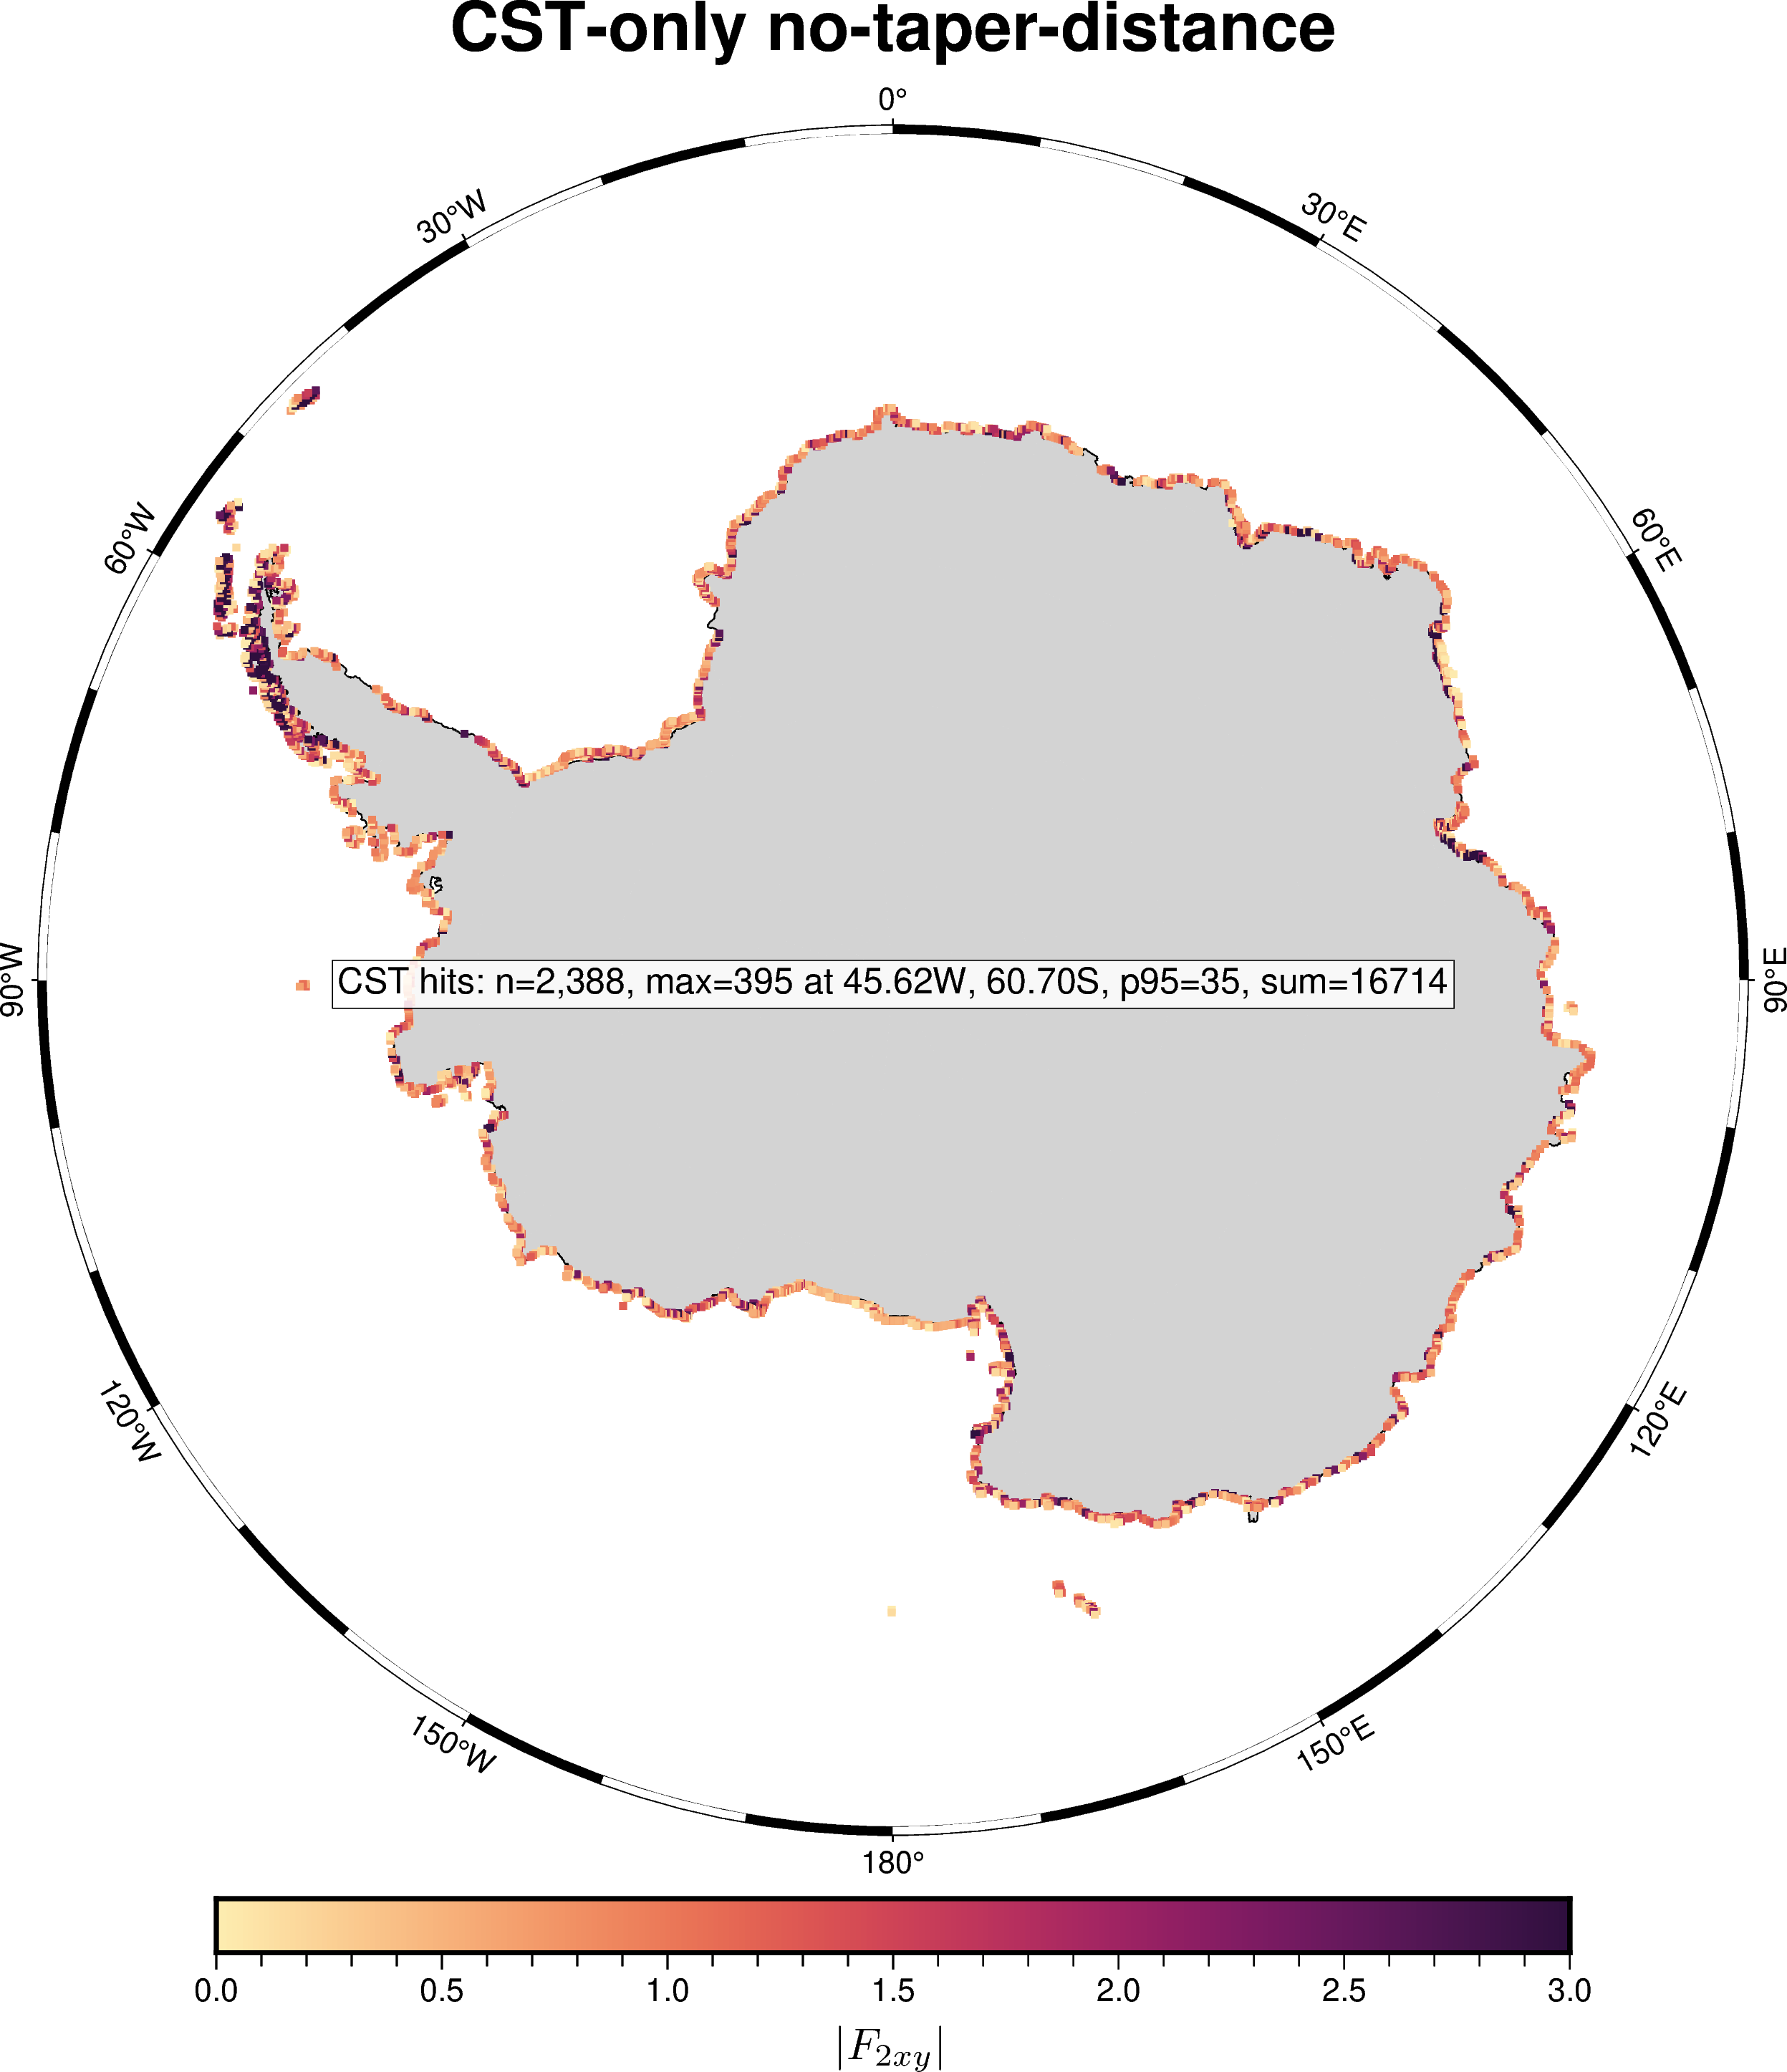

Saved: /g/data/gv90/da1339/GRAPHICAL/LD-pub-workspace/form-factors/cst_only/no_taper/DML/FF_cst-only_cst-v7p9_DML.png


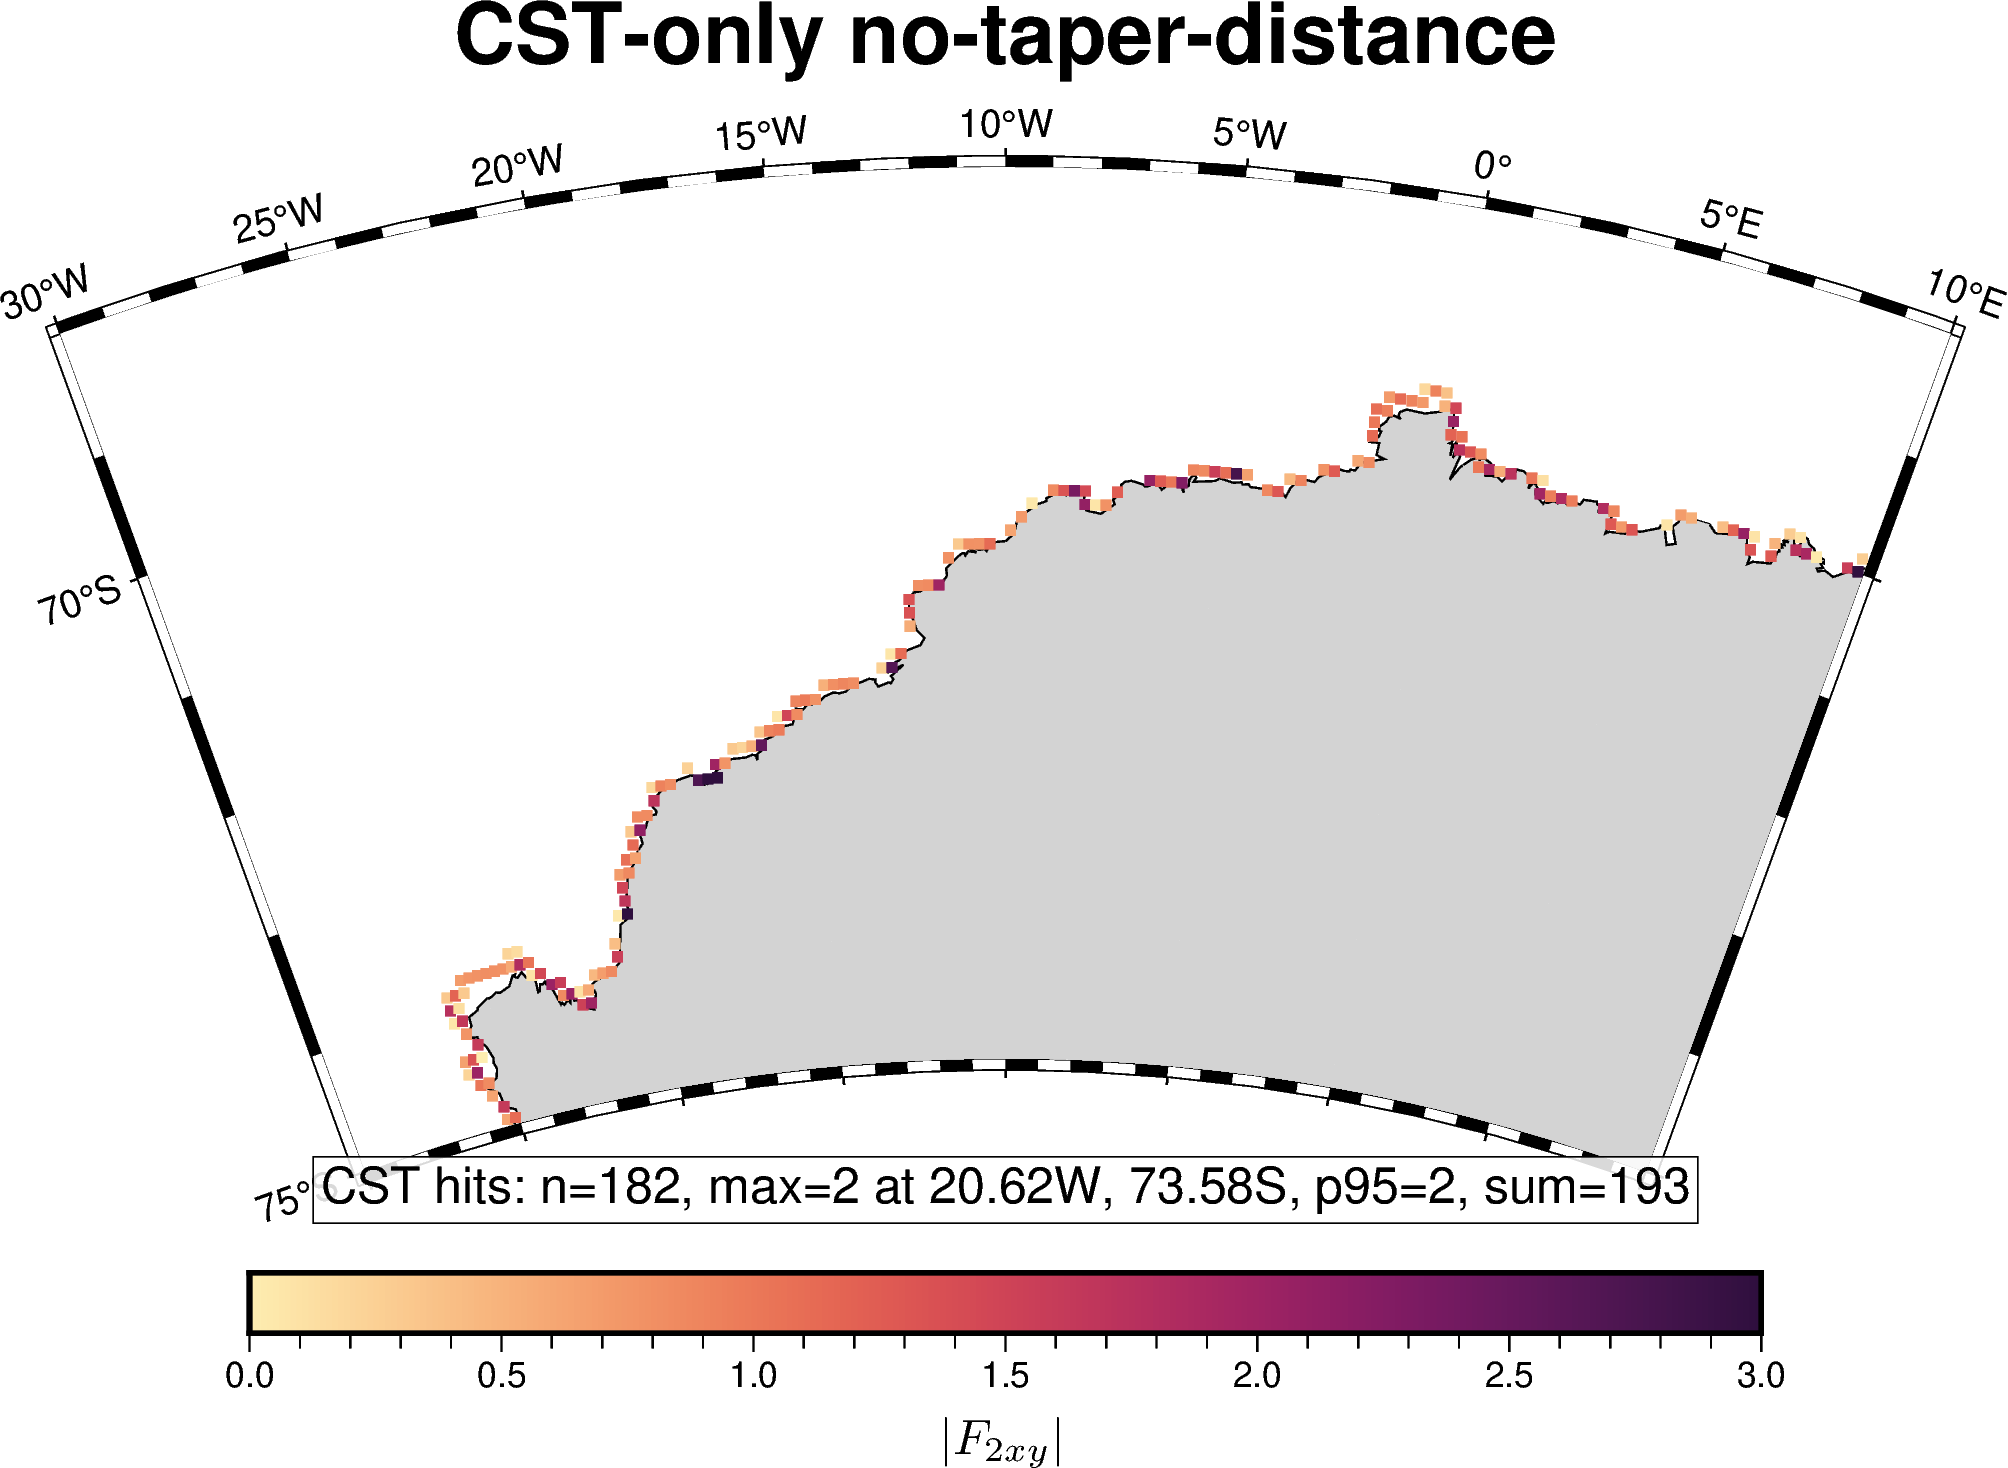

Saved: /g/data/gv90/da1339/GRAPHICAL/LD-pub-workspace/form-factors/cst_only/no_taper/WIO/FF_cst-only_cst-v7p9_WIO.png


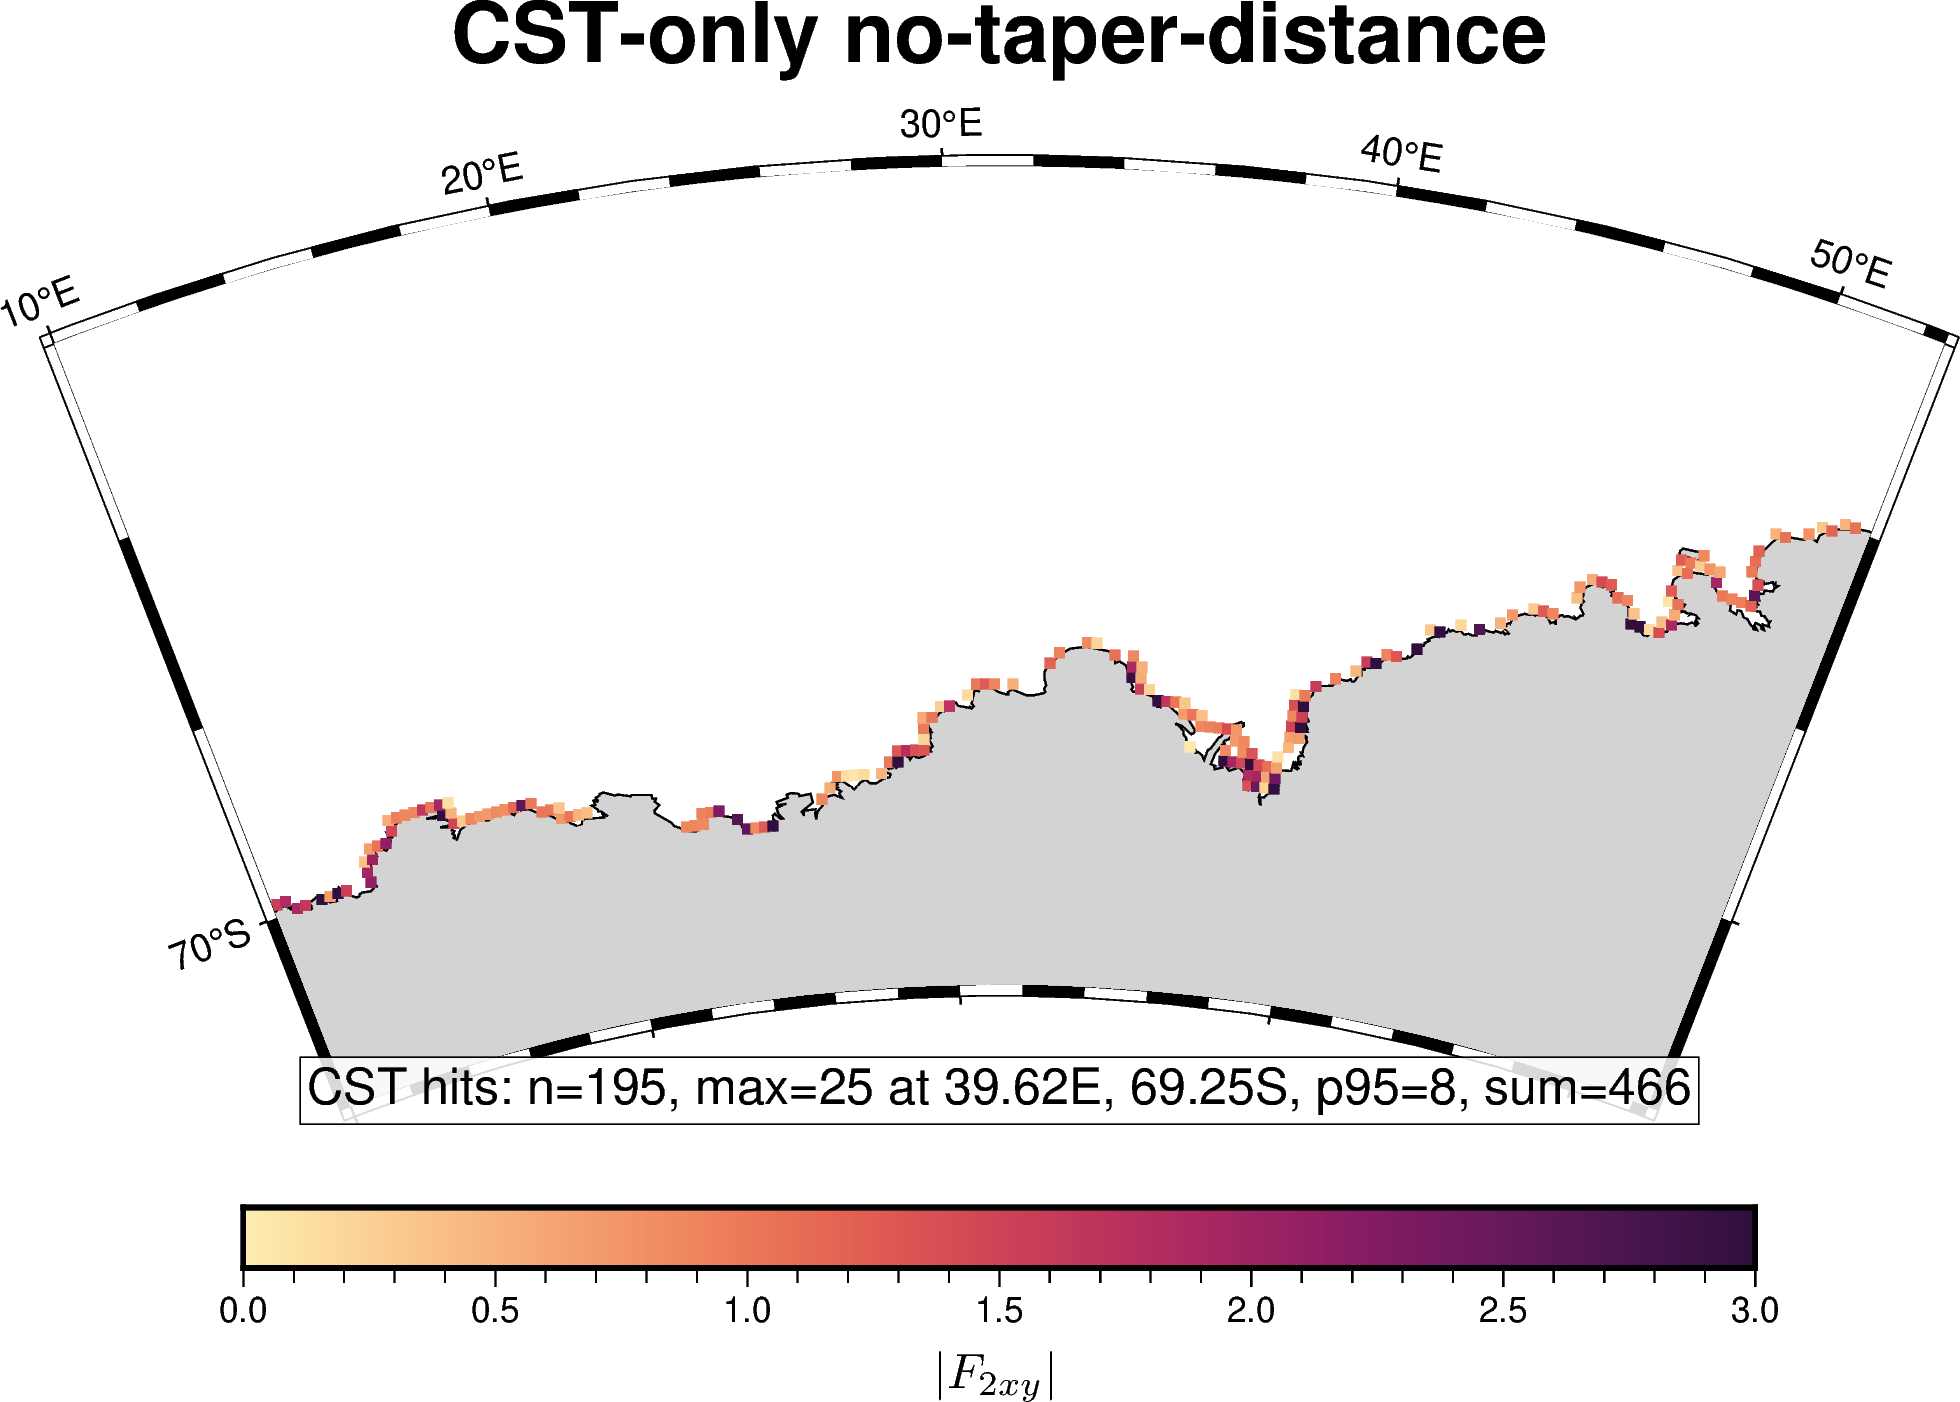

Saved: /g/data/gv90/da1339/GRAPHICAL/LD-pub-workspace/form-factors/cst_only/no_taper/EIO/FF_cst-only_cst-v7p9_EIO.png


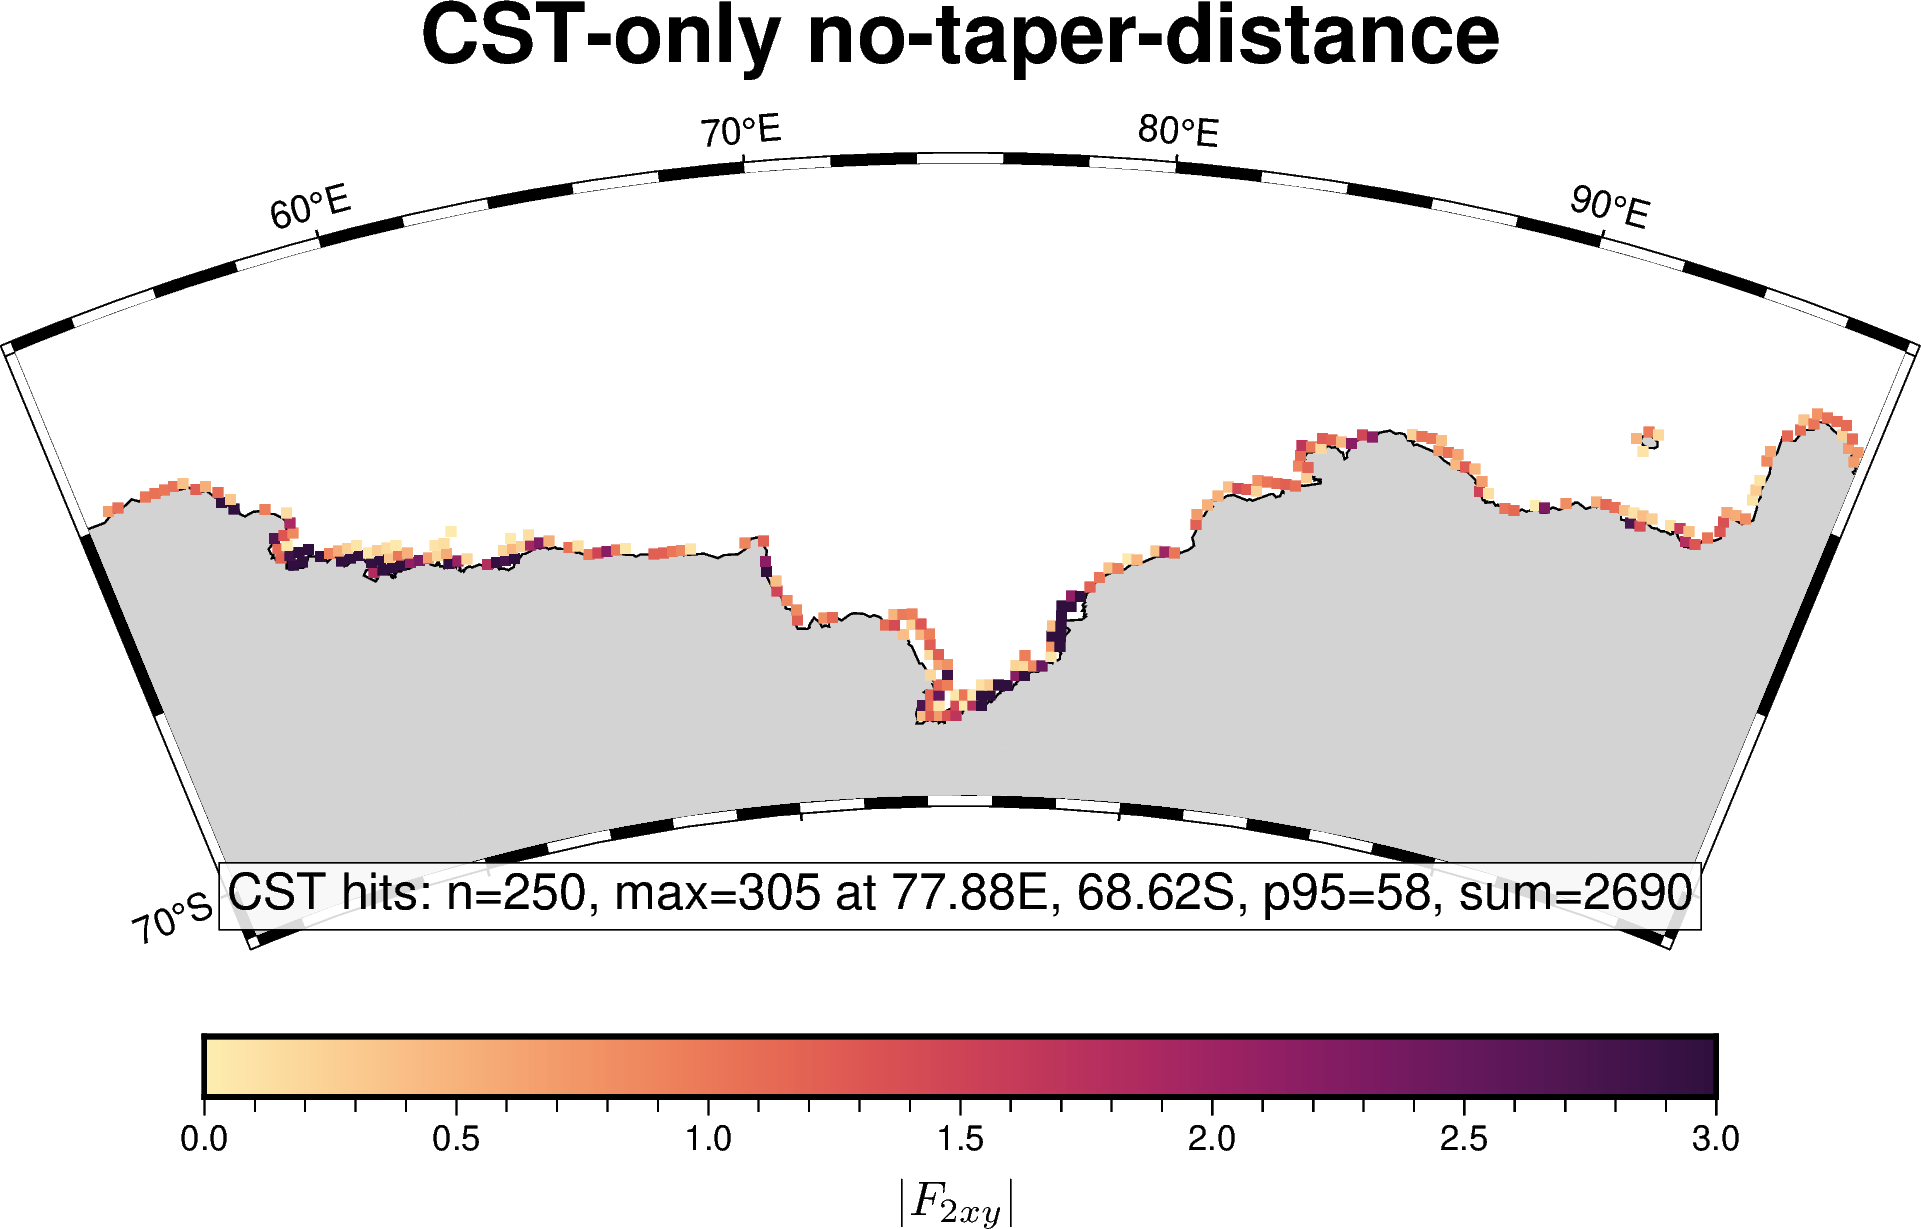

Saved: /g/data/gv90/da1339/GRAPHICAL/LD-pub-workspace/form-factors/cst_only/no_taper/Aus/FF_cst-only_cst-v7p9_Aus.png


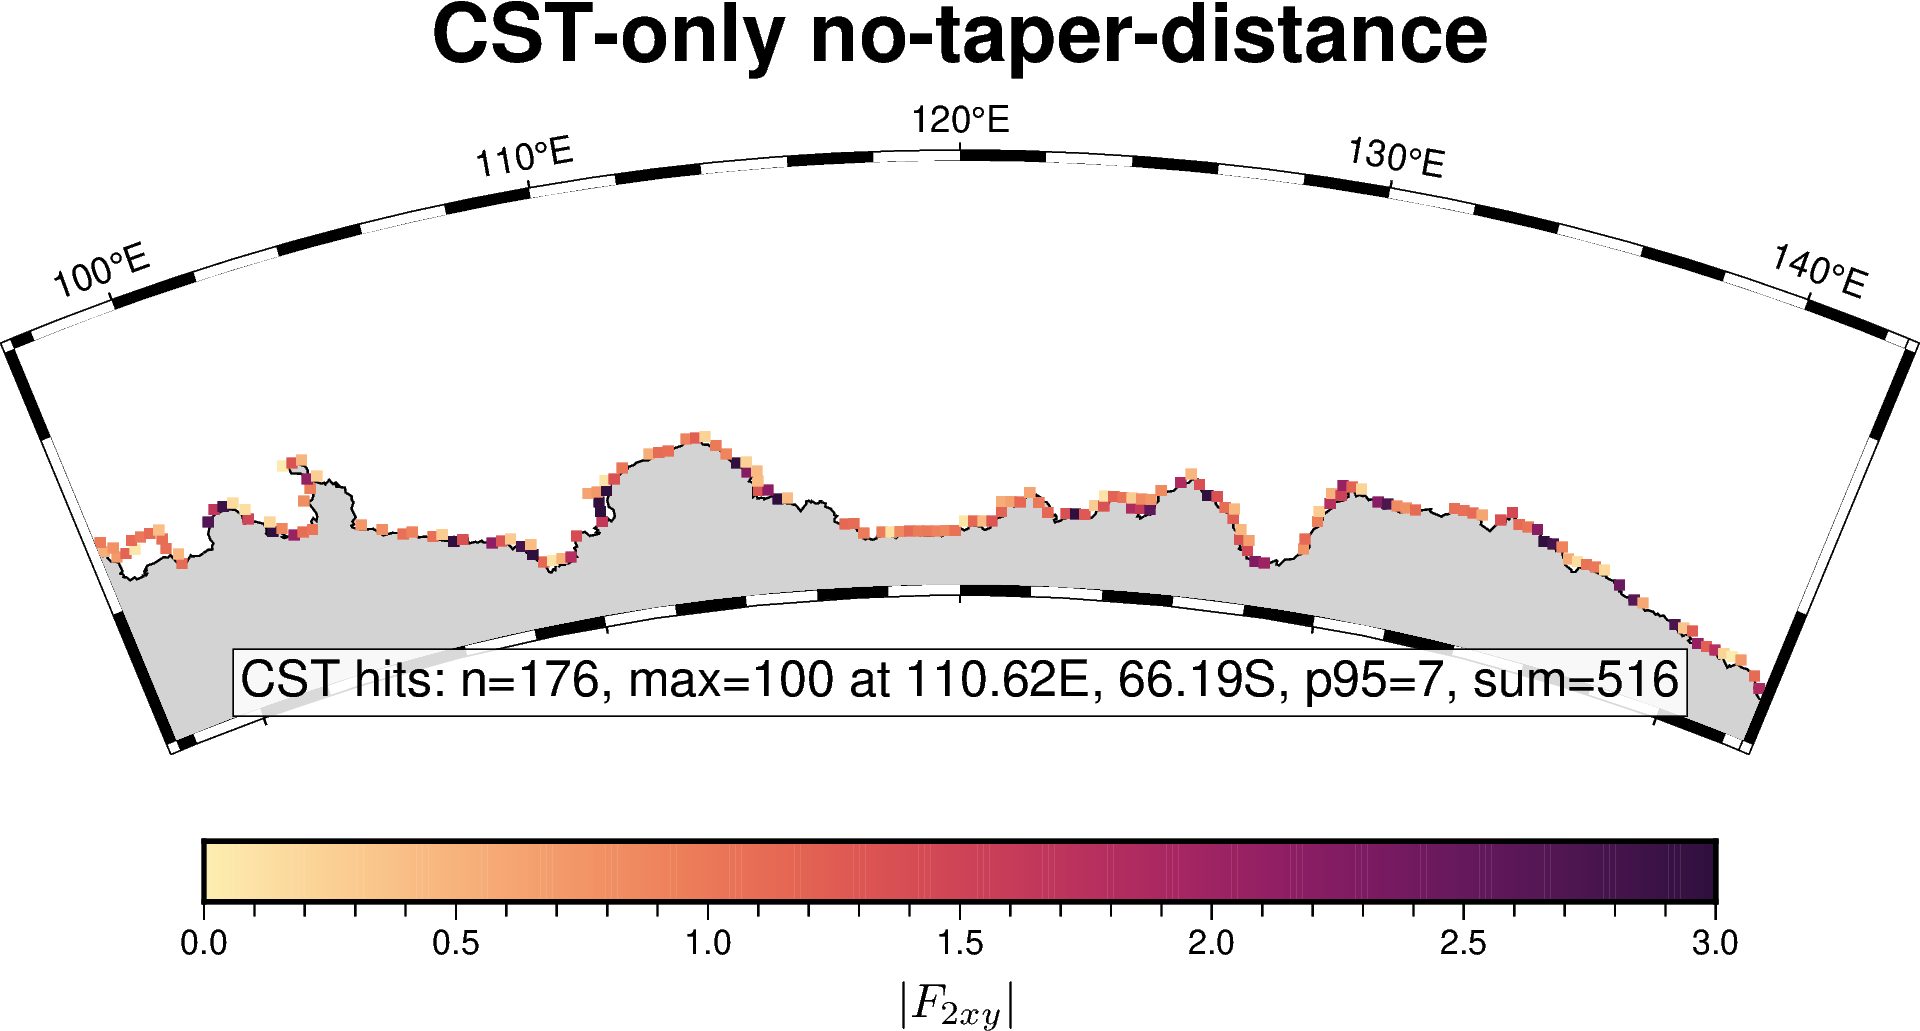

Saved: /g/data/gv90/da1339/GRAPHICAL/LD-pub-workspace/form-factors/cst_only/no_taper/VOL/FF_cst-only_cst-v7p9_VOL.png


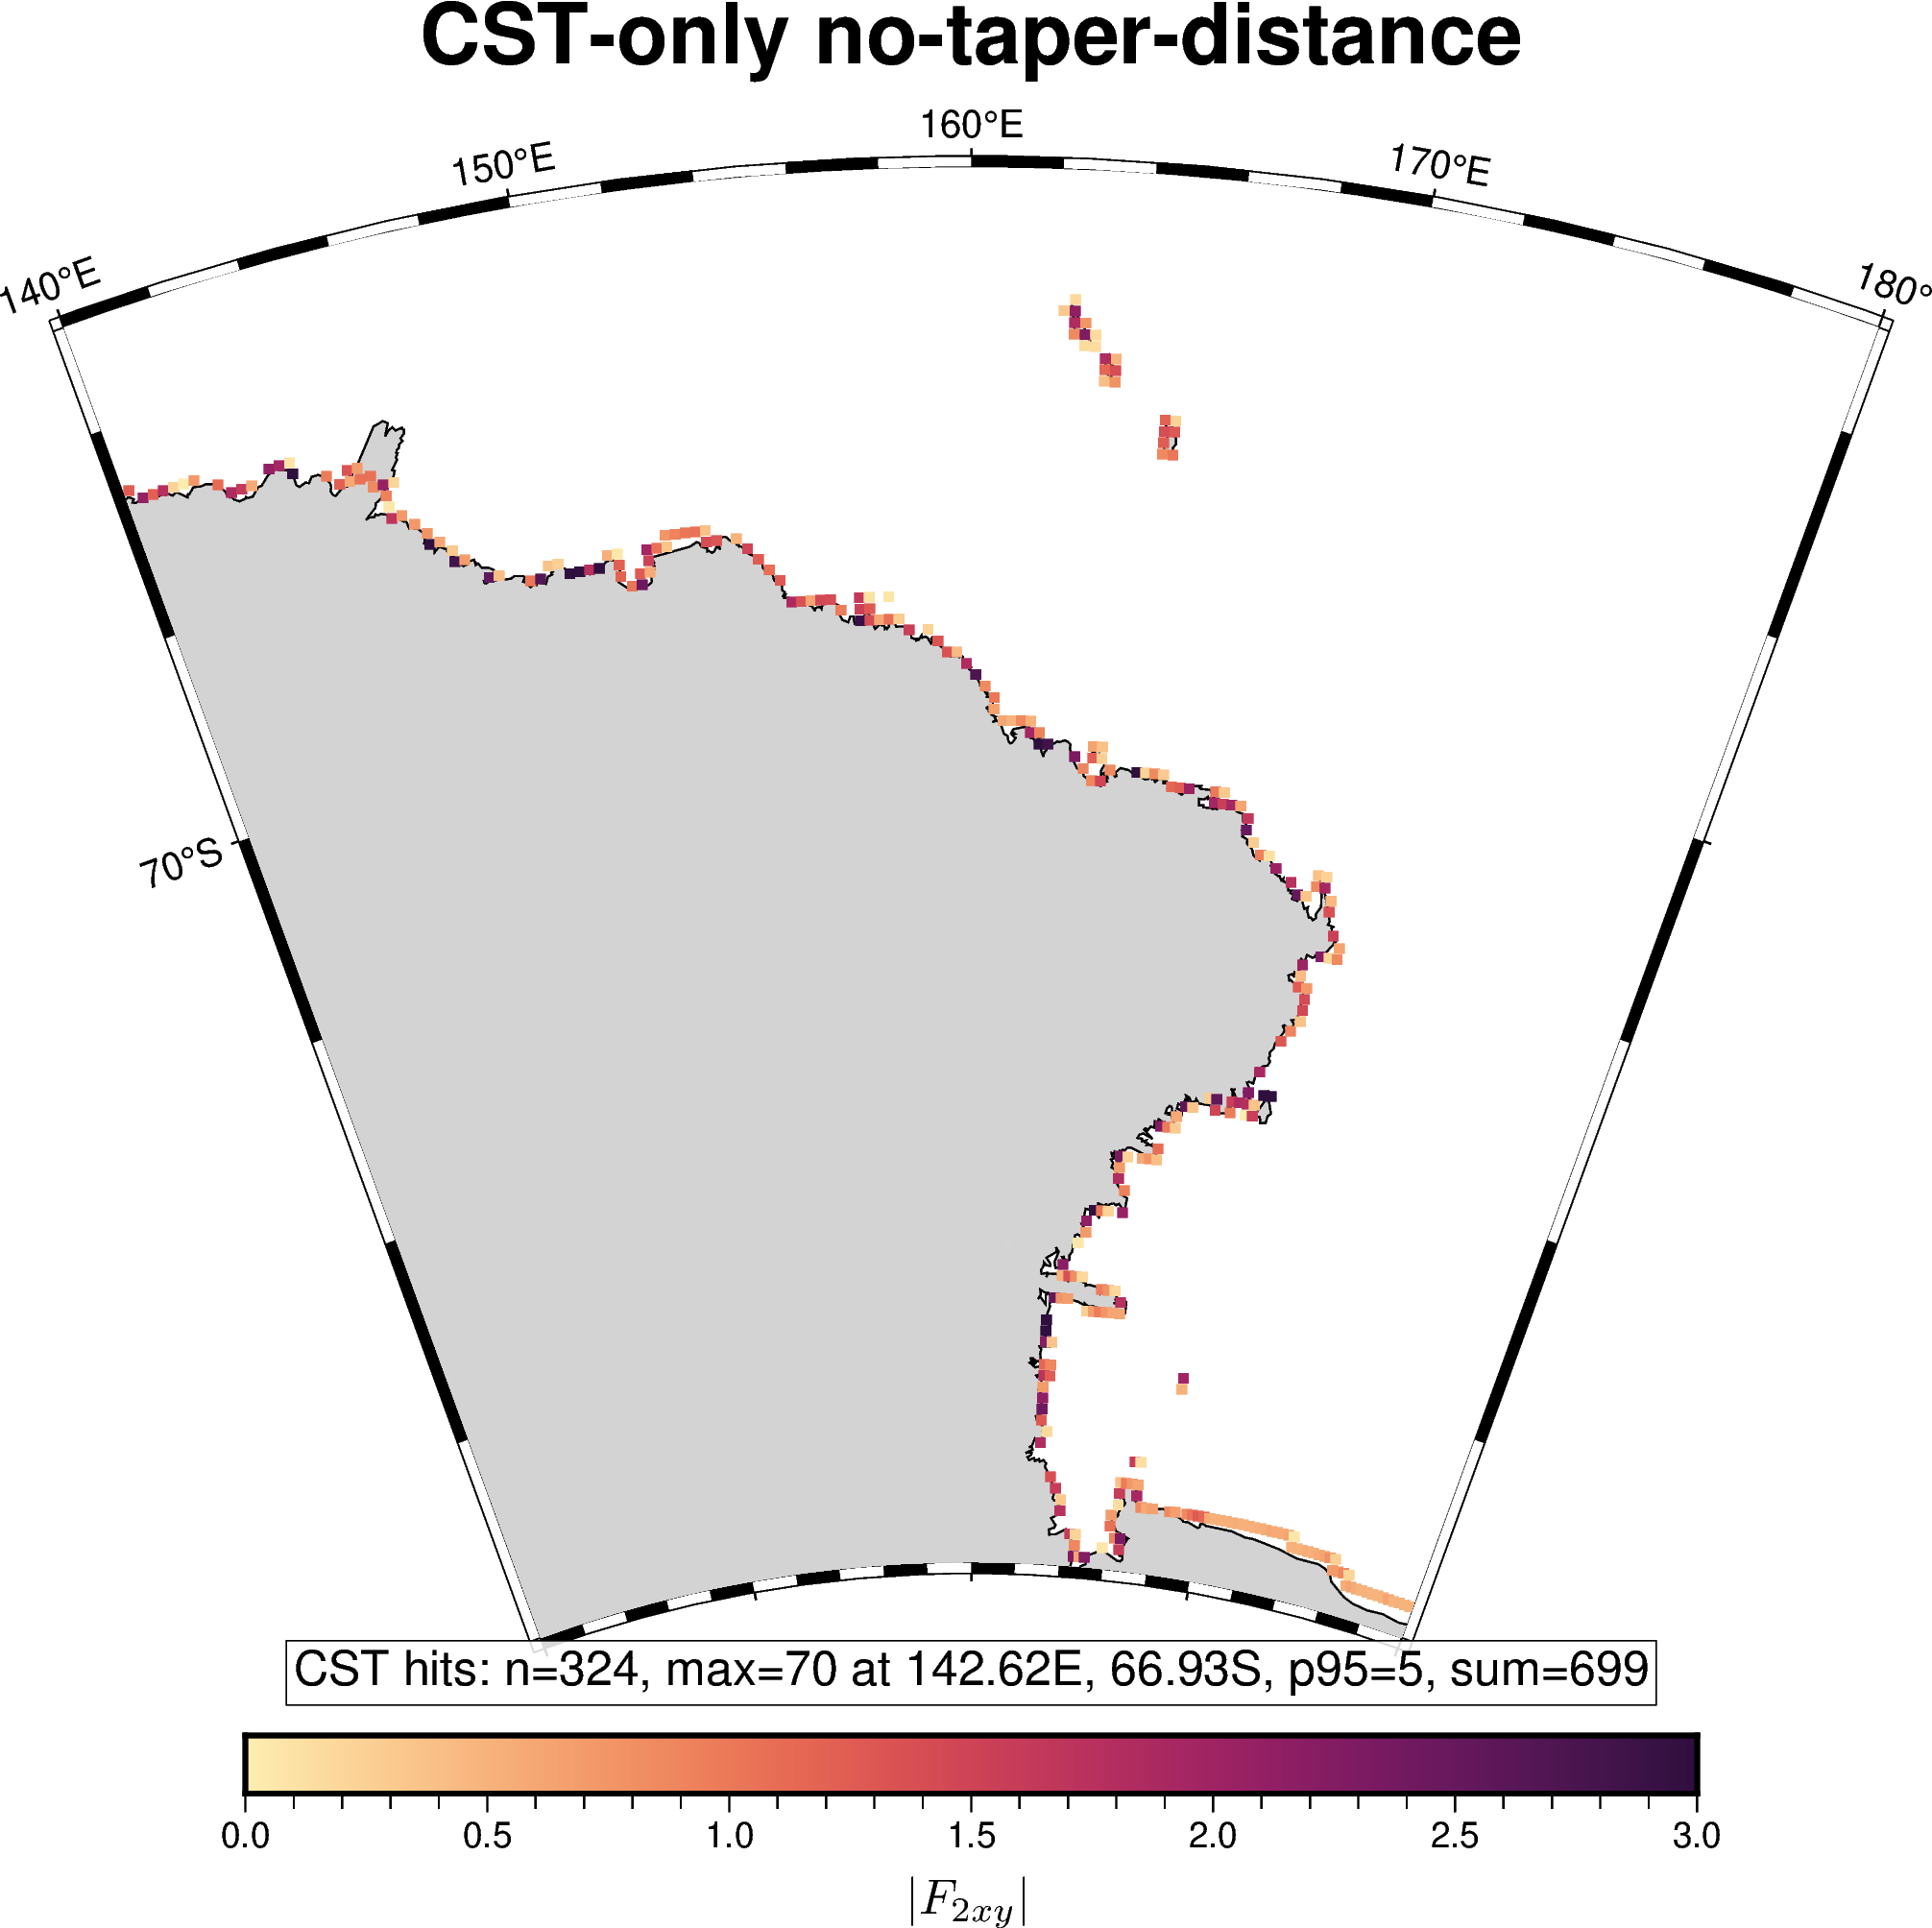

Saved: /g/data/gv90/da1339/GRAPHICAL/LD-pub-workspace/form-factors/cst_only/no_taper/AS/FF_cst-only_cst-v7p9_AS.png


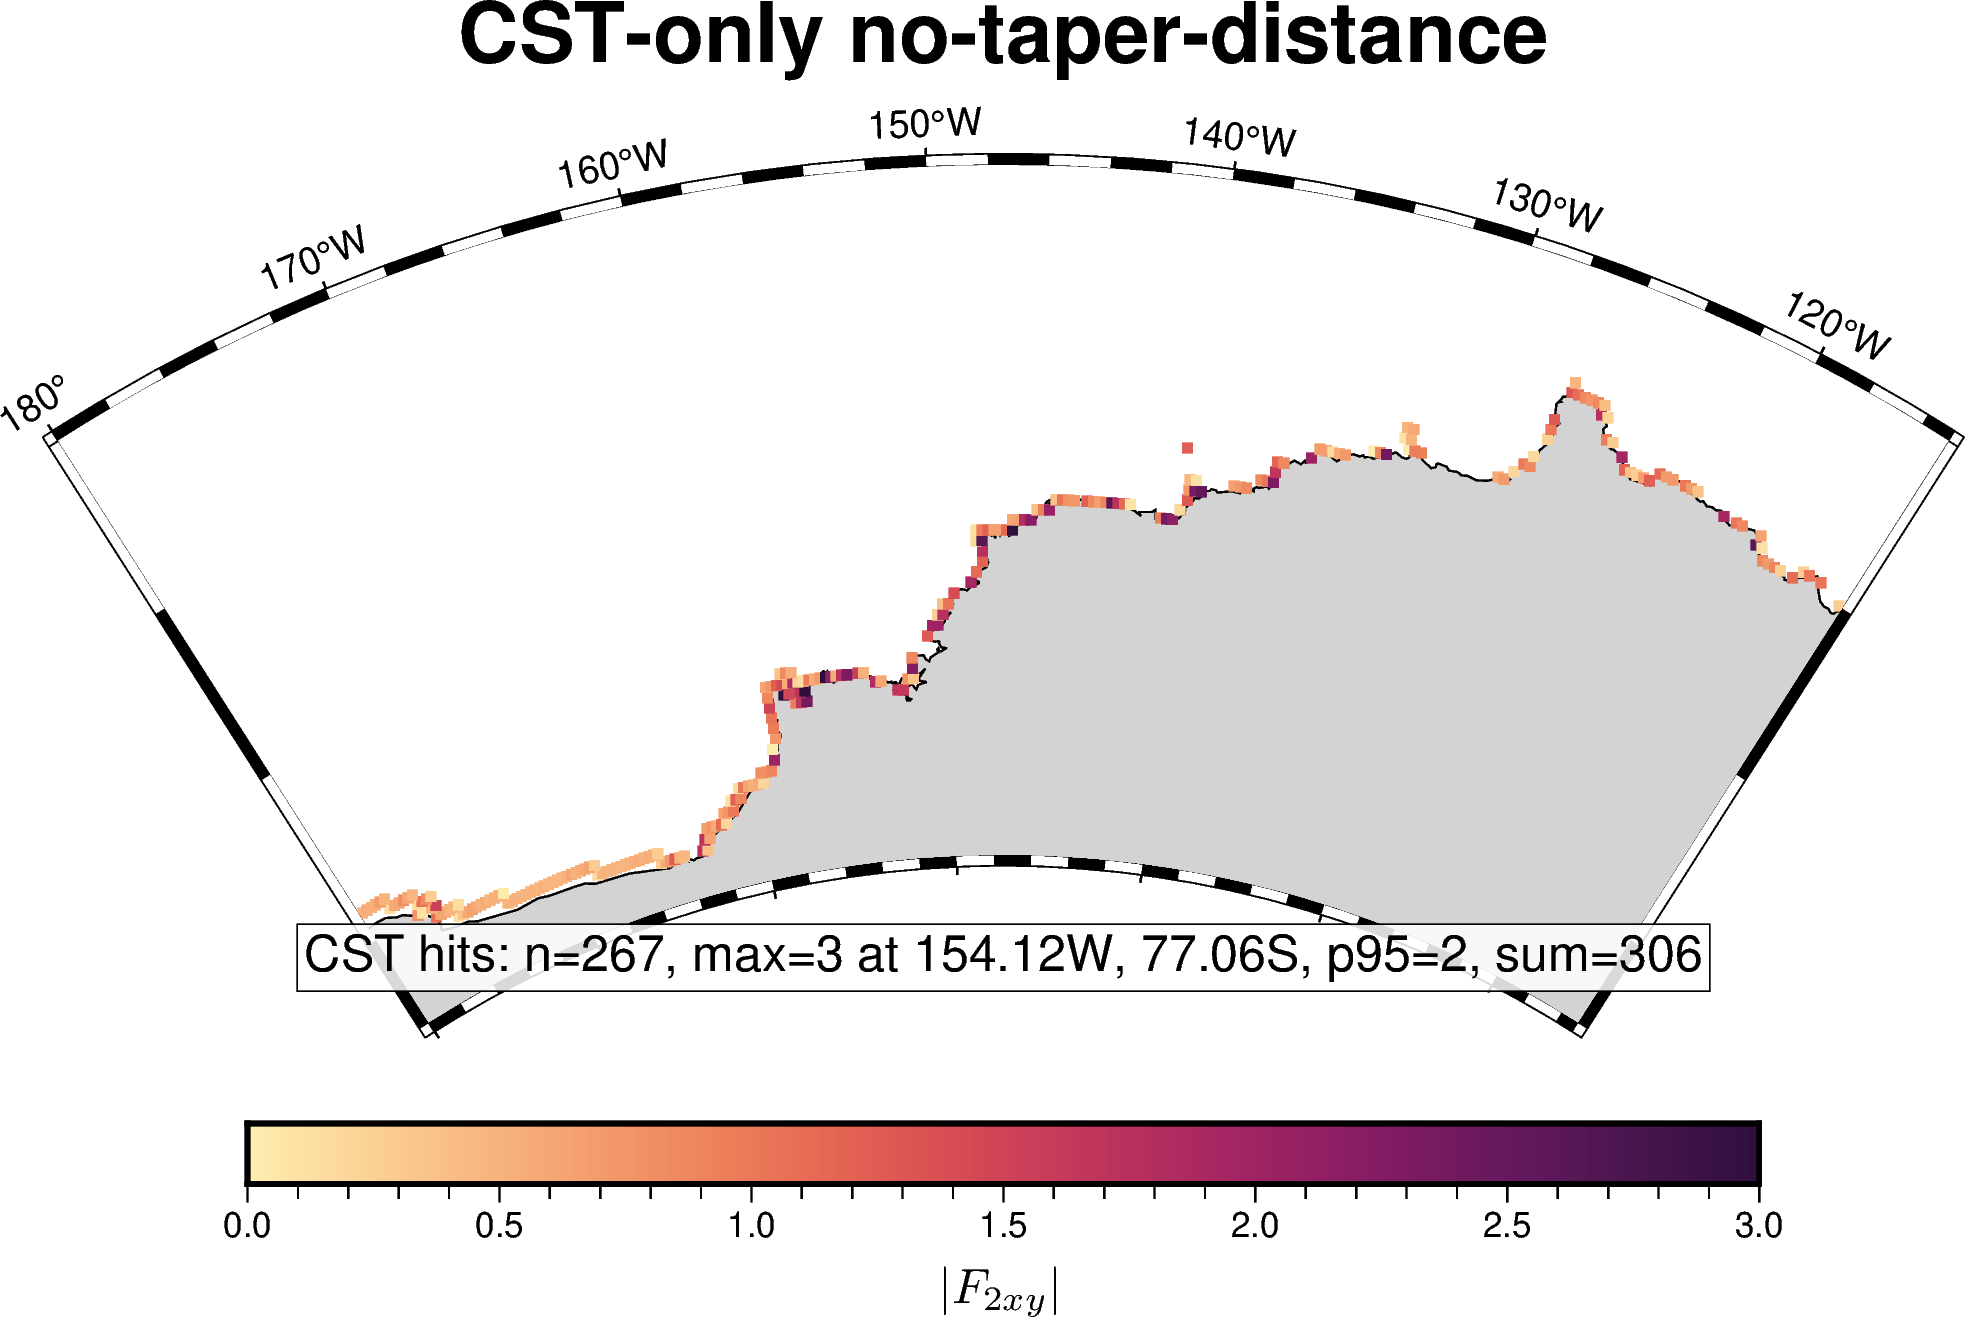

Saved: /g/data/gv90/da1339/GRAPHICAL/LD-pub-workspace/form-factors/cst_only/no_taper/BS/FF_cst-only_cst-v7p9_BS.png


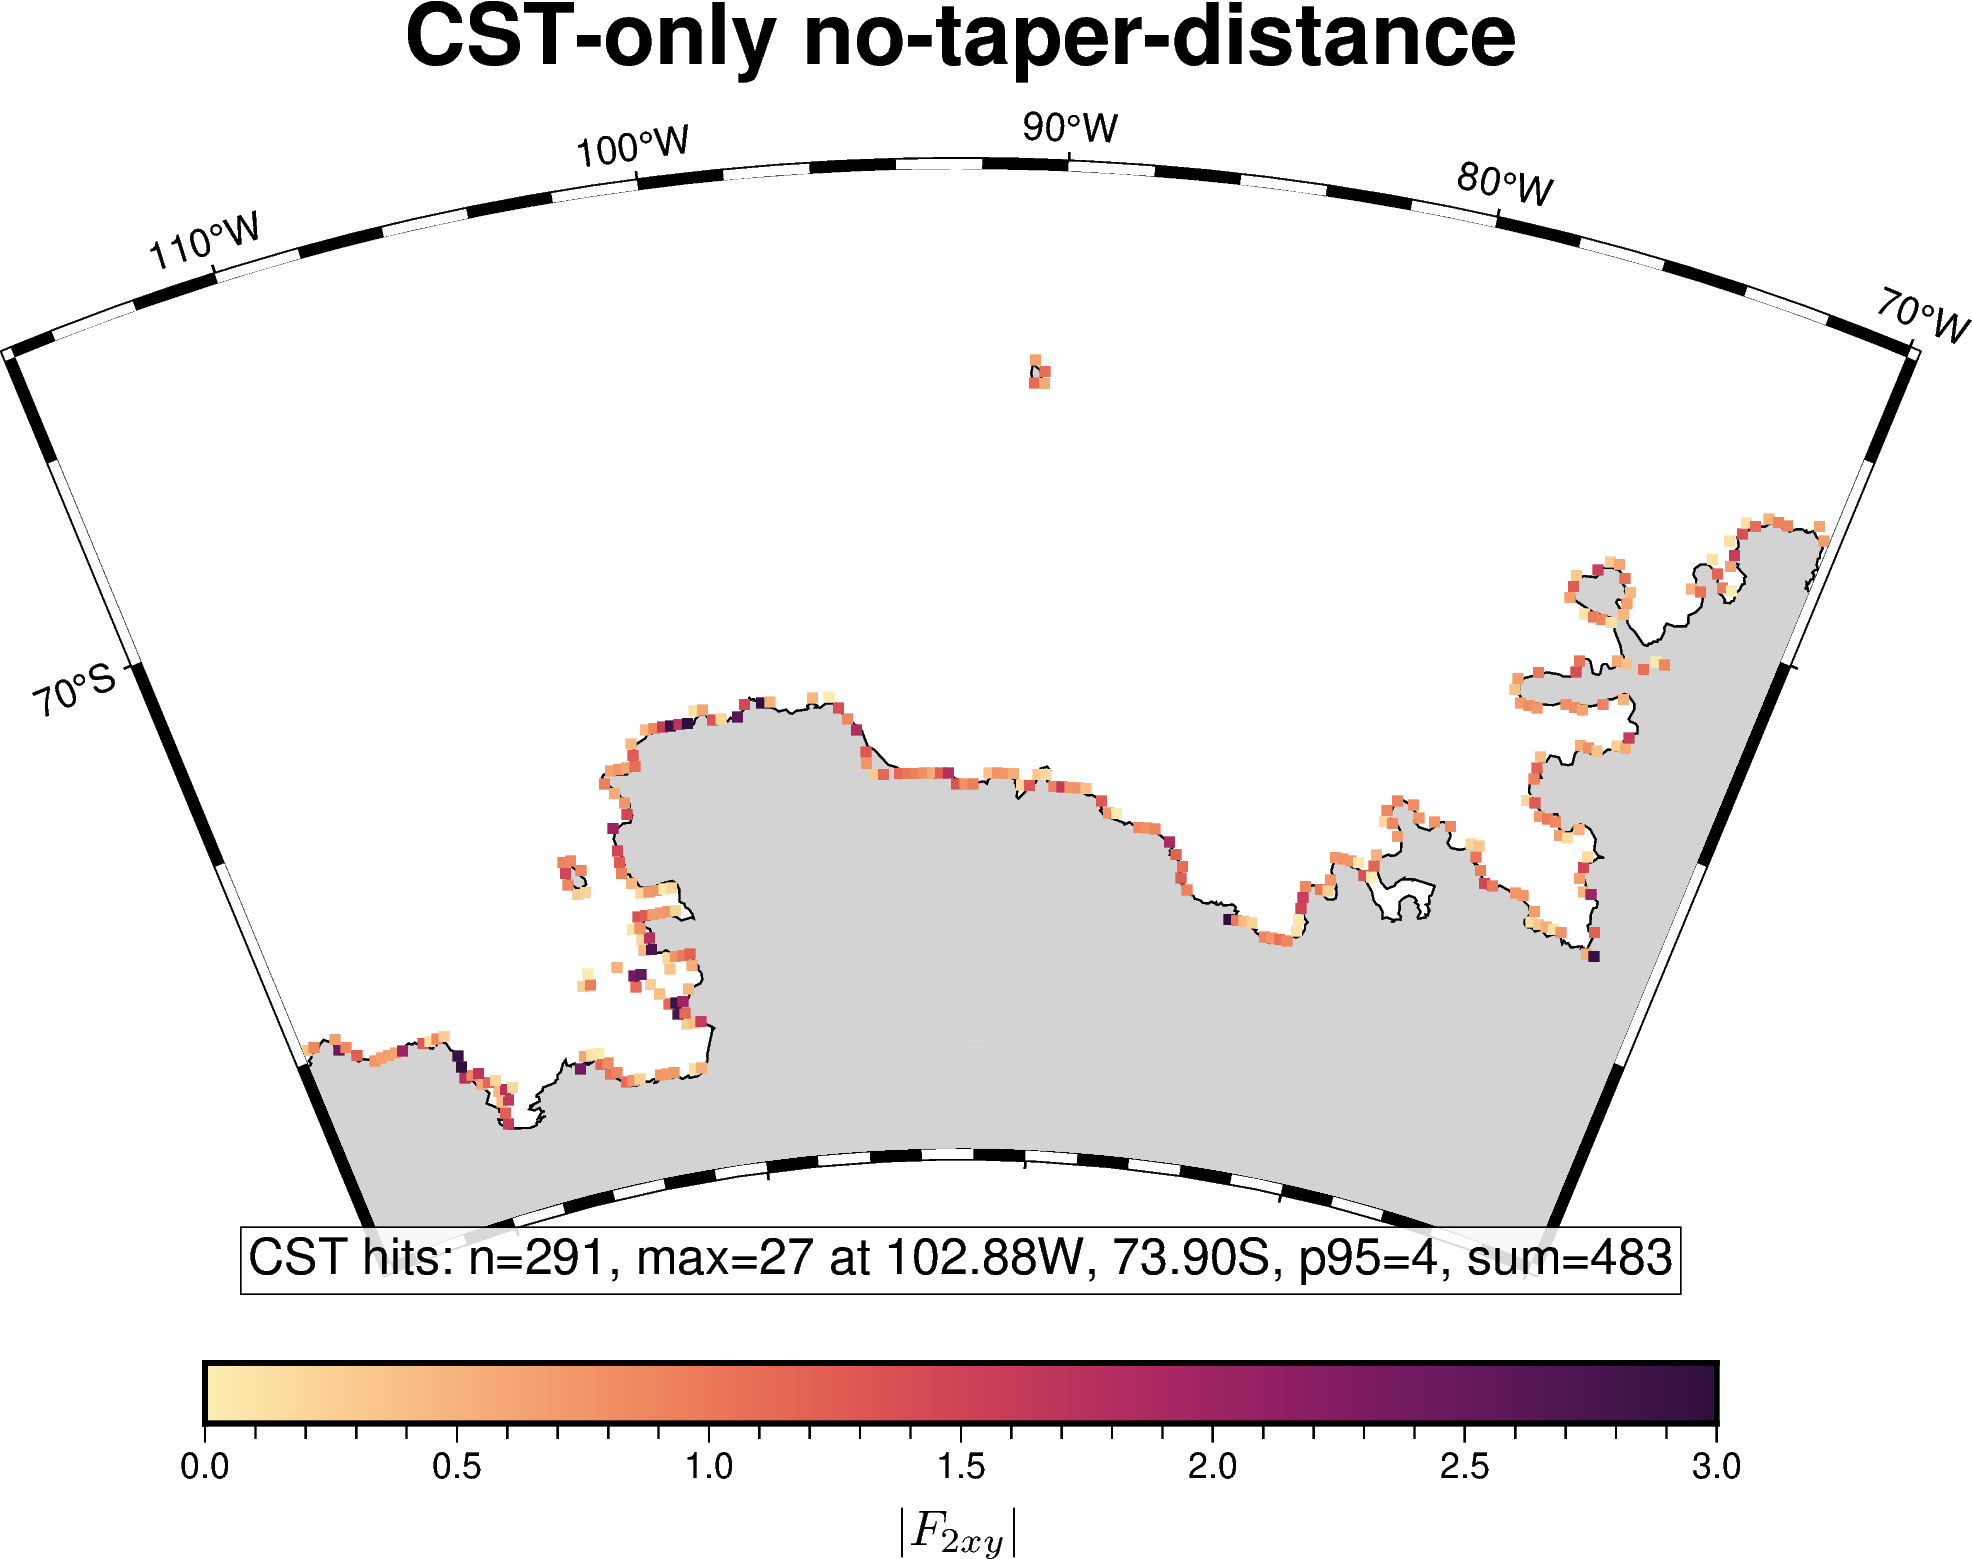

Saved: /g/data/gv90/da1339/GRAPHICAL/LD-pub-workspace/form-factors/cst_only/no_taper/WS/FF_cst-only_cst-v7p9_WS.png


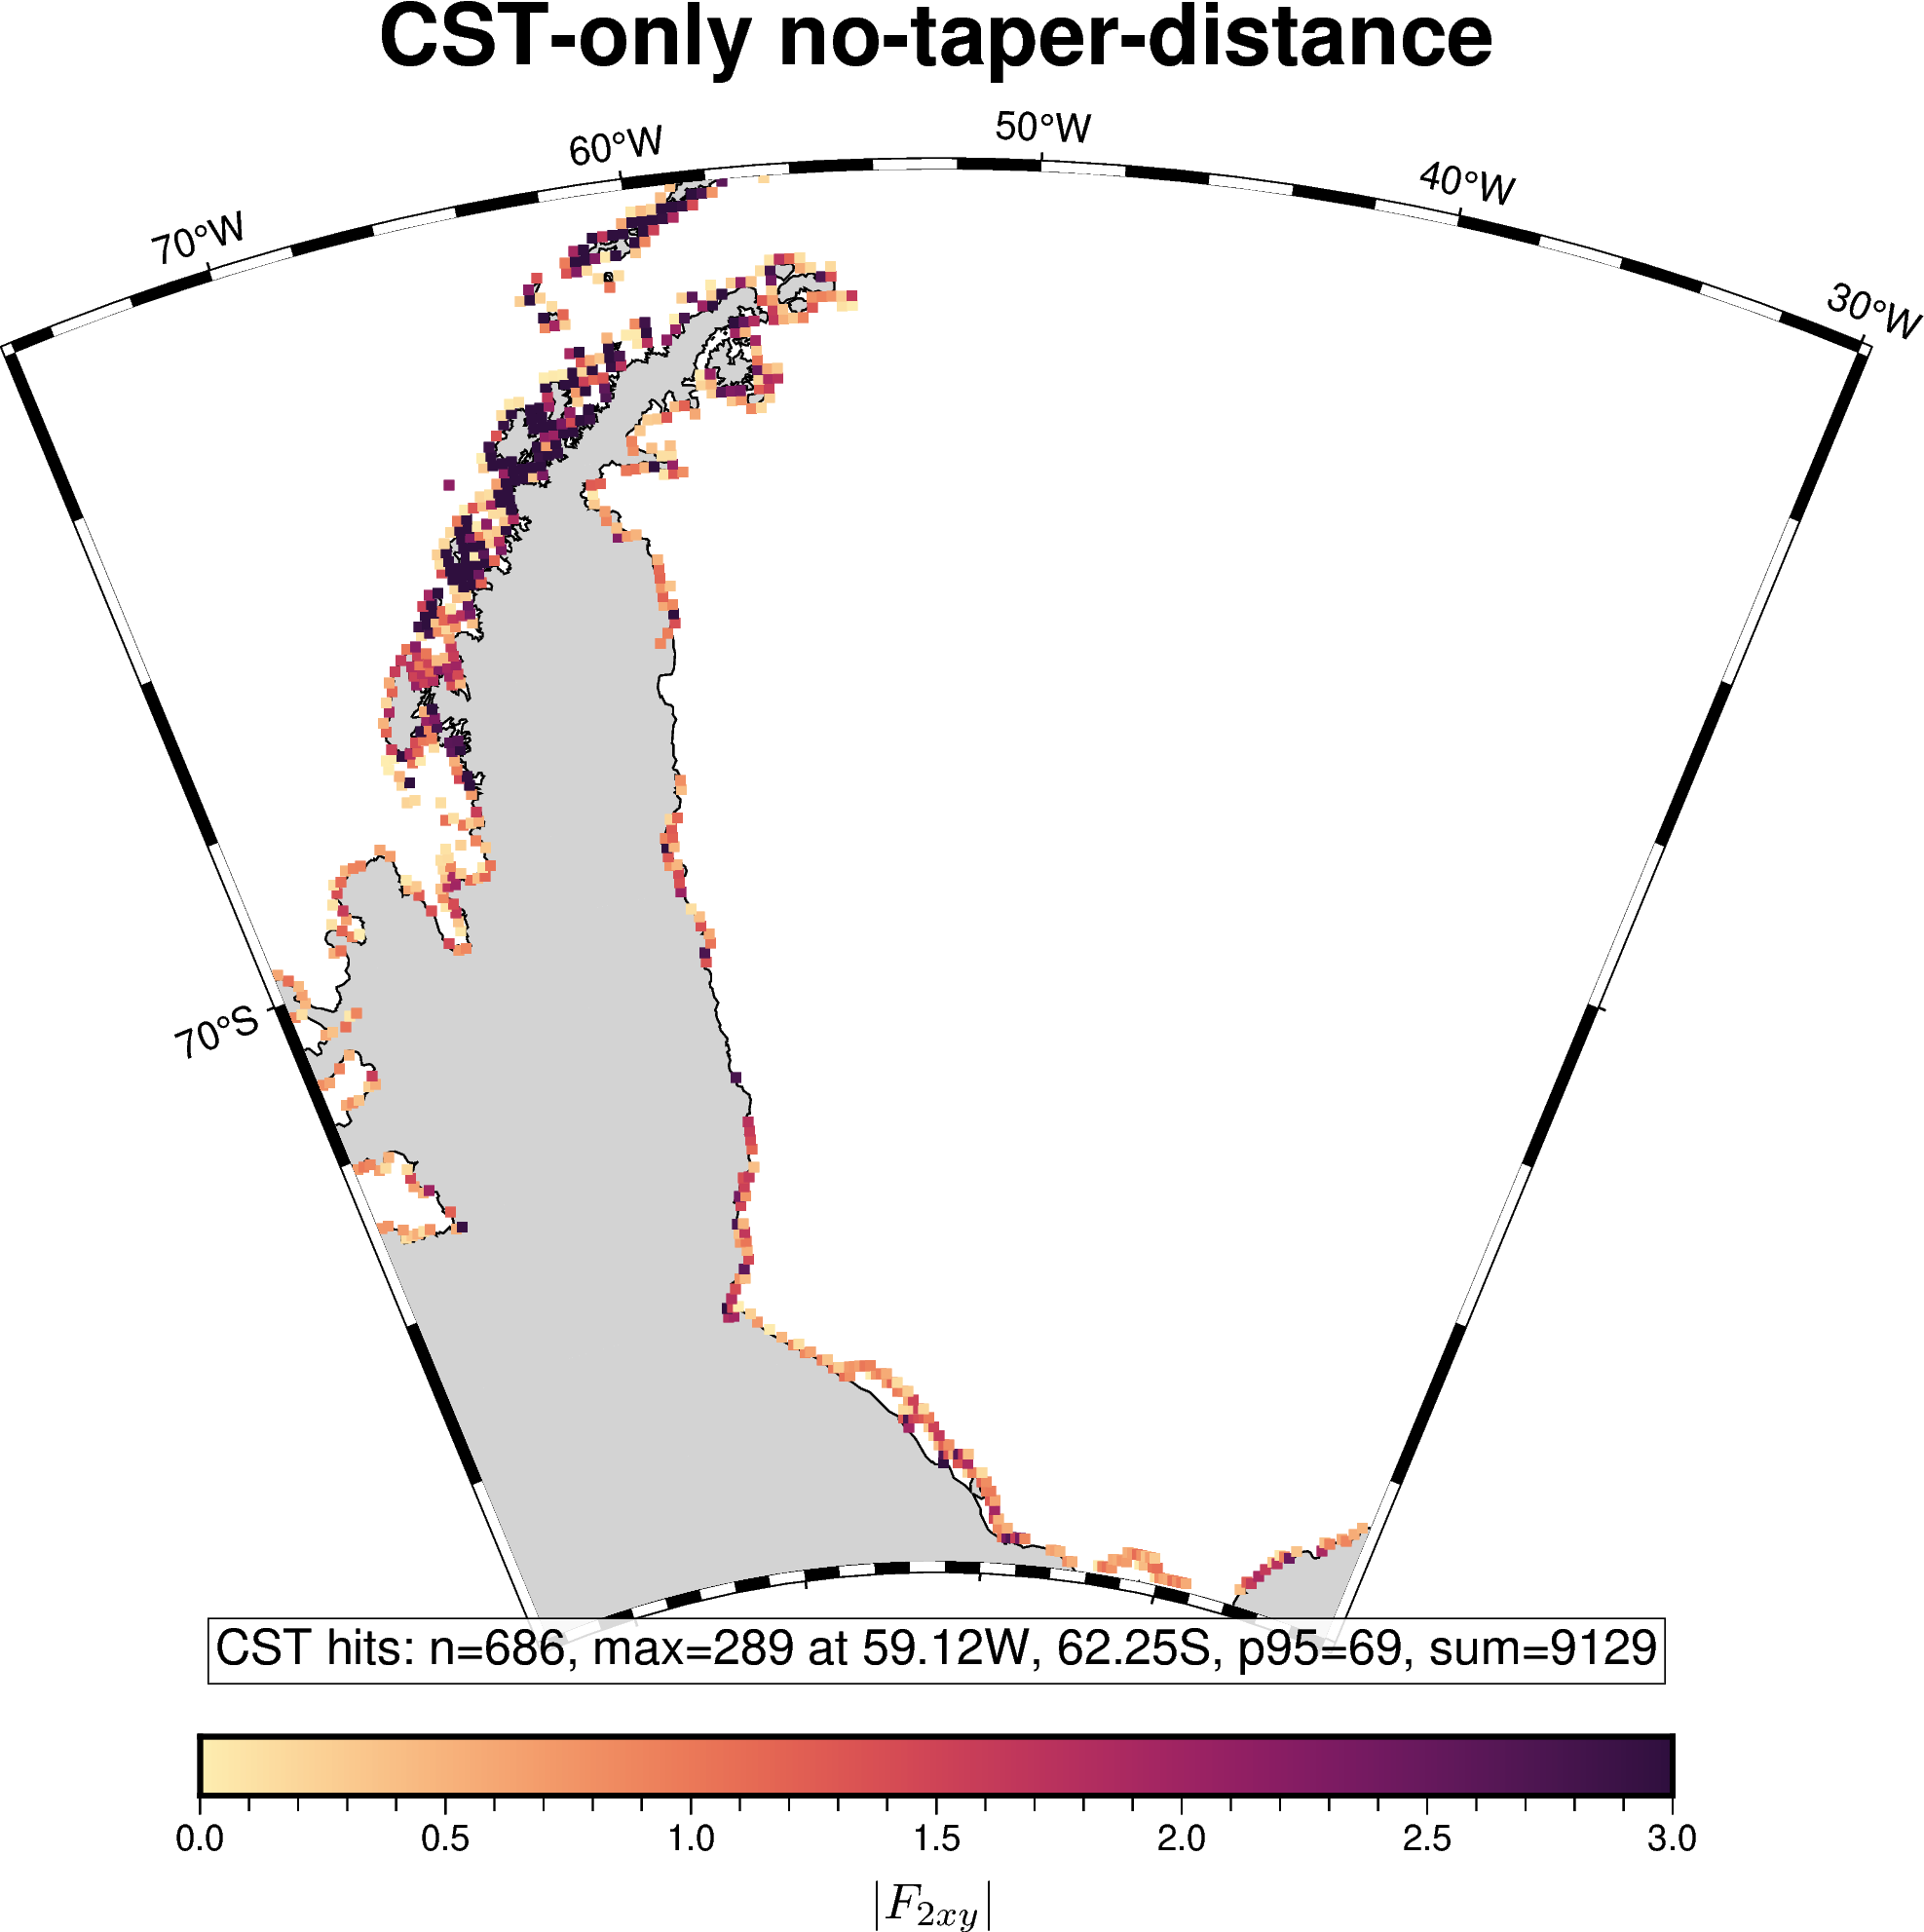

In [8]:
# CST-only
with xr.open_dataset(P_FF_cst) as ds:
    D_ = D_root_out / 'cst_only' / 'no_taper'
    for region_name in ALL_REGIONS:
        P_png   = D_ / region_name / f'FF_cst-only_cst-{cst_ver}_{region_name}.png'
        tit_str = 'CST-only no-taper-distance'
        plot_form_factor_pygmt(ds                = ds,
                               out               = P_png,
                               title             = tit_str,
                               region_name       = region_name,
                               ANTARCTIC_REGIONS = ANTARCTIC_REGIONS,
                               product_kind      = 'cst-only',
                               diagnostics       = ['coast_n_source_hits'],
                               show_diagnostics  = True,
                               gib_points        = GIB_pts,
                               show_gib_points   = SHOW_GIB_POINTS_ON_CST)

text [WARNING]: Latitude (-90.5) at line # 1 exceeds -|+ 90! - set to NaN


Saved: /g/data/gv90/da1339/GRAPHICAL/LD-pub-workspace/form-factors/gib_only/no_taper/SH/FF_gib-only_GIB-v1p2_SH.png


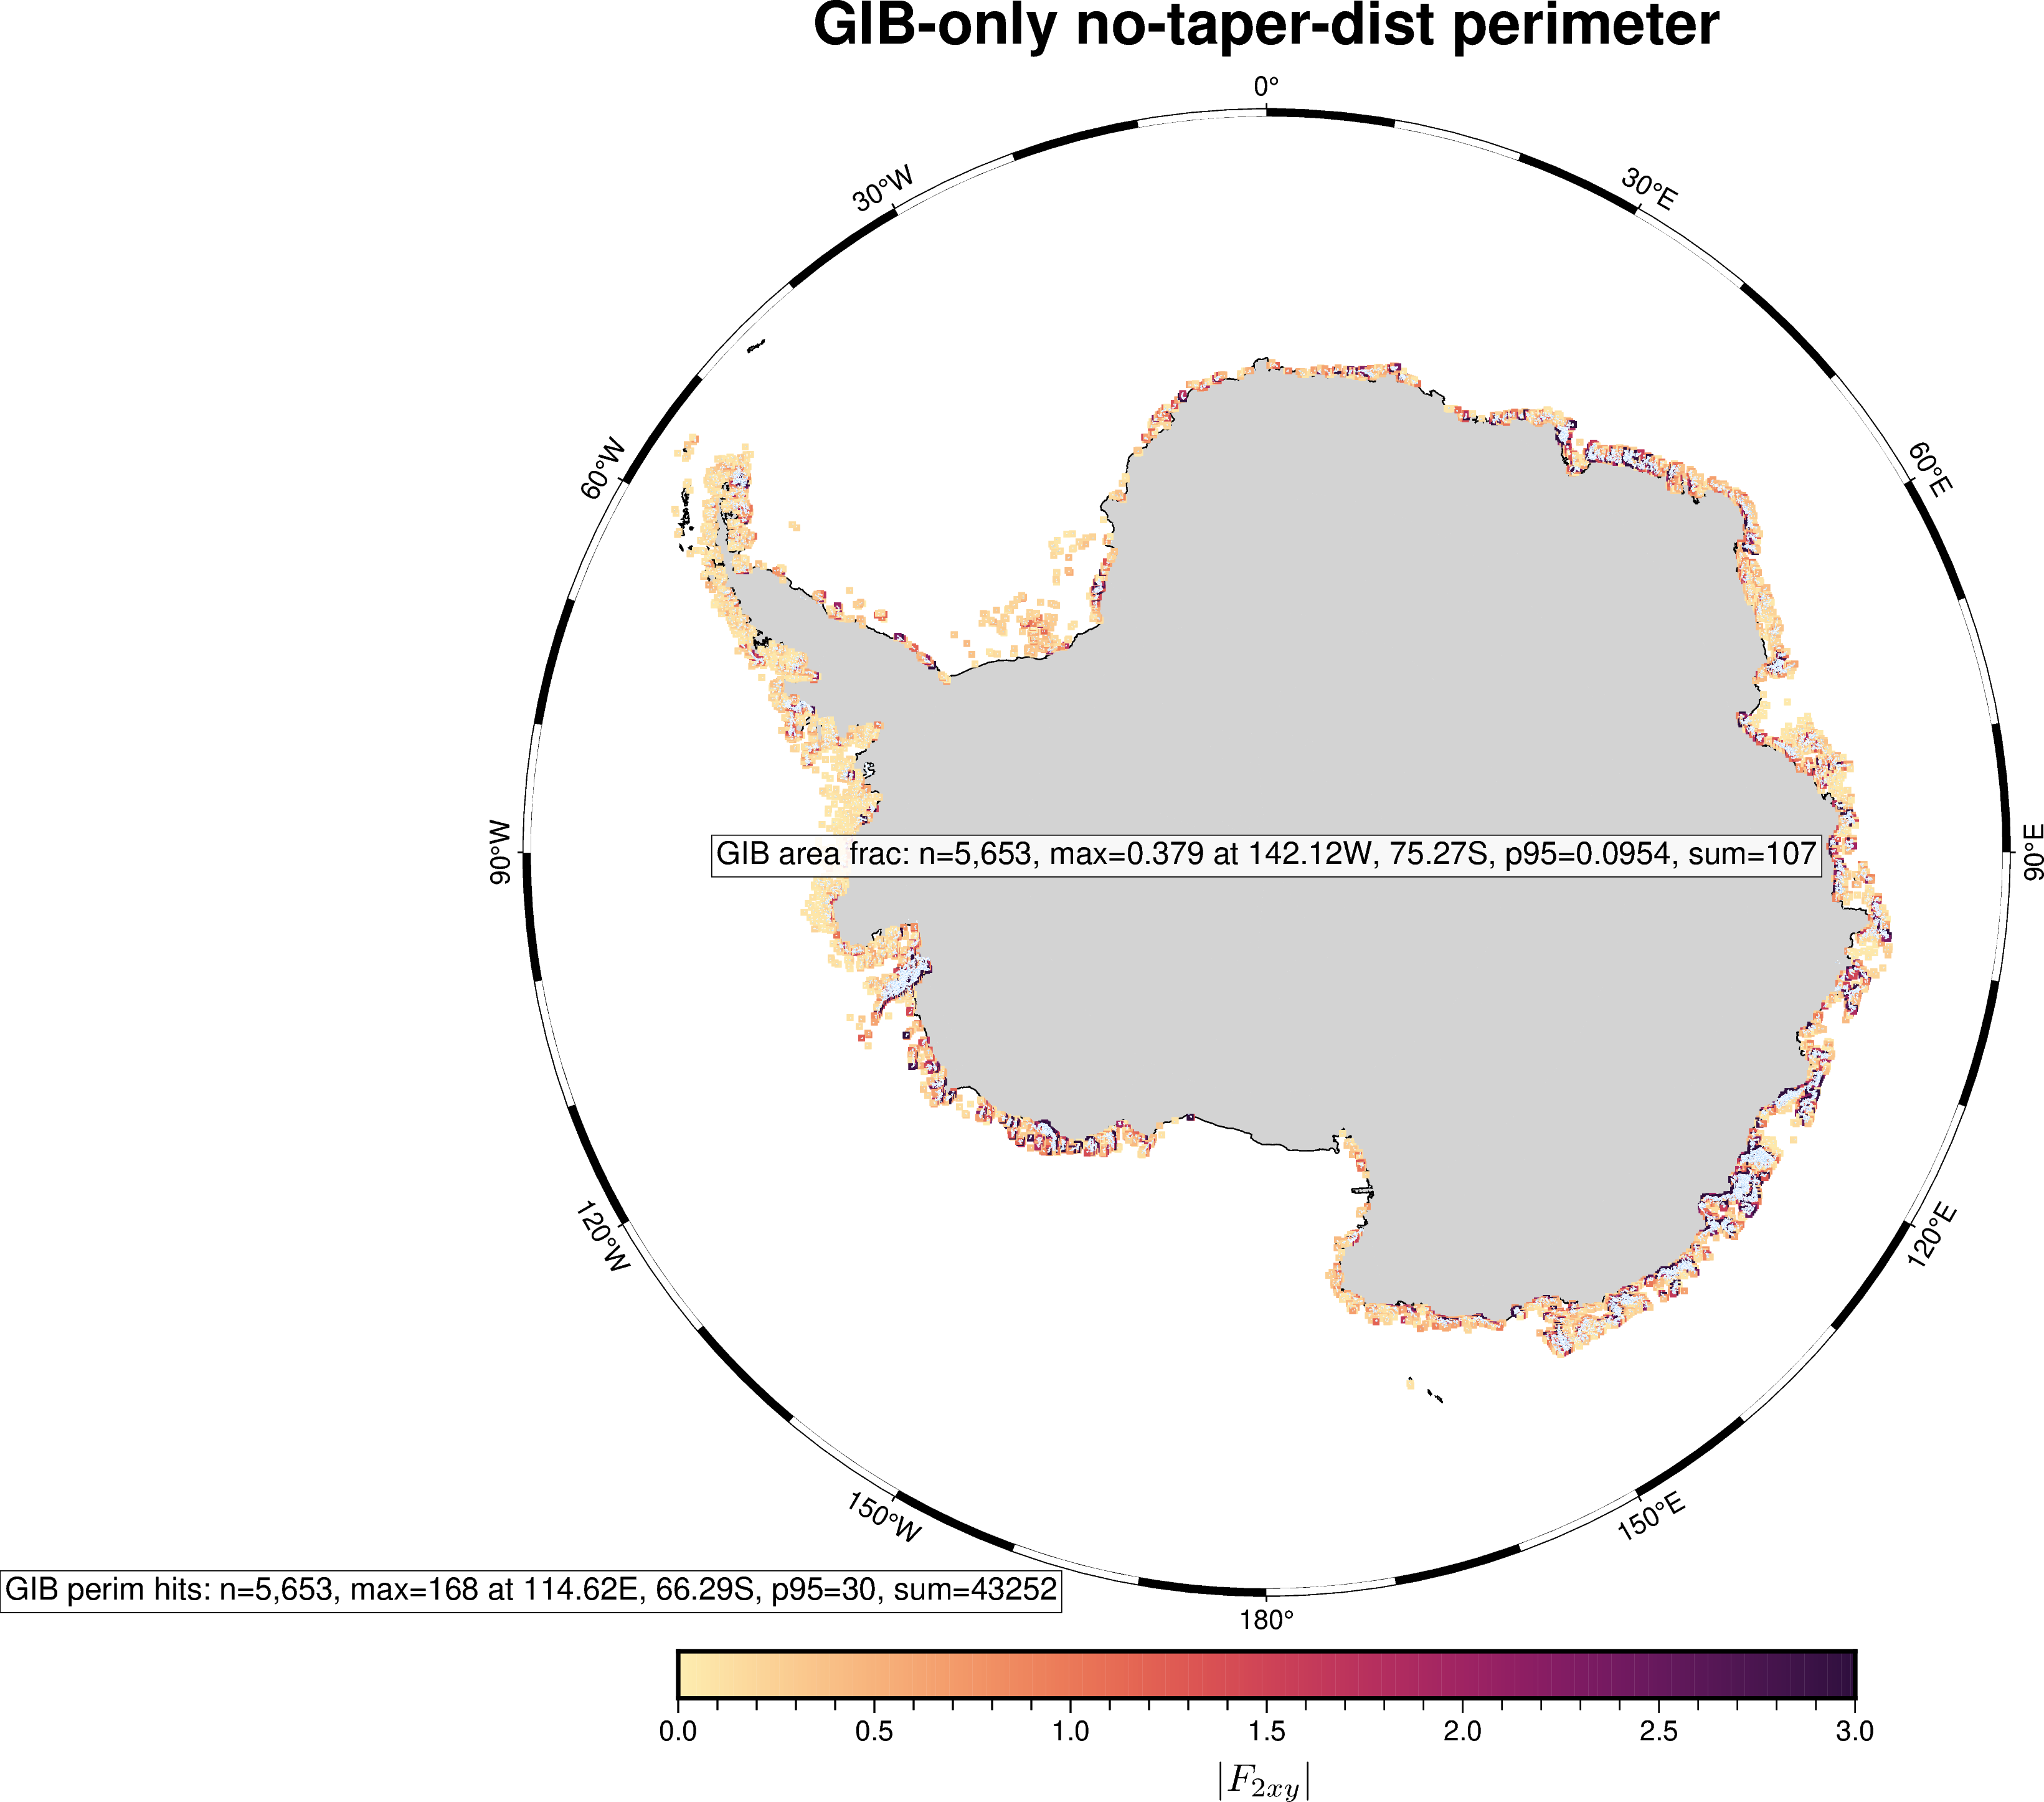

Saved: /g/data/gv90/da1339/GRAPHICAL/LD-pub-workspace/form-factors/gib_only/no_taper/DML/FF_gib-only_GIB-v1p2_DML.png


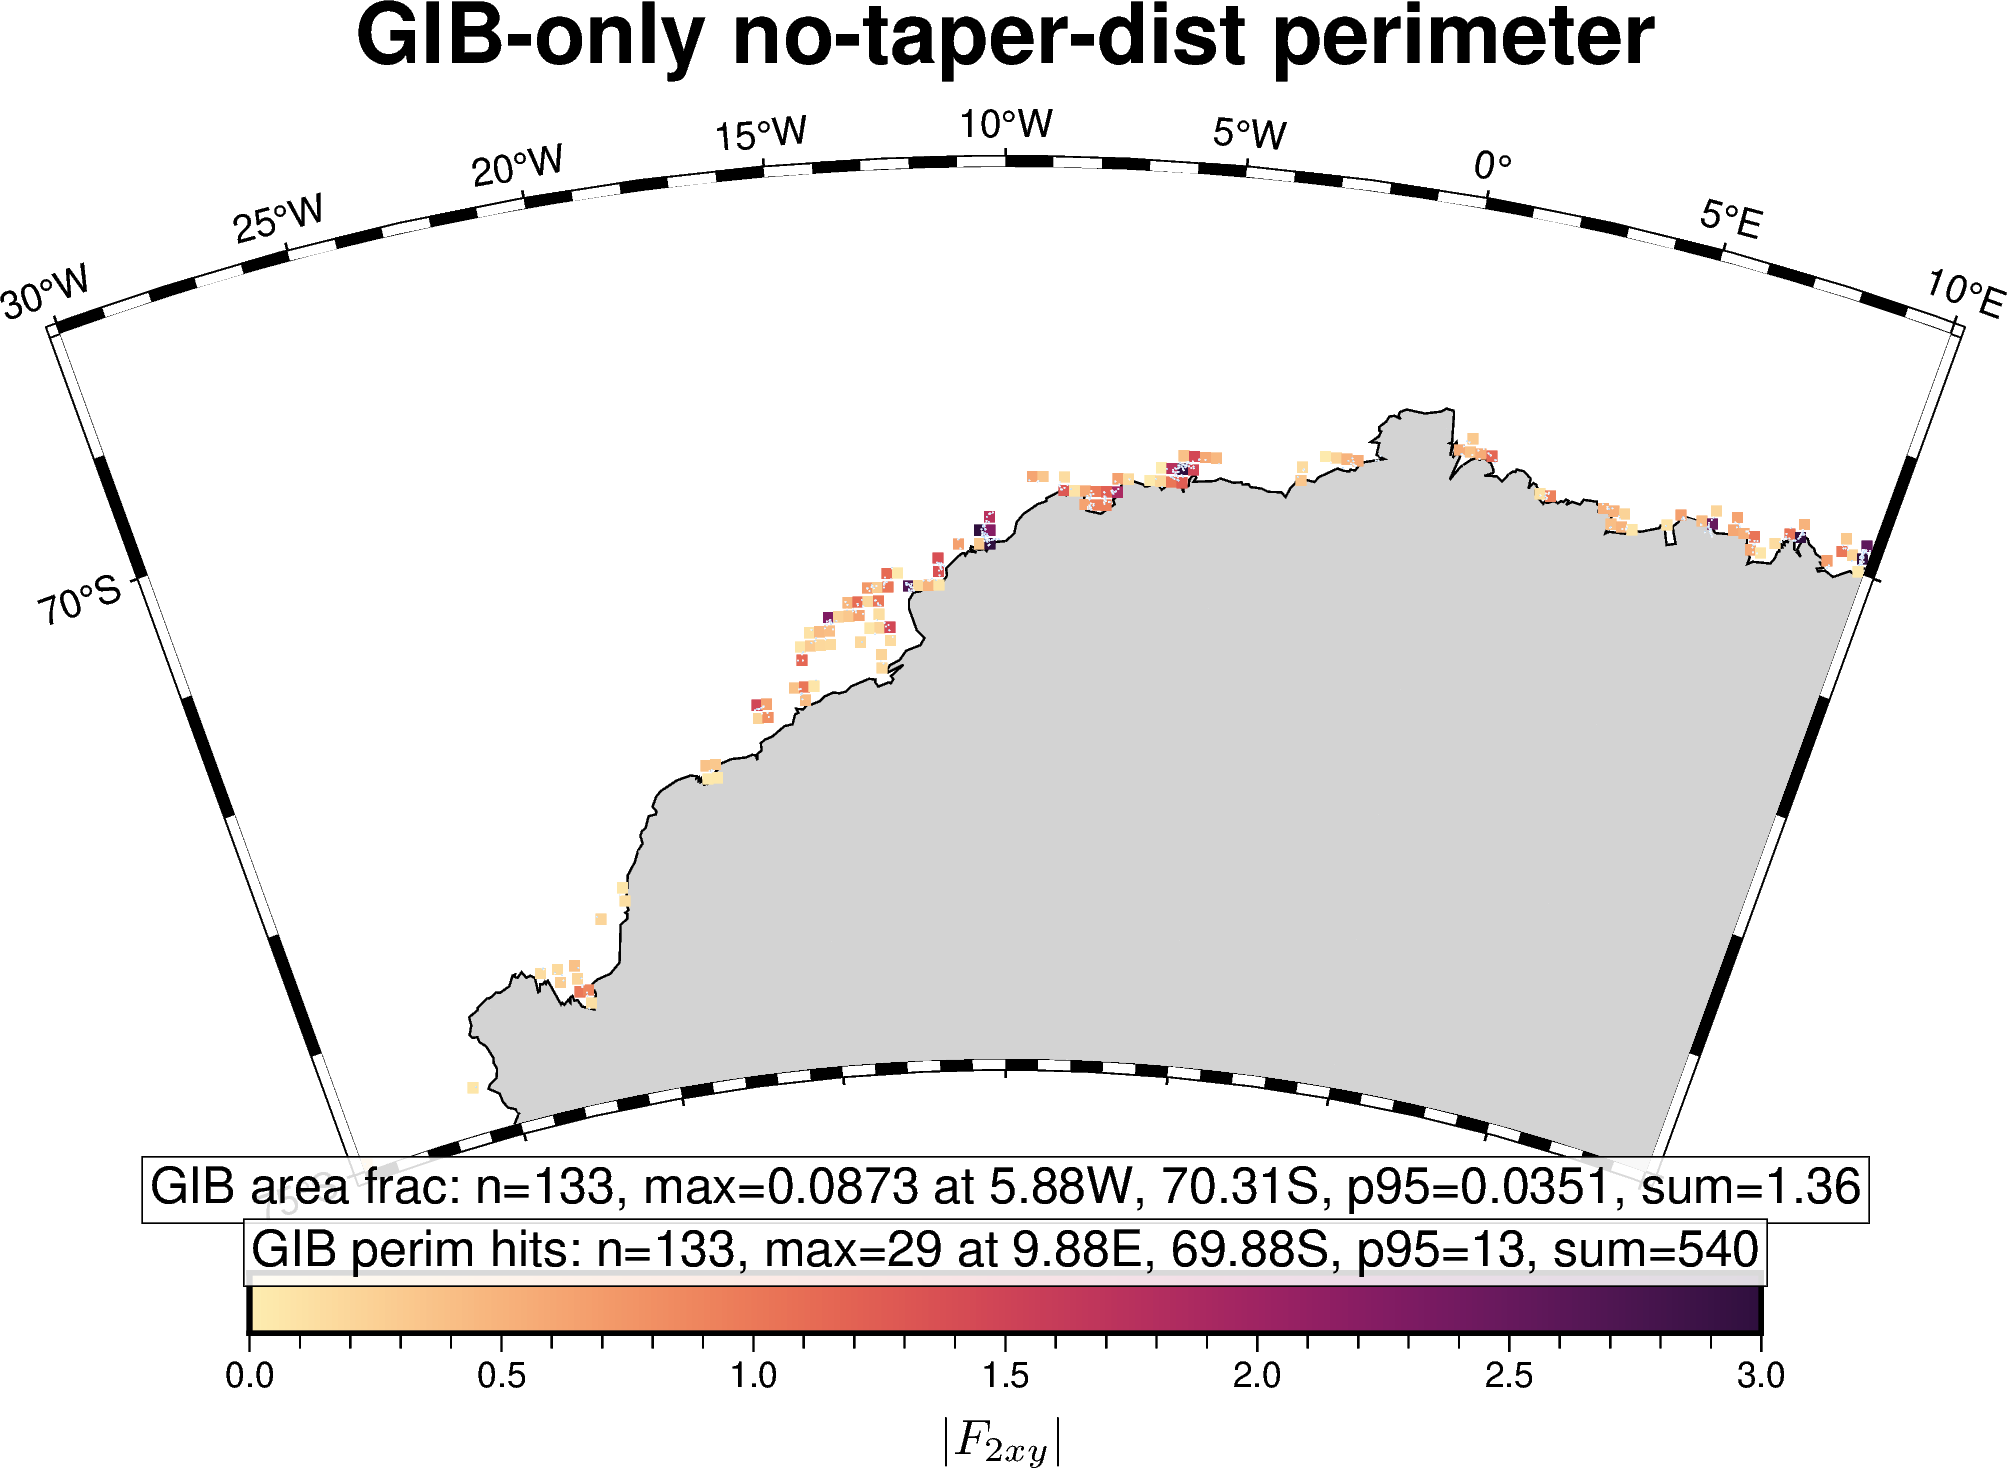

Saved: /g/data/gv90/da1339/GRAPHICAL/LD-pub-workspace/form-factors/gib_only/no_taper/WIO/FF_gib-only_GIB-v1p2_WIO.png


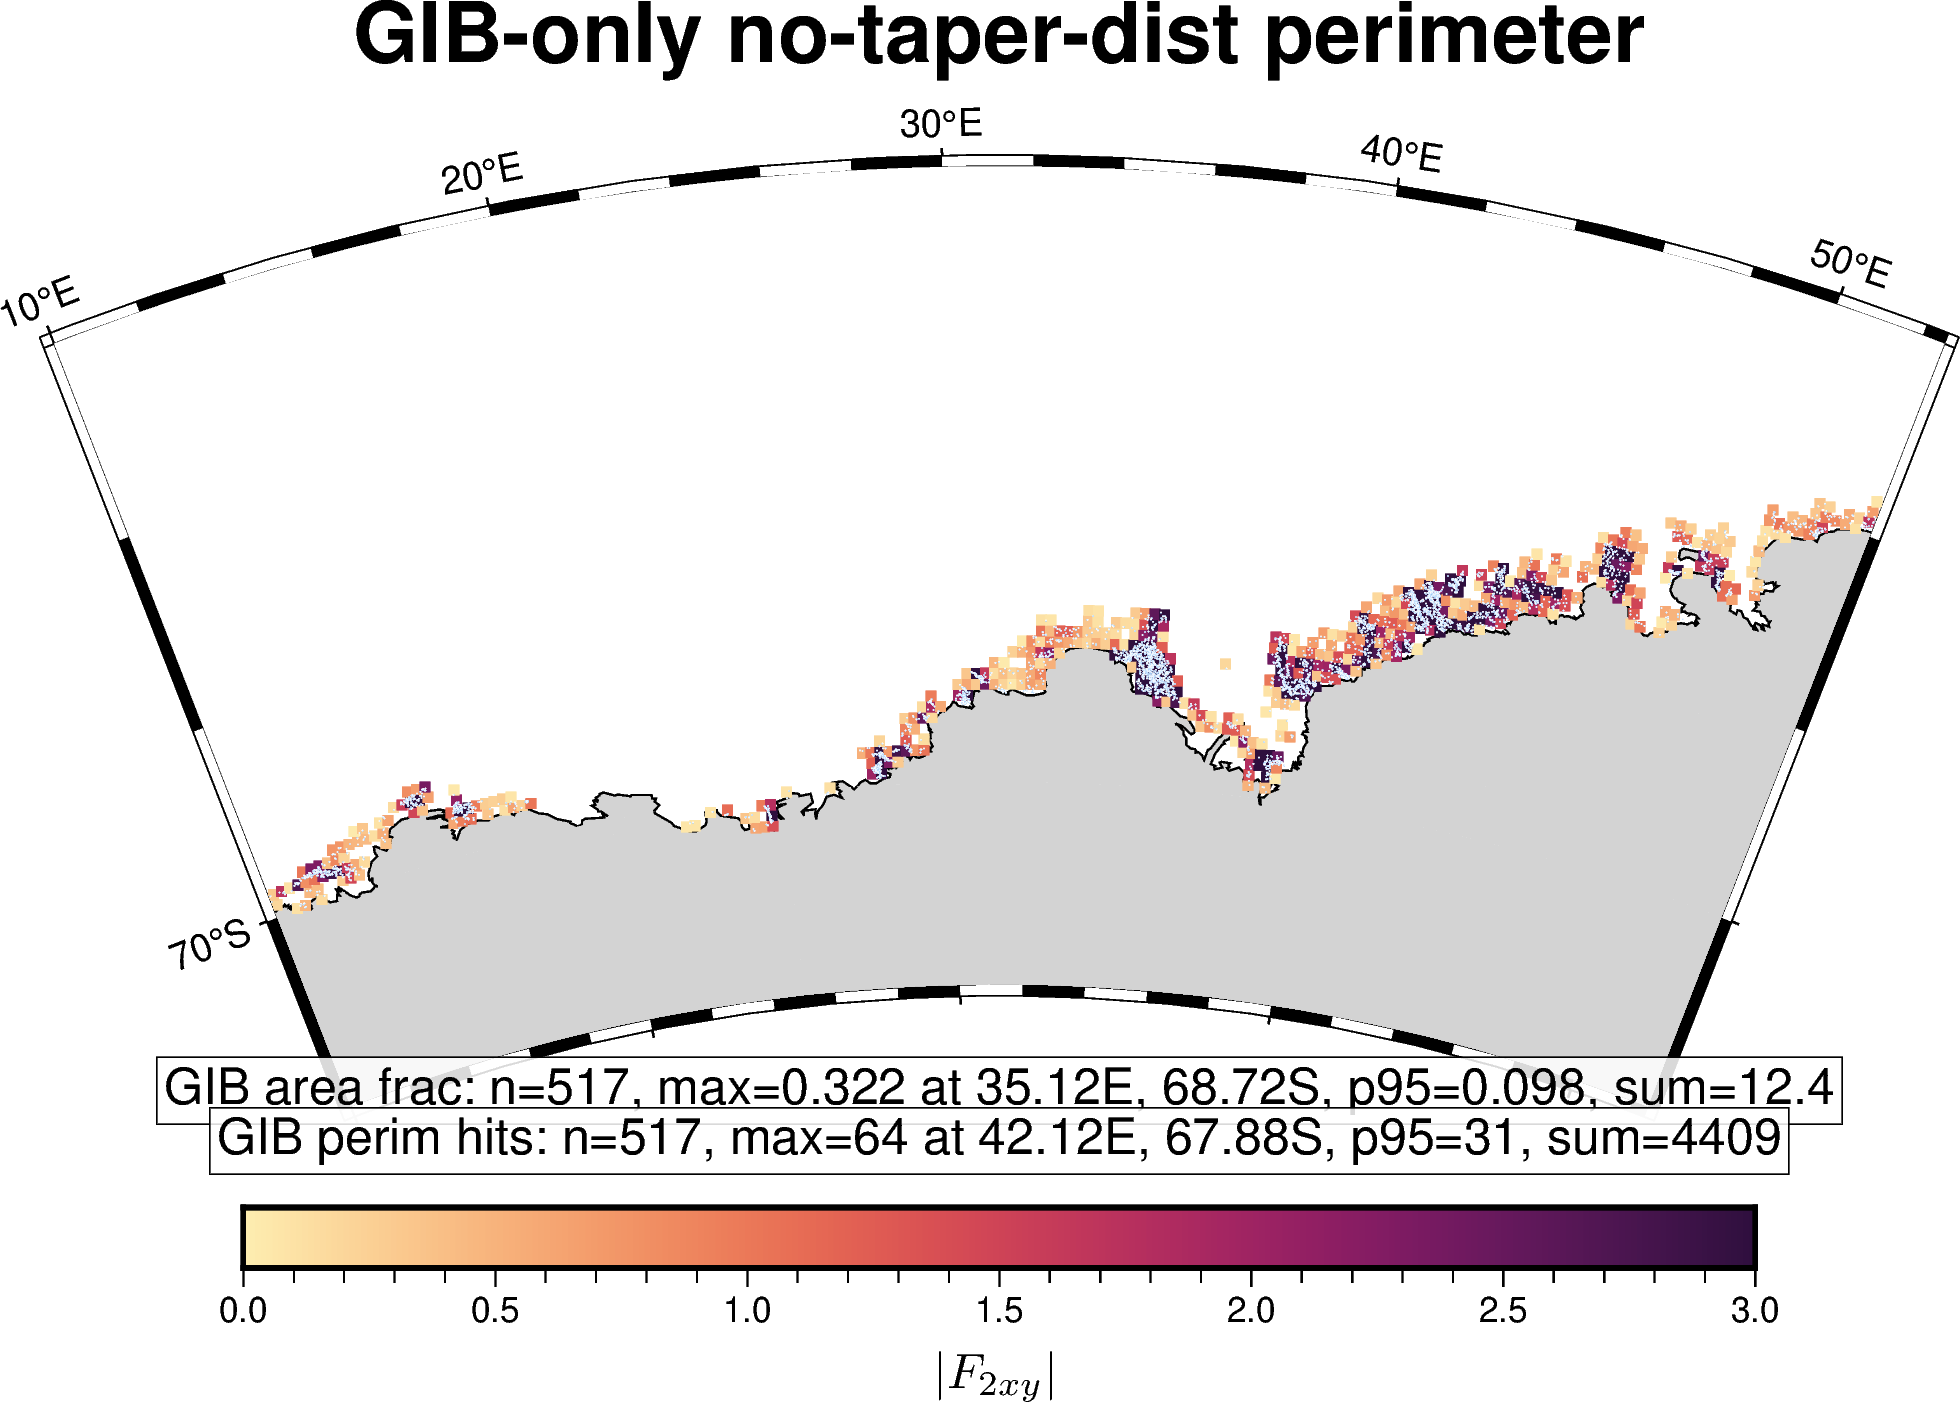

Saved: /g/data/gv90/da1339/GRAPHICAL/LD-pub-workspace/form-factors/gib_only/no_taper/EIO/FF_gib-only_GIB-v1p2_EIO.png


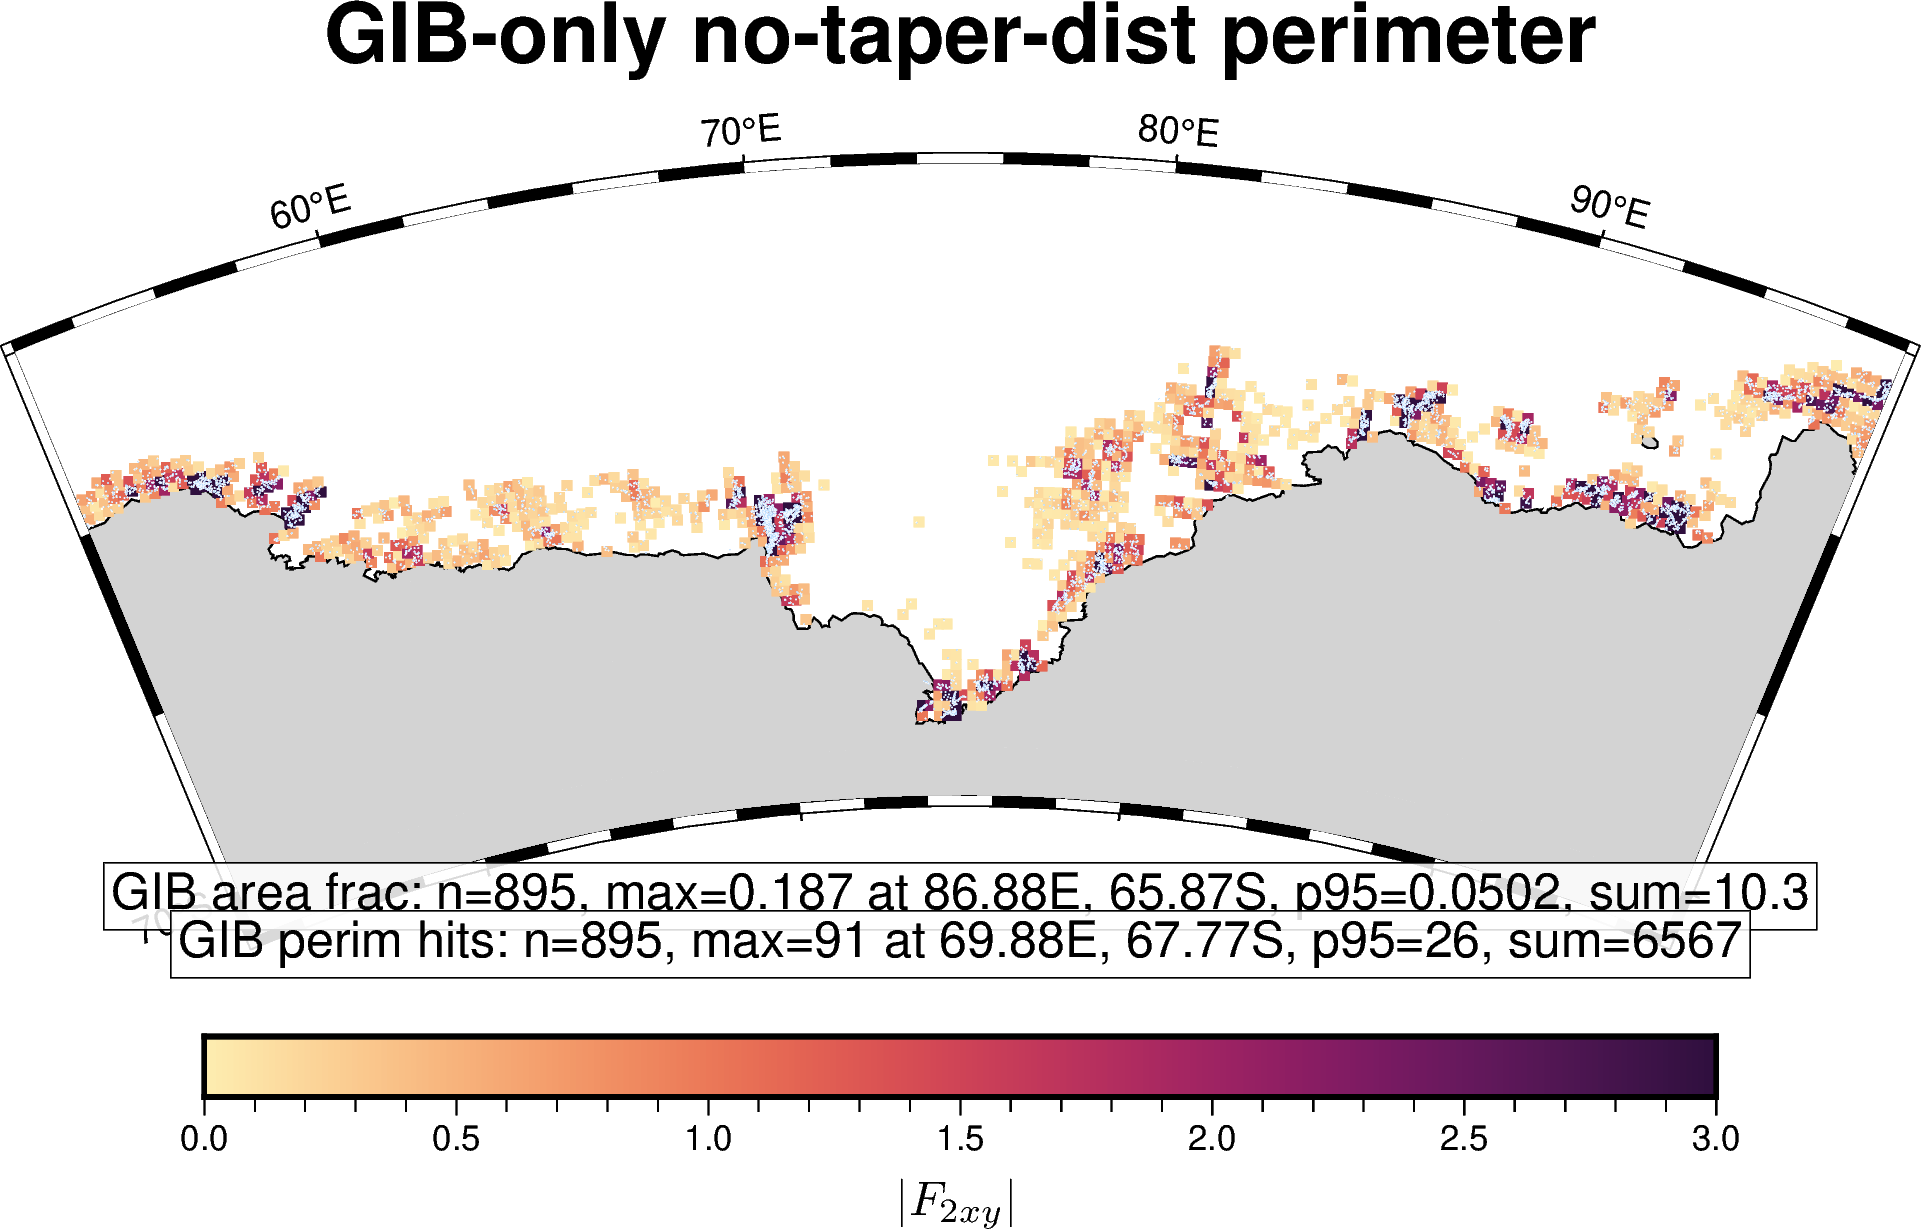

Saved: /g/data/gv90/da1339/GRAPHICAL/LD-pub-workspace/form-factors/gib_only/no_taper/Aus/FF_gib-only_GIB-v1p2_Aus.png


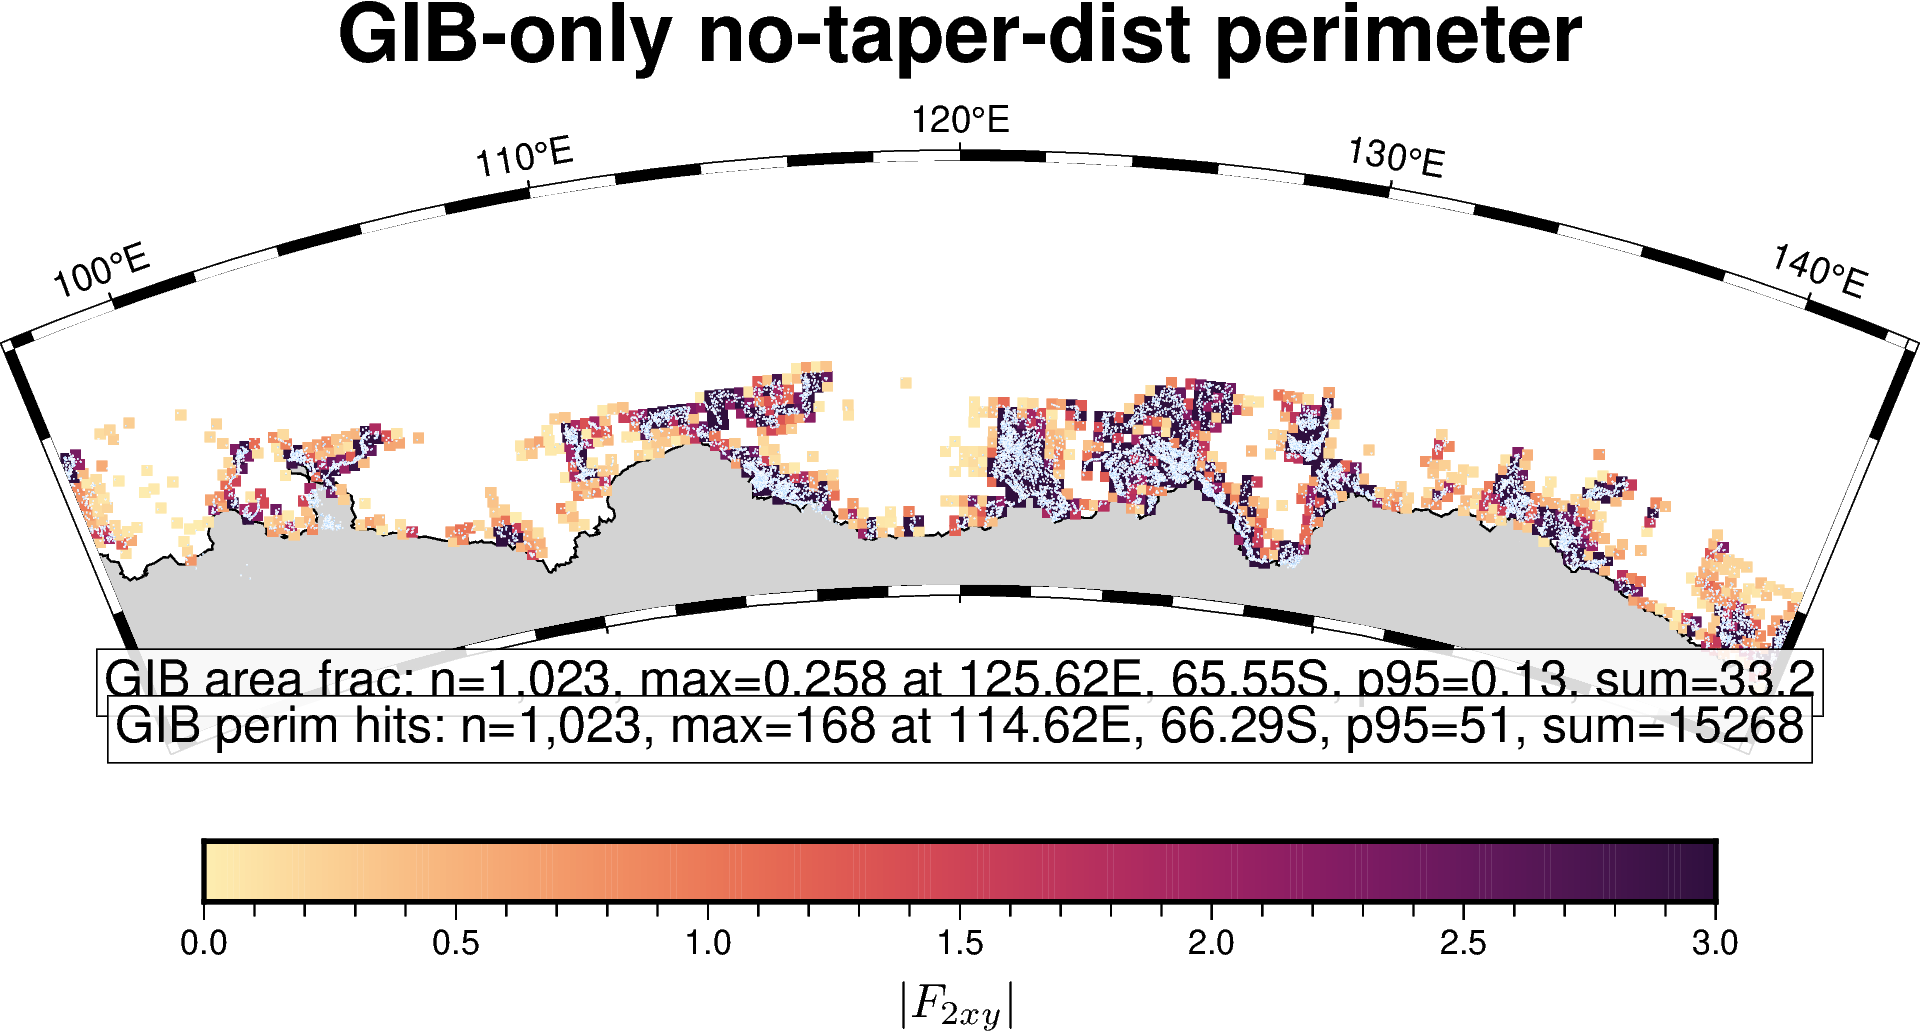

Saved: /g/data/gv90/da1339/GRAPHICAL/LD-pub-workspace/form-factors/gib_only/no_taper/VOL/FF_gib-only_GIB-v1p2_VOL.png


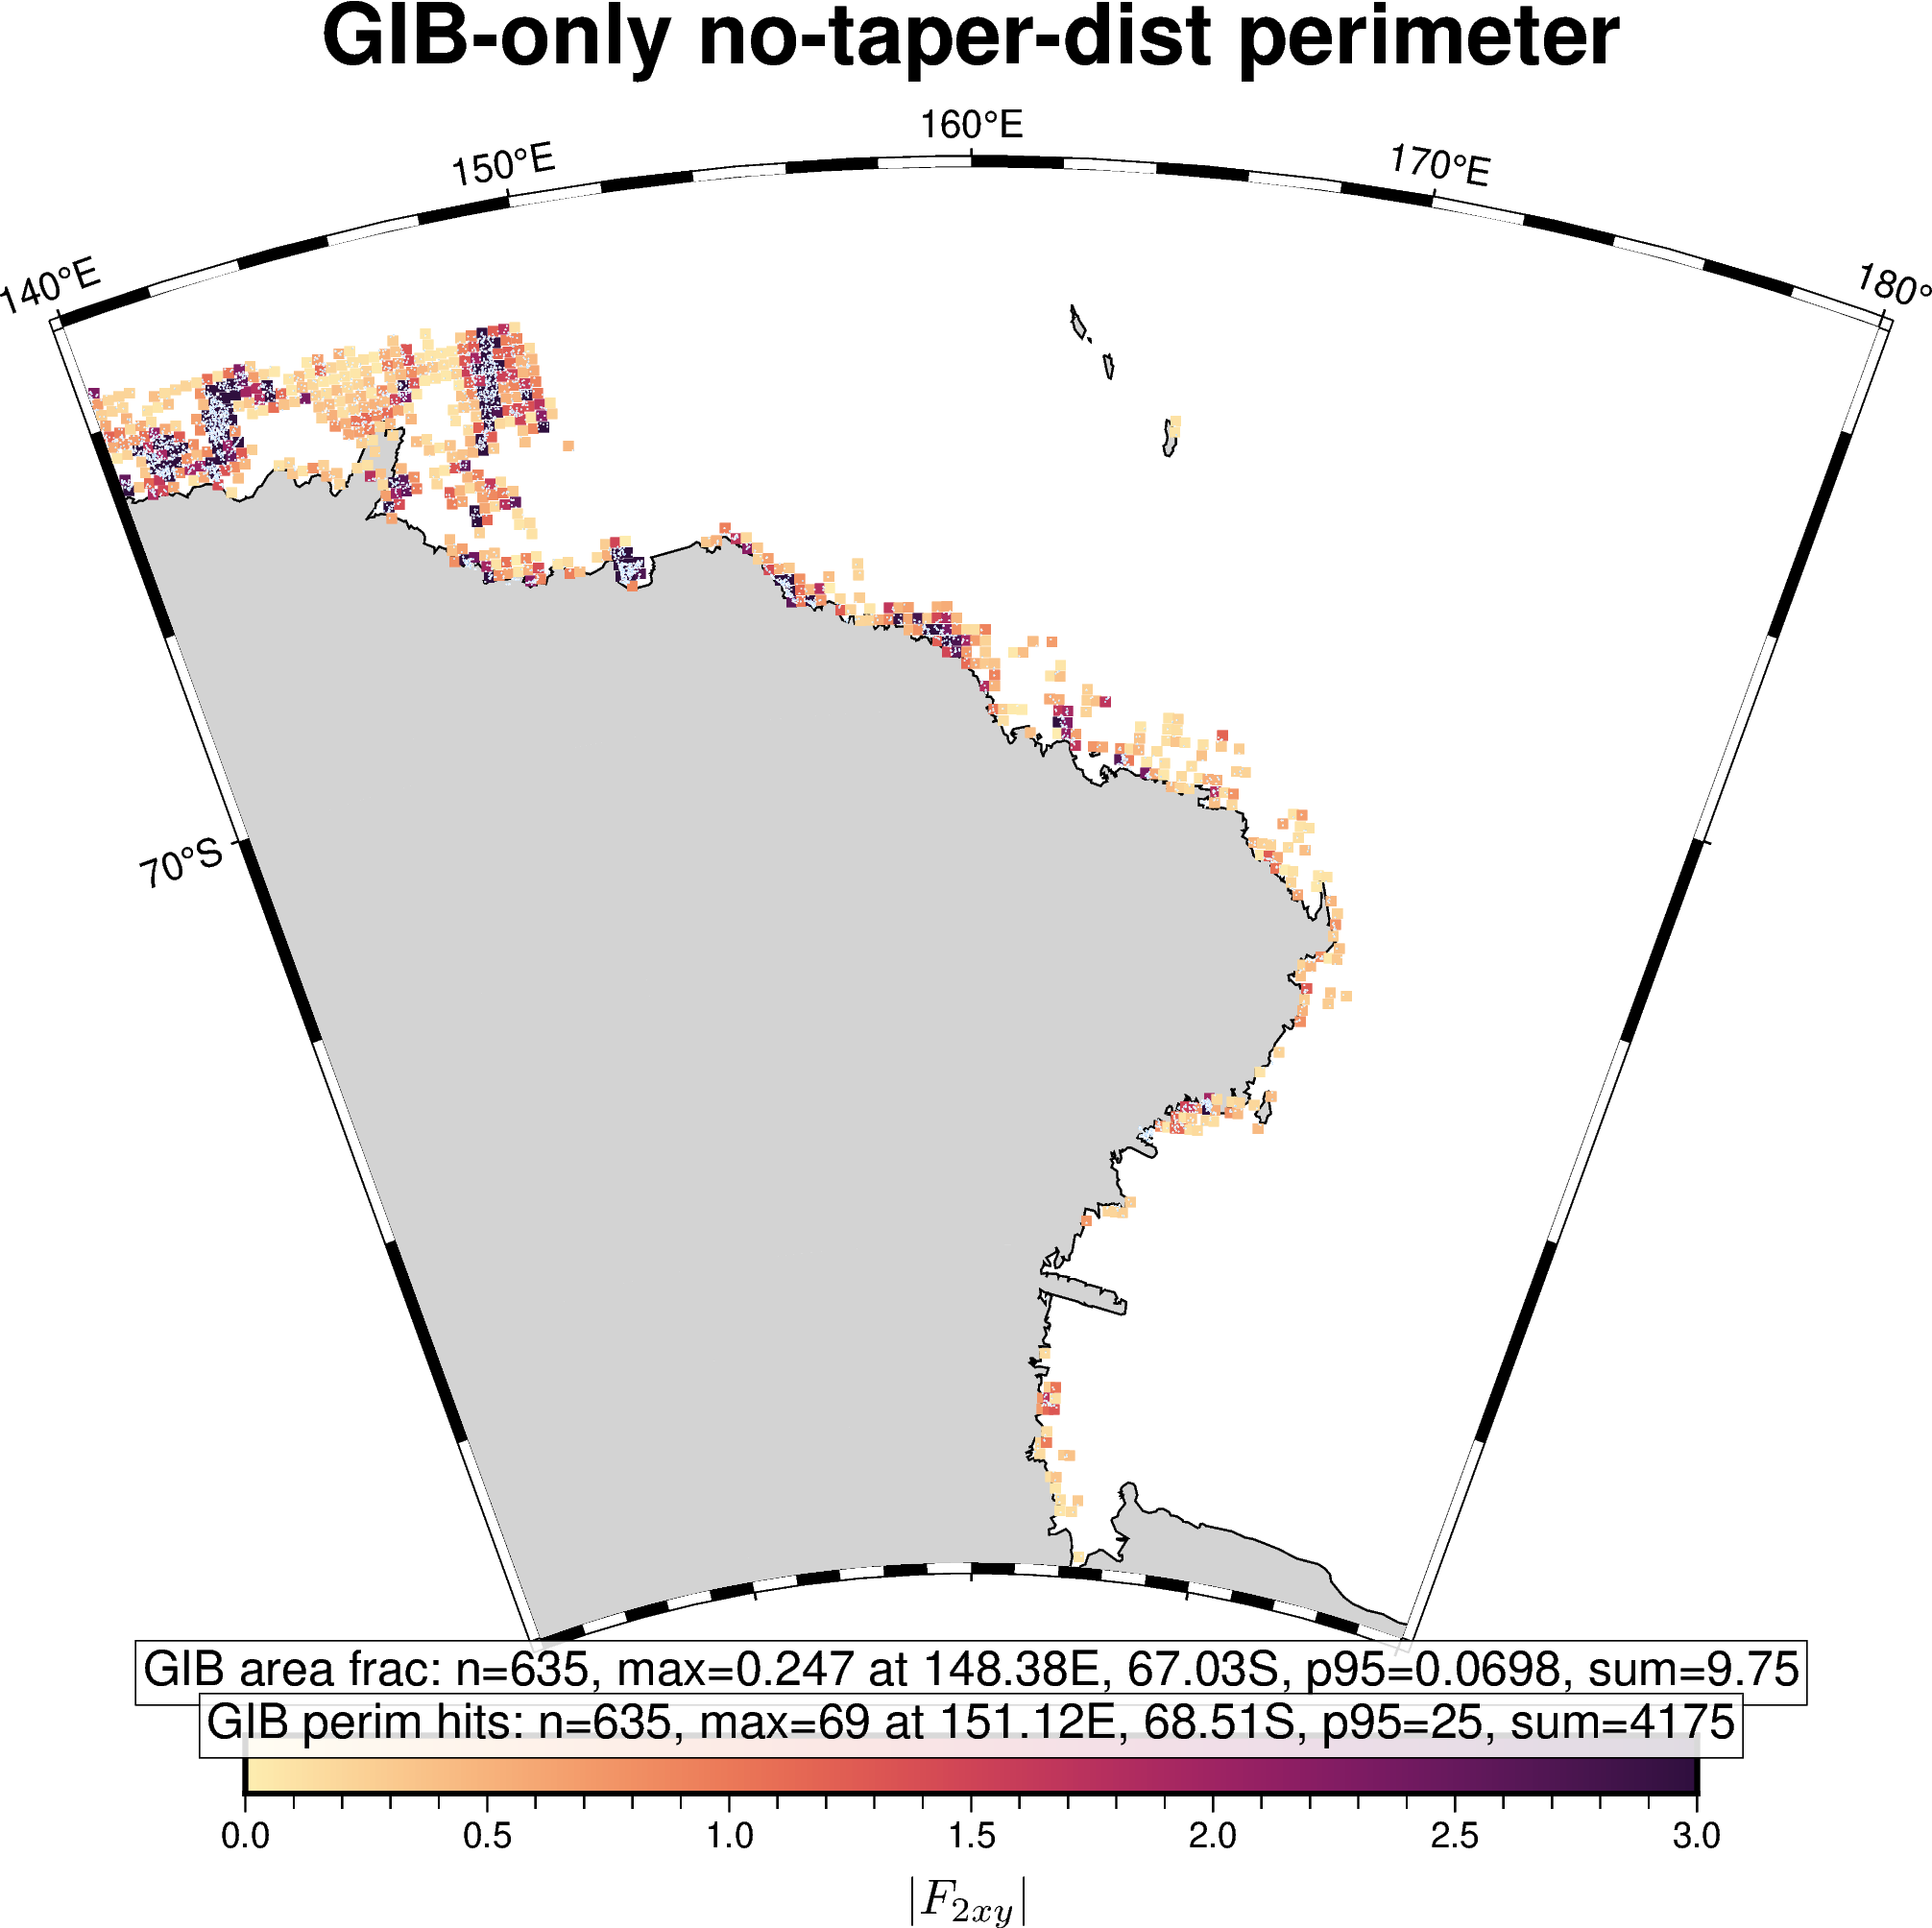

Saved: /g/data/gv90/da1339/GRAPHICAL/LD-pub-workspace/form-factors/gib_only/no_taper/AS/FF_gib-only_GIB-v1p2_AS.png


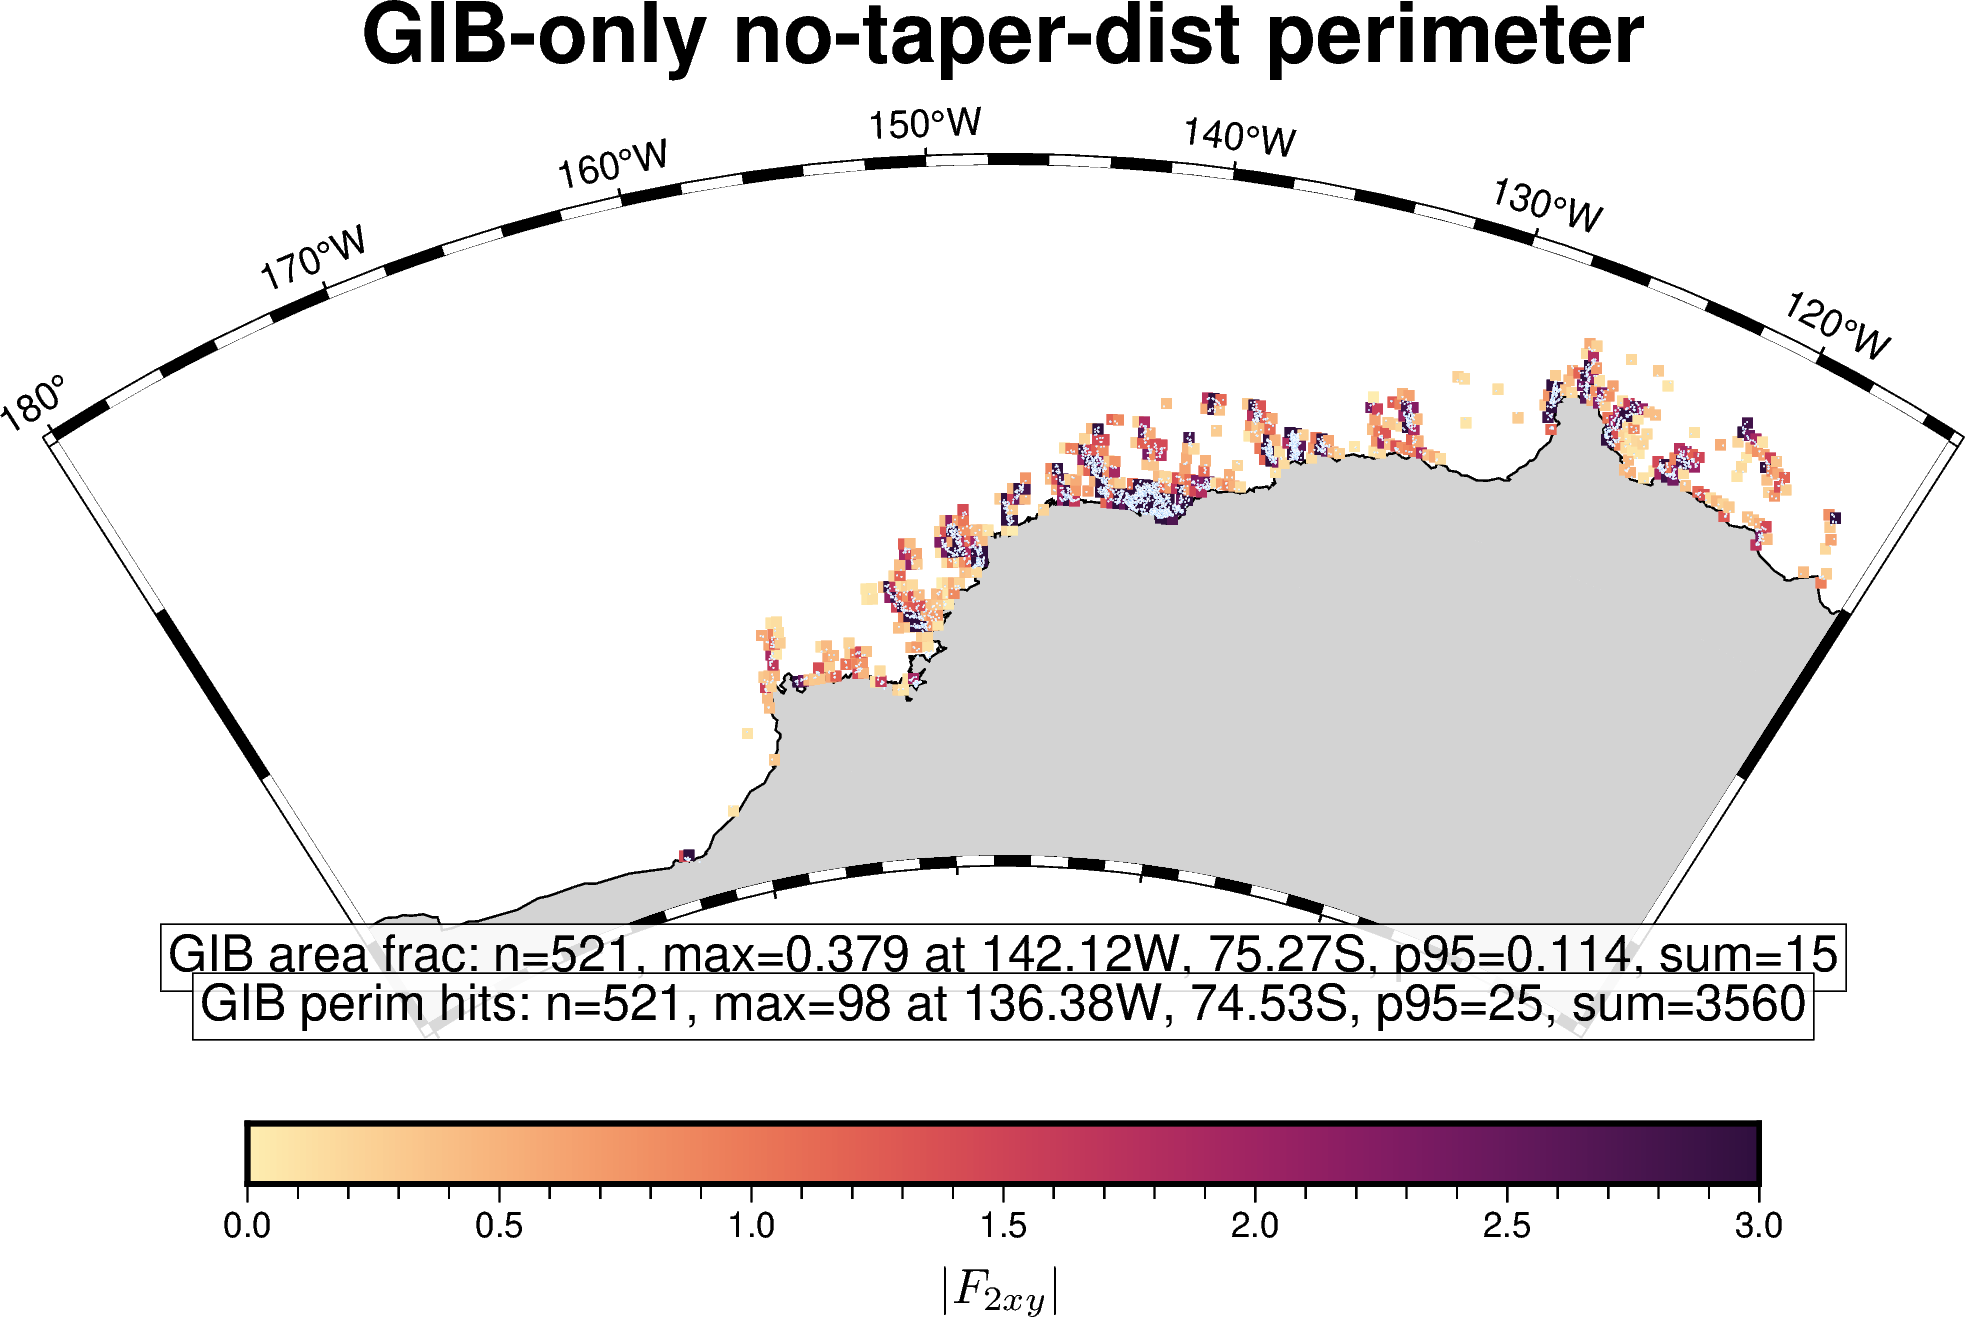

Saved: /g/data/gv90/da1339/GRAPHICAL/LD-pub-workspace/form-factors/gib_only/no_taper/BS/FF_gib-only_GIB-v1p2_BS.png


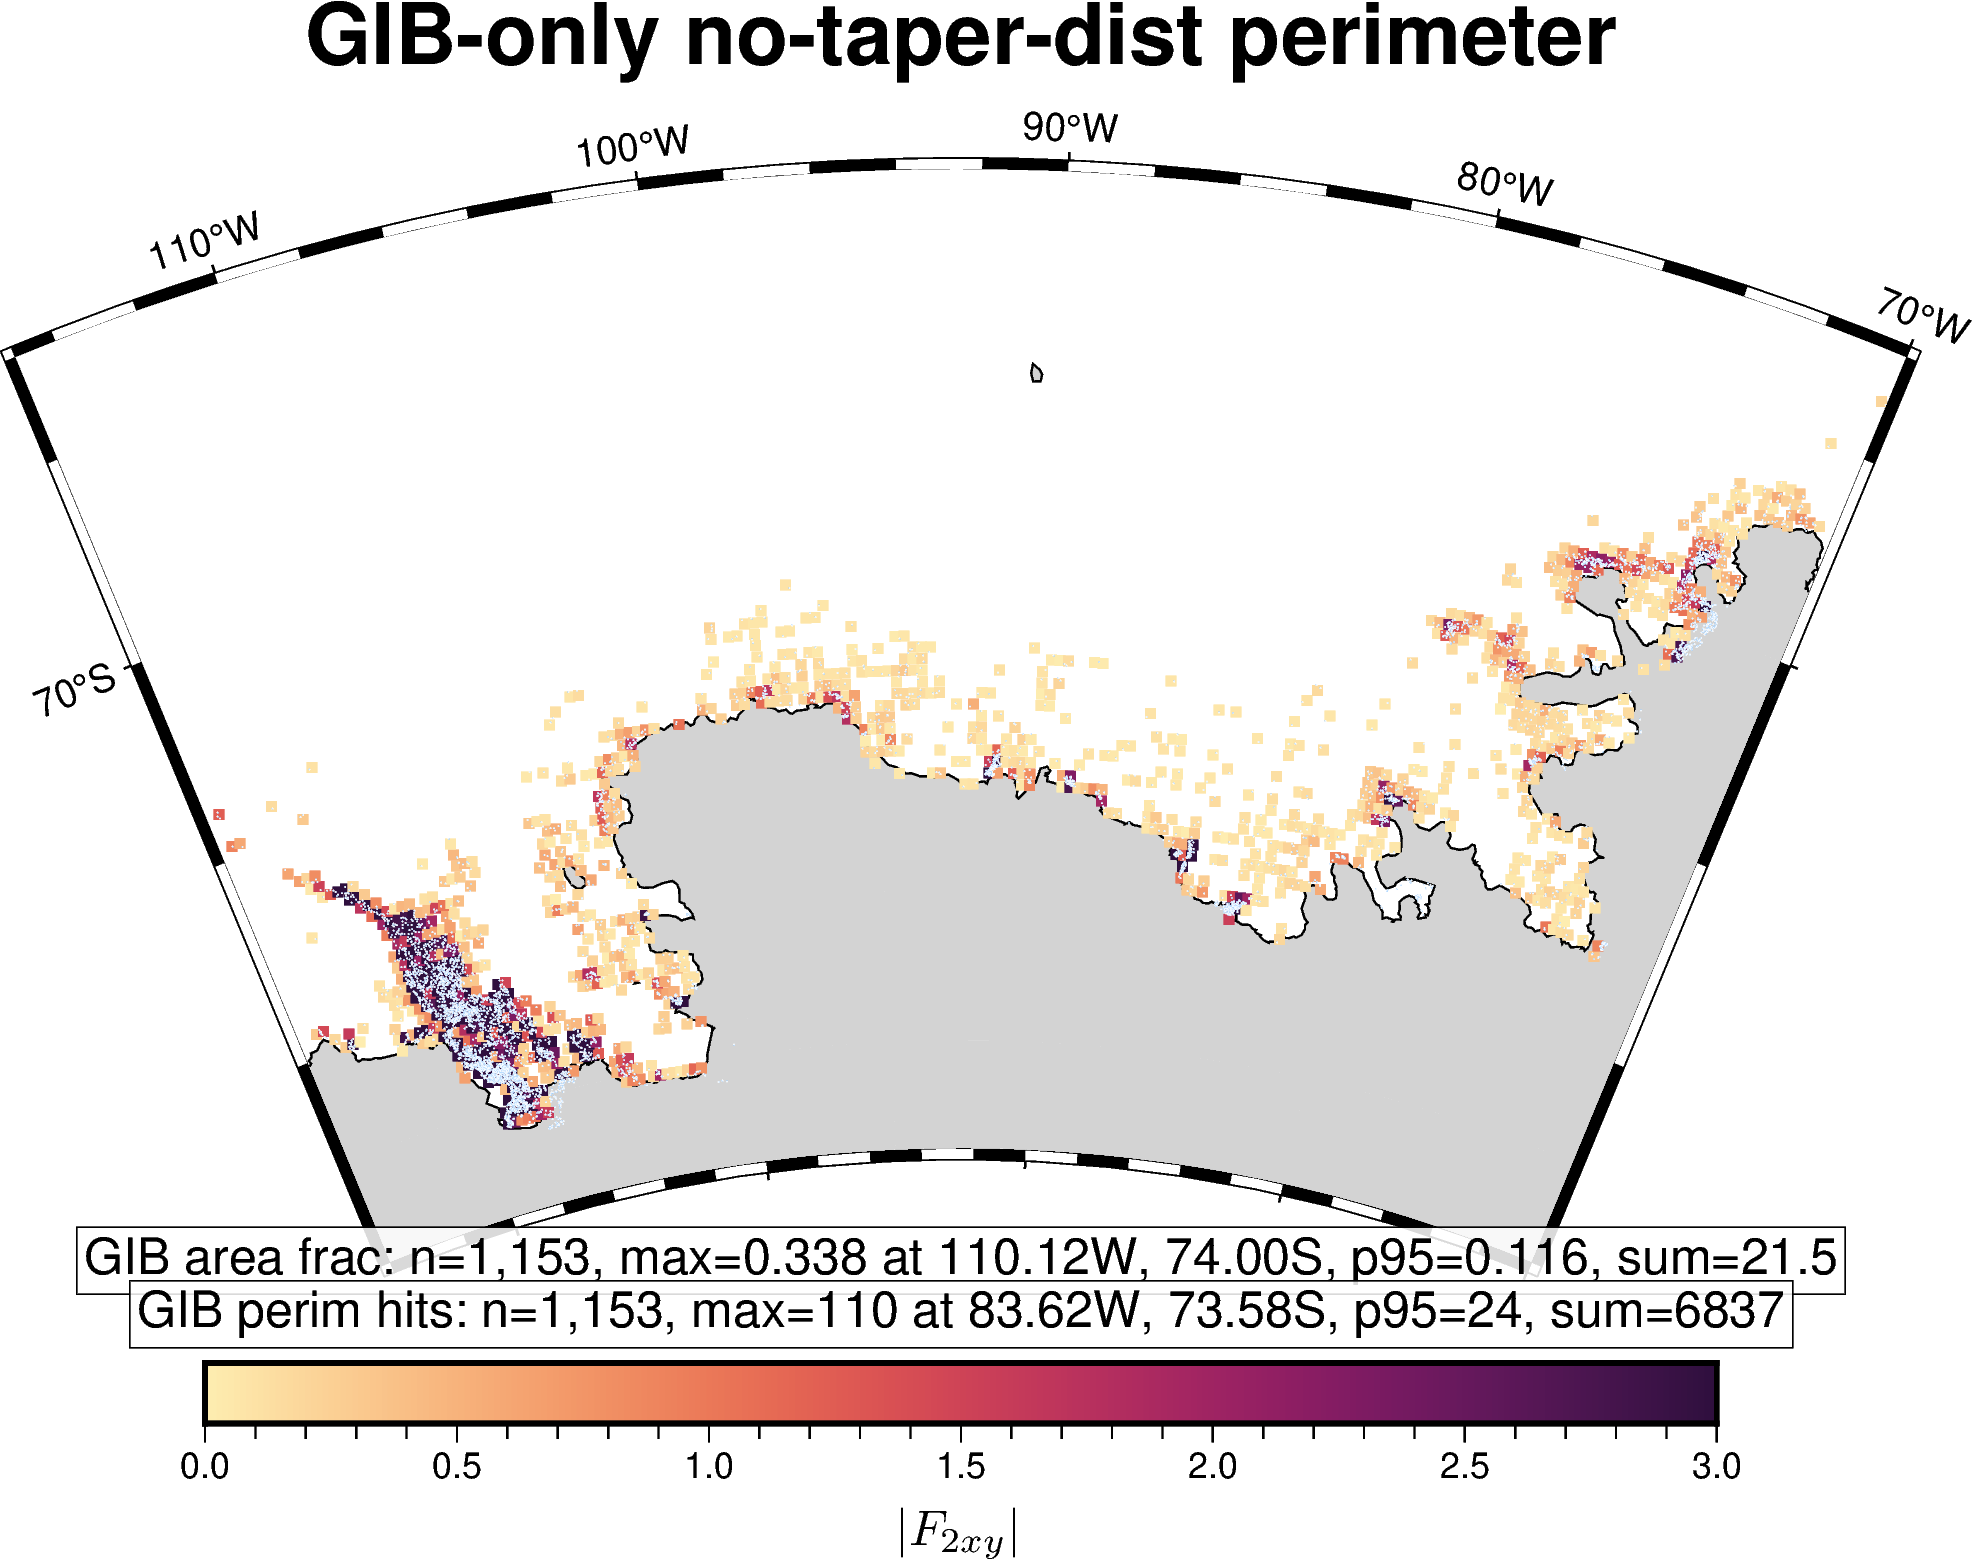

Saved: /g/data/gv90/da1339/GRAPHICAL/LD-pub-workspace/form-factors/gib_only/no_taper/WS/FF_gib-only_GIB-v1p2_WS.png


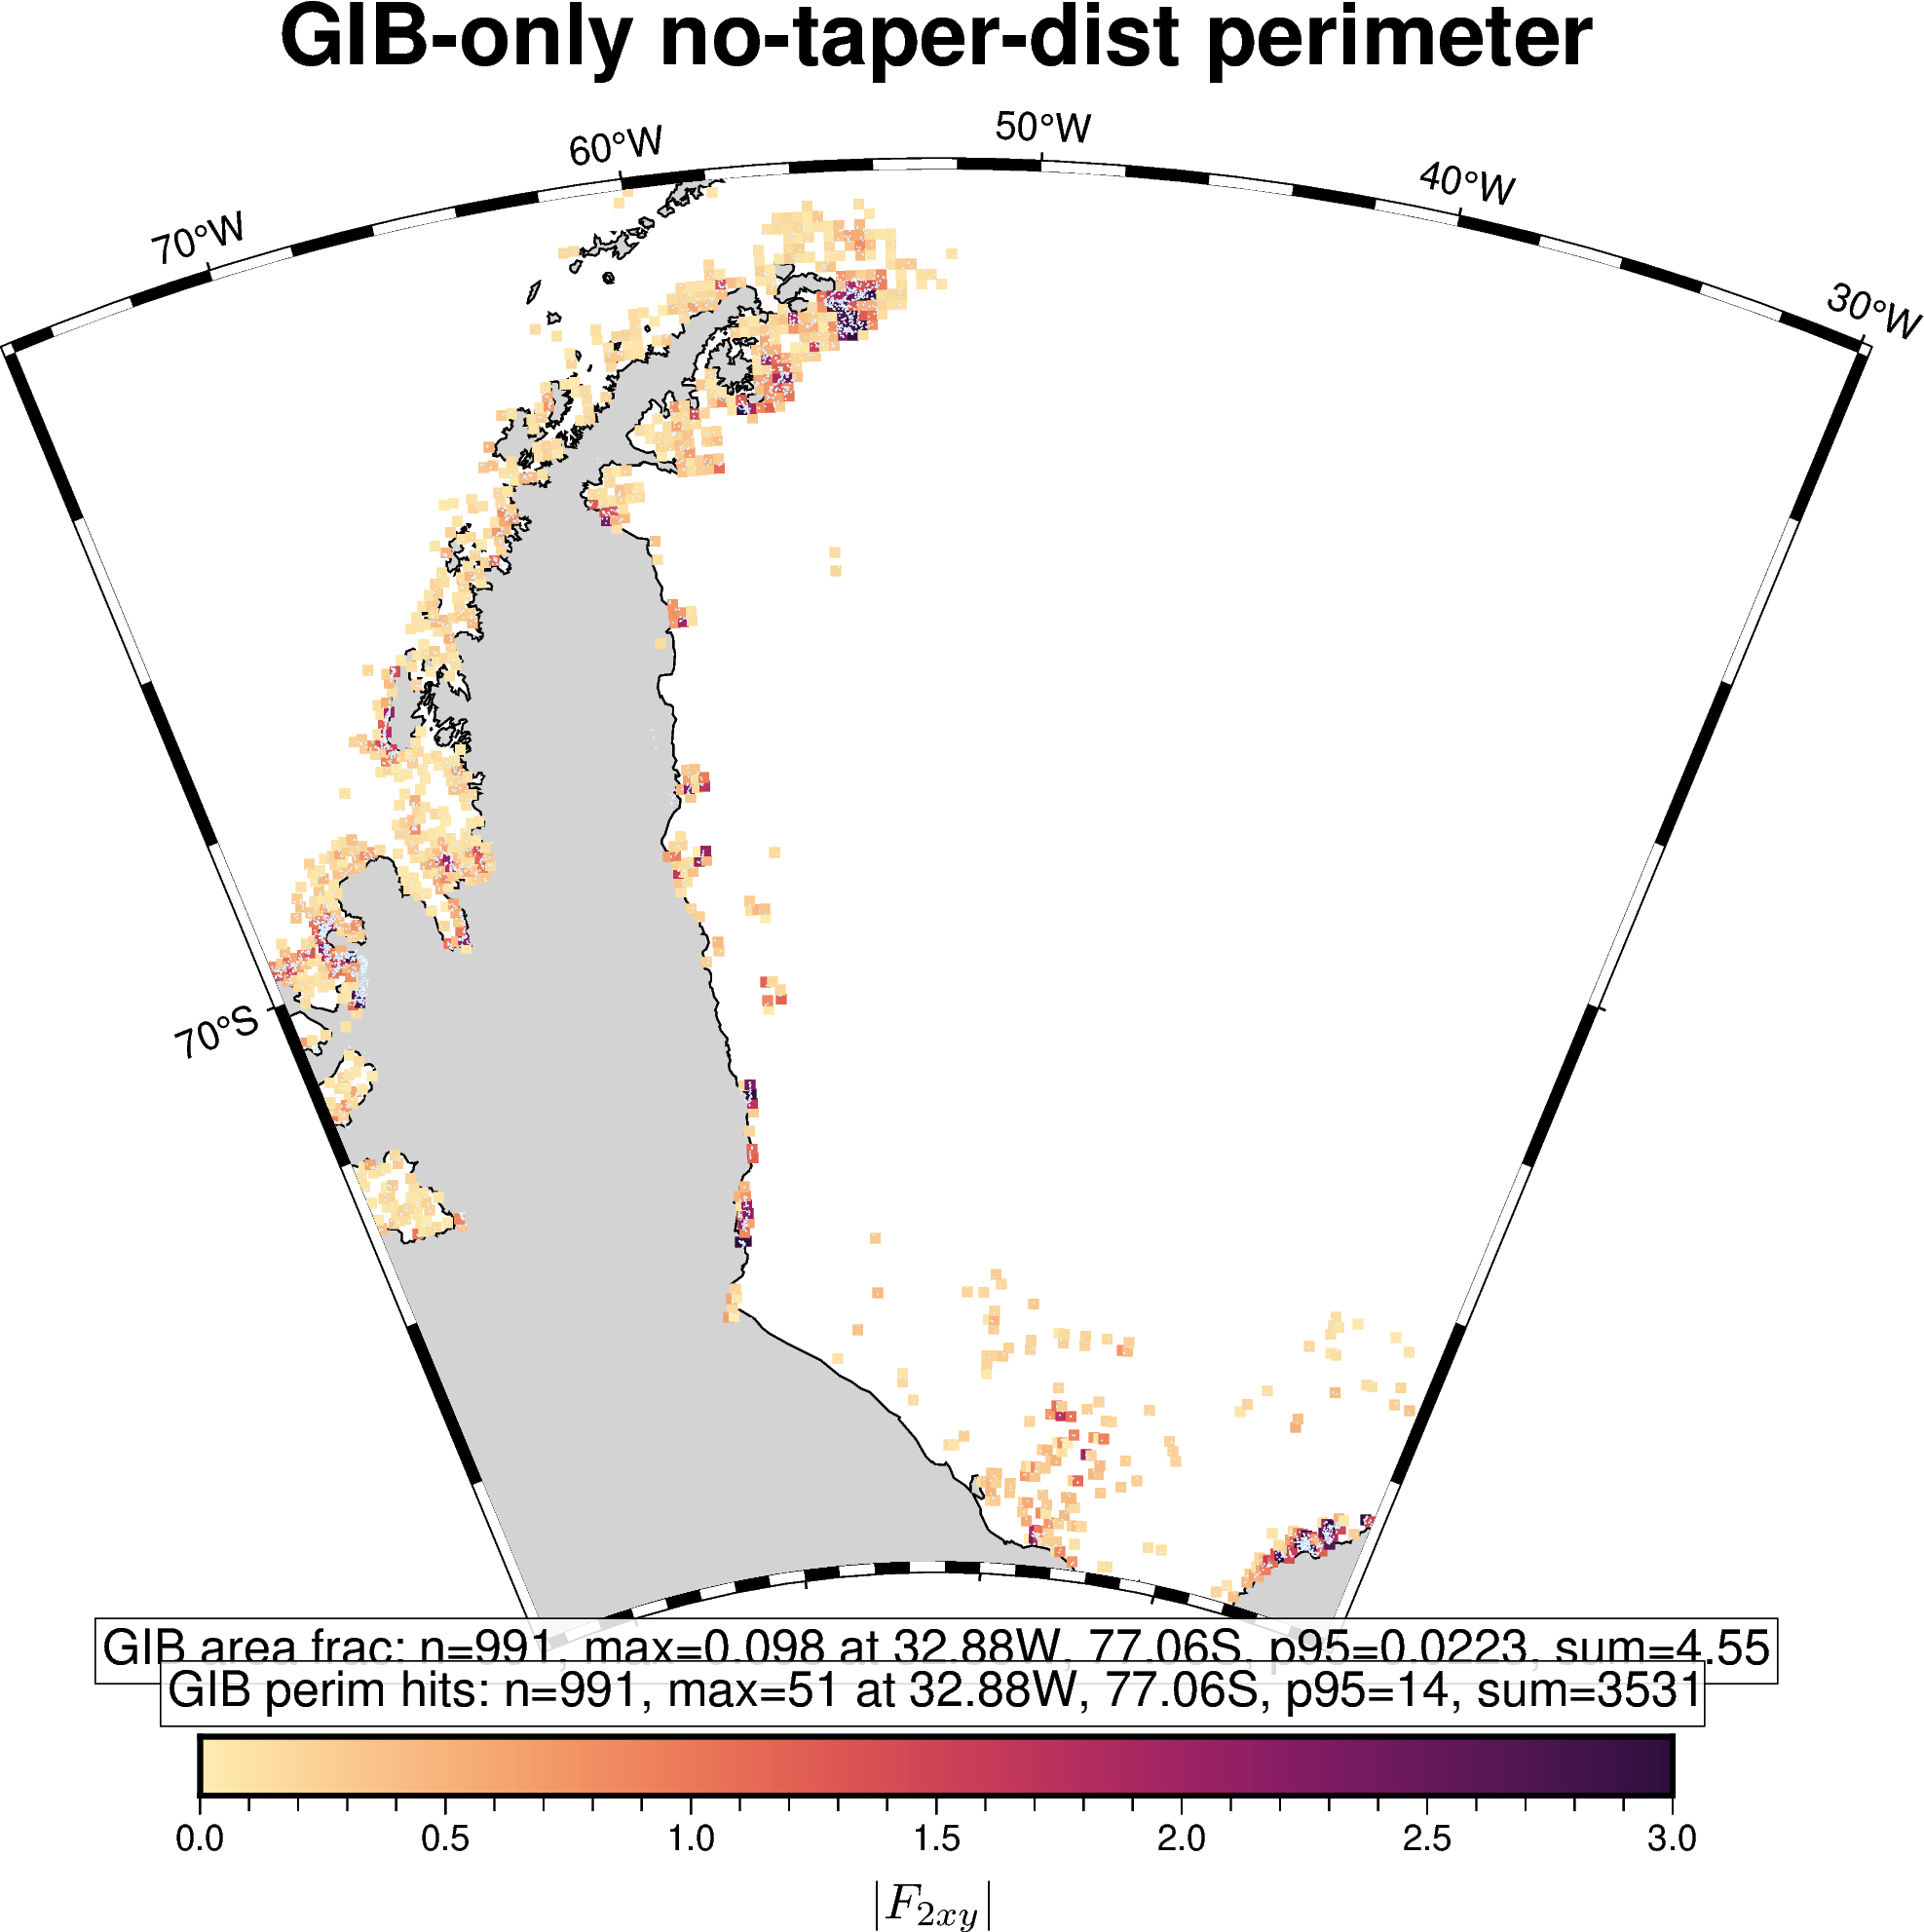

In [12]:
# GIB-only
with xr.open_dataset(P_FF_gib) as ds:
    D_ = D_root_out / 'gib_only' / 'no_taper'
    for region_name in ALL_REGIONS:
        P_png   = D_ / region_name / f'FF_gib-only_GIB-{gib_ver}_{region_name}.png'
        tit_str = 'GIB-only no-taper-dist perimeter'
        plot_form_factor_pygmt(ds                = ds,
                               out               = P_png,
                               title             = tit_str,
                               region_name       = region_name,
                               ANTARCTIC_REGIONS = ANTARCTIC_REGIONS,
                               product_kind      = 'gib-only',
                               diagnostics       = ['GIB_area_frac', 'GIB_n_perimeter_hits'],
                               show_diagnostics  = True,
                               gib_points        = GIB_pts,
                               show_gib_points   = SHOW_GIB_POINTS_ON_GIB)

text [WARNING]: Latitude (-90.5) at line # 1 exceeds -|+ 90! - set to NaN


Saved: /g/data/gv90/da1339/GRAPHICAL/LD-pub-workspace/form-factors/cmb/no_taper/SH/FF_cmb_meth-max_cst-v7p9_GIB-v1p2_SH.png


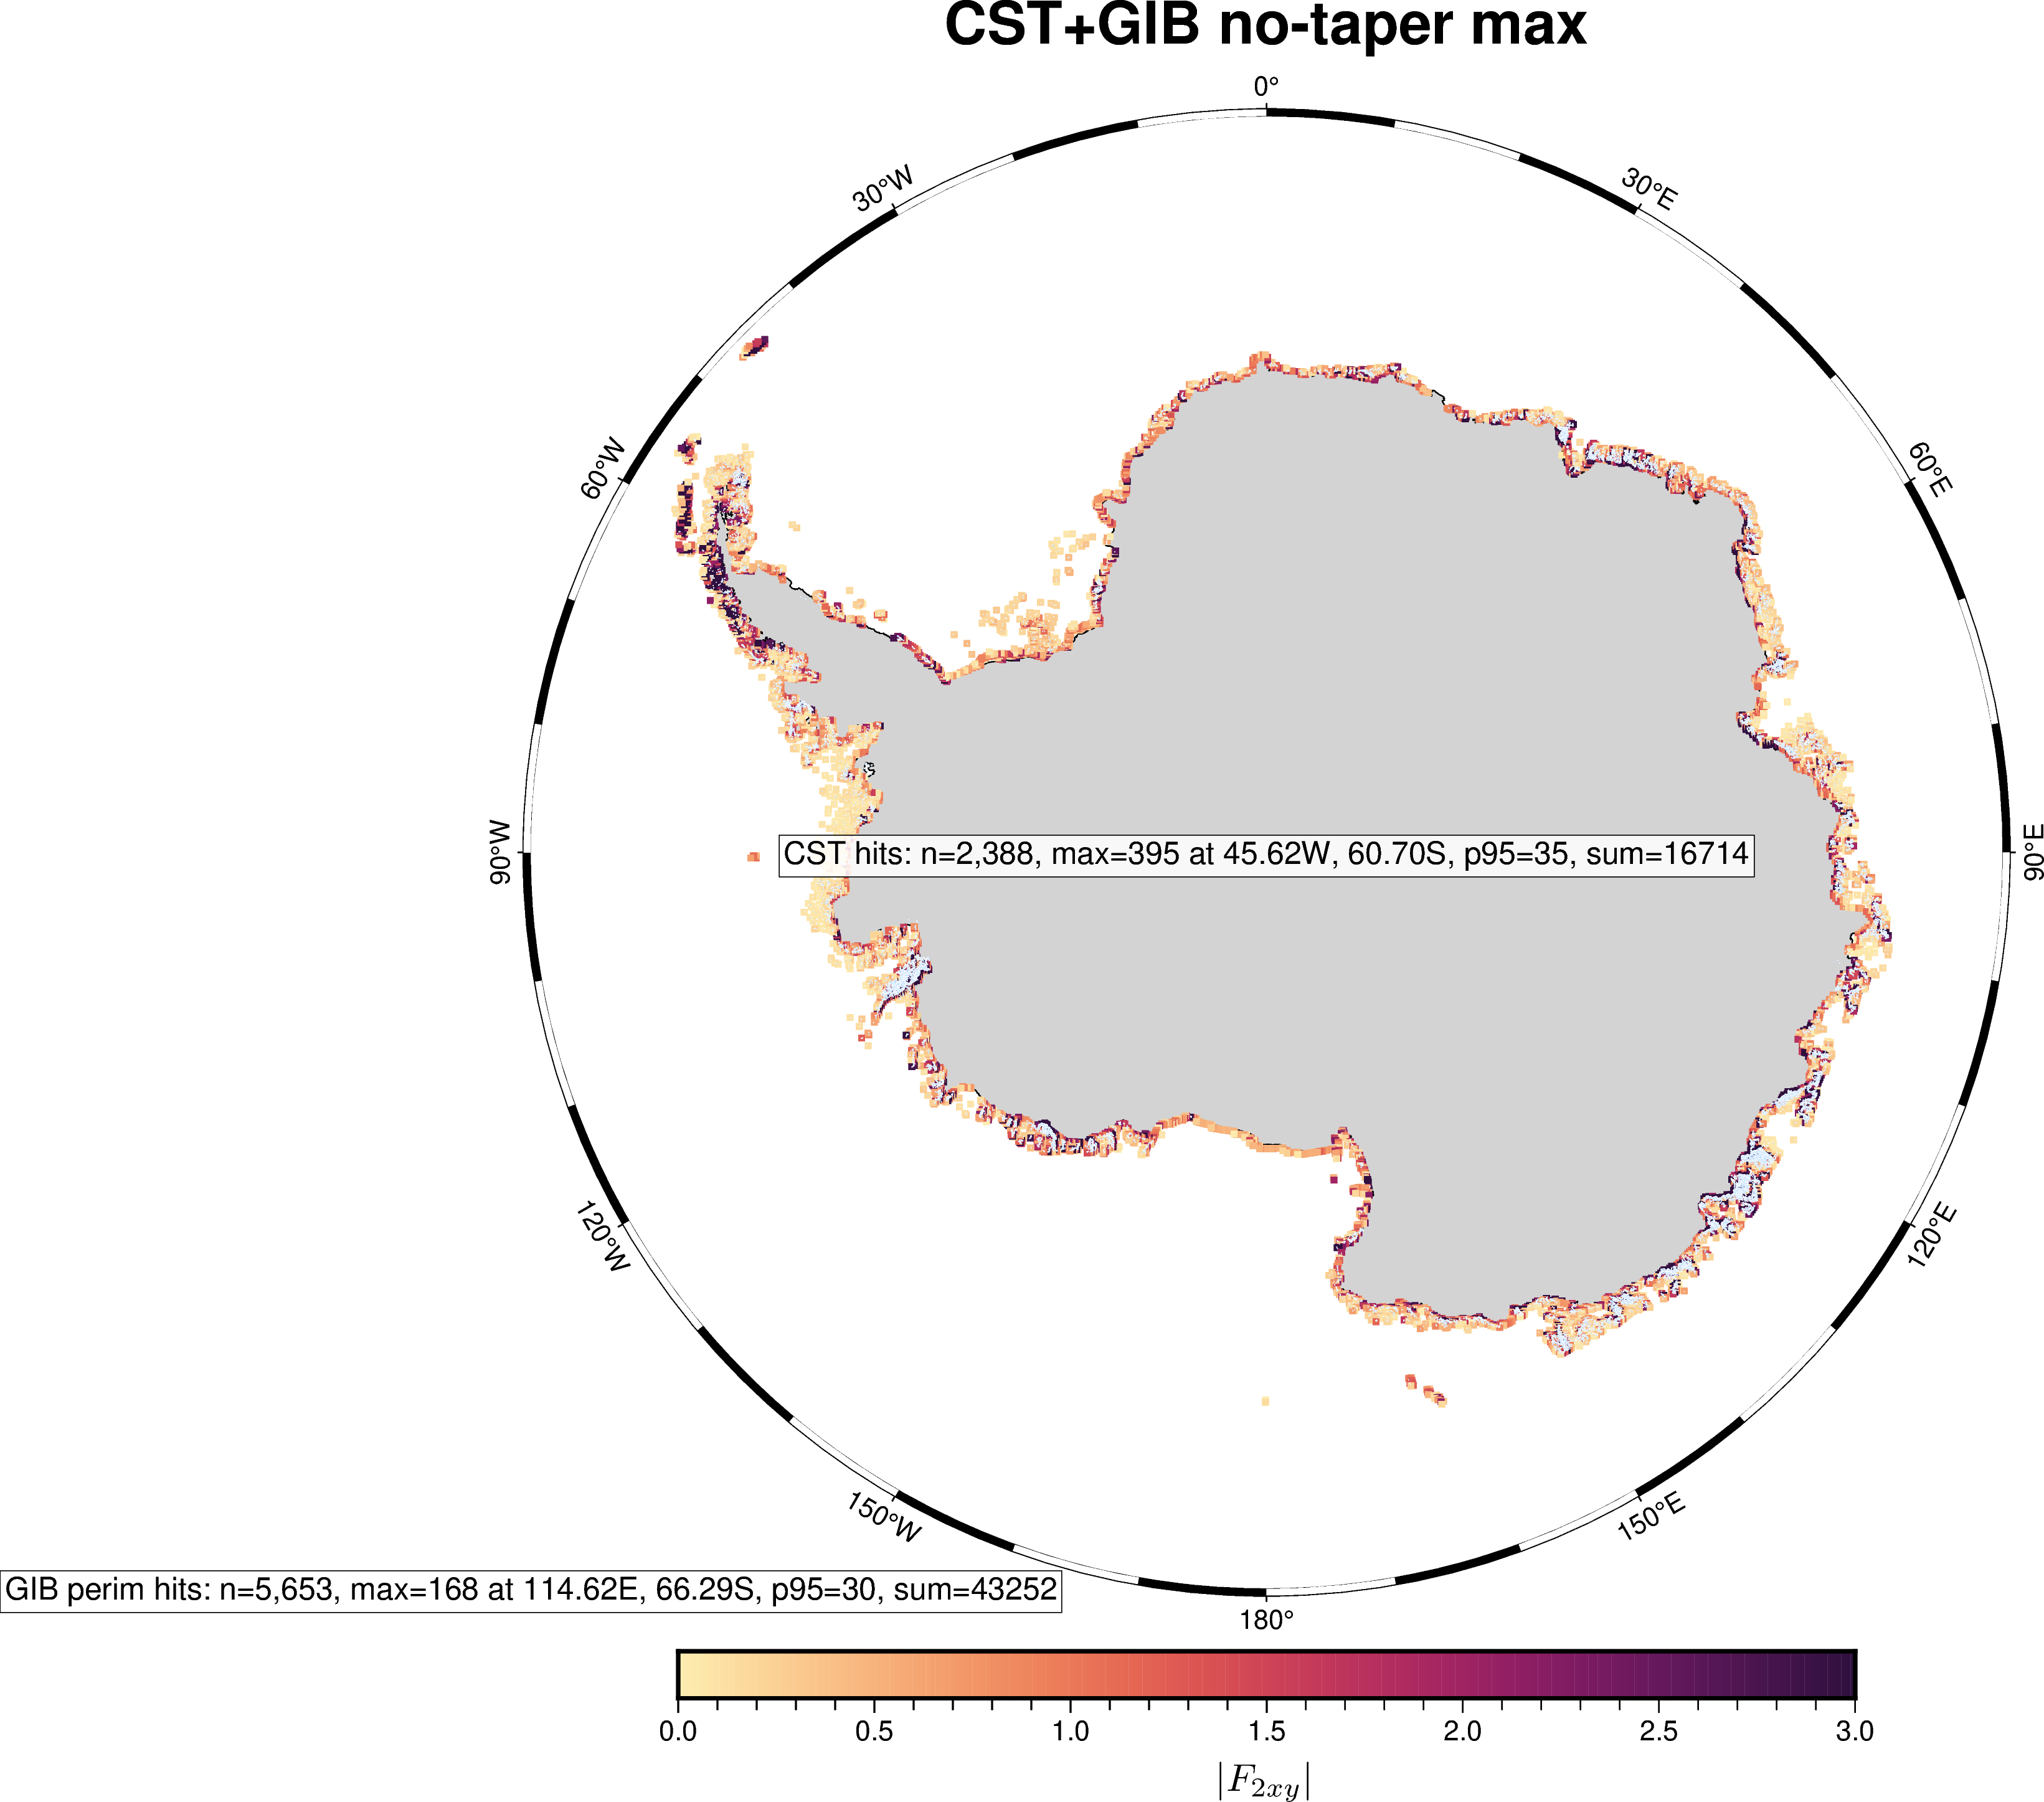

Saved: /g/data/gv90/da1339/GRAPHICAL/LD-pub-workspace/form-factors/cmb/no_taper/DML/FF_cmb_meth-max_cst-v7p9_GIB-v1p2_DML.png


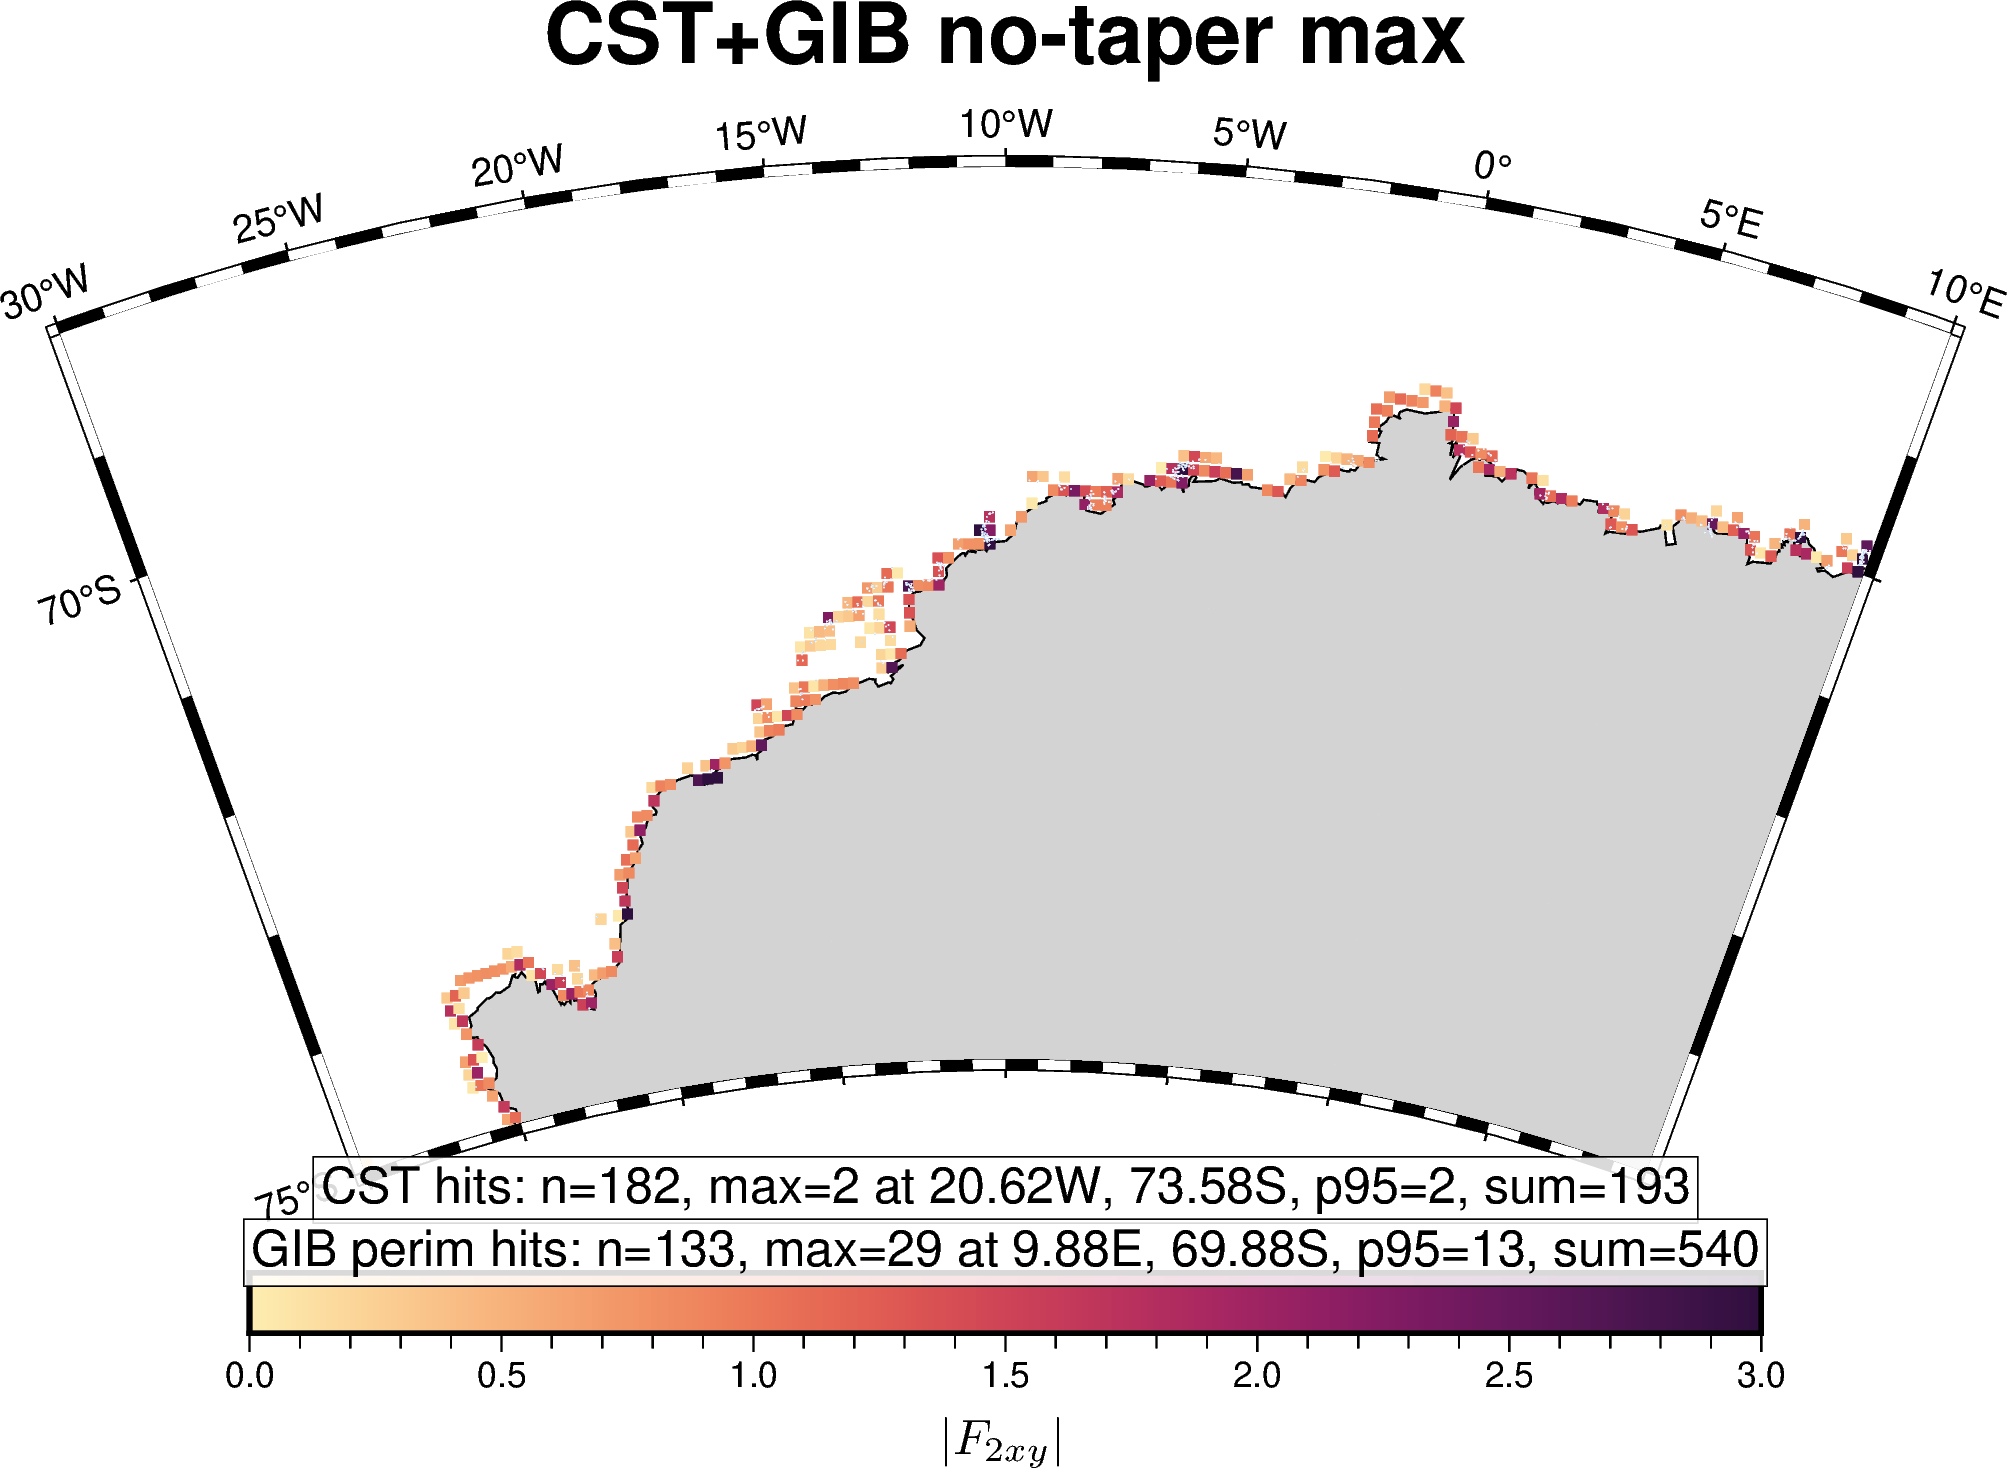

Saved: /g/data/gv90/da1339/GRAPHICAL/LD-pub-workspace/form-factors/cmb/no_taper/WIO/FF_cmb_meth-max_cst-v7p9_GIB-v1p2_WIO.png


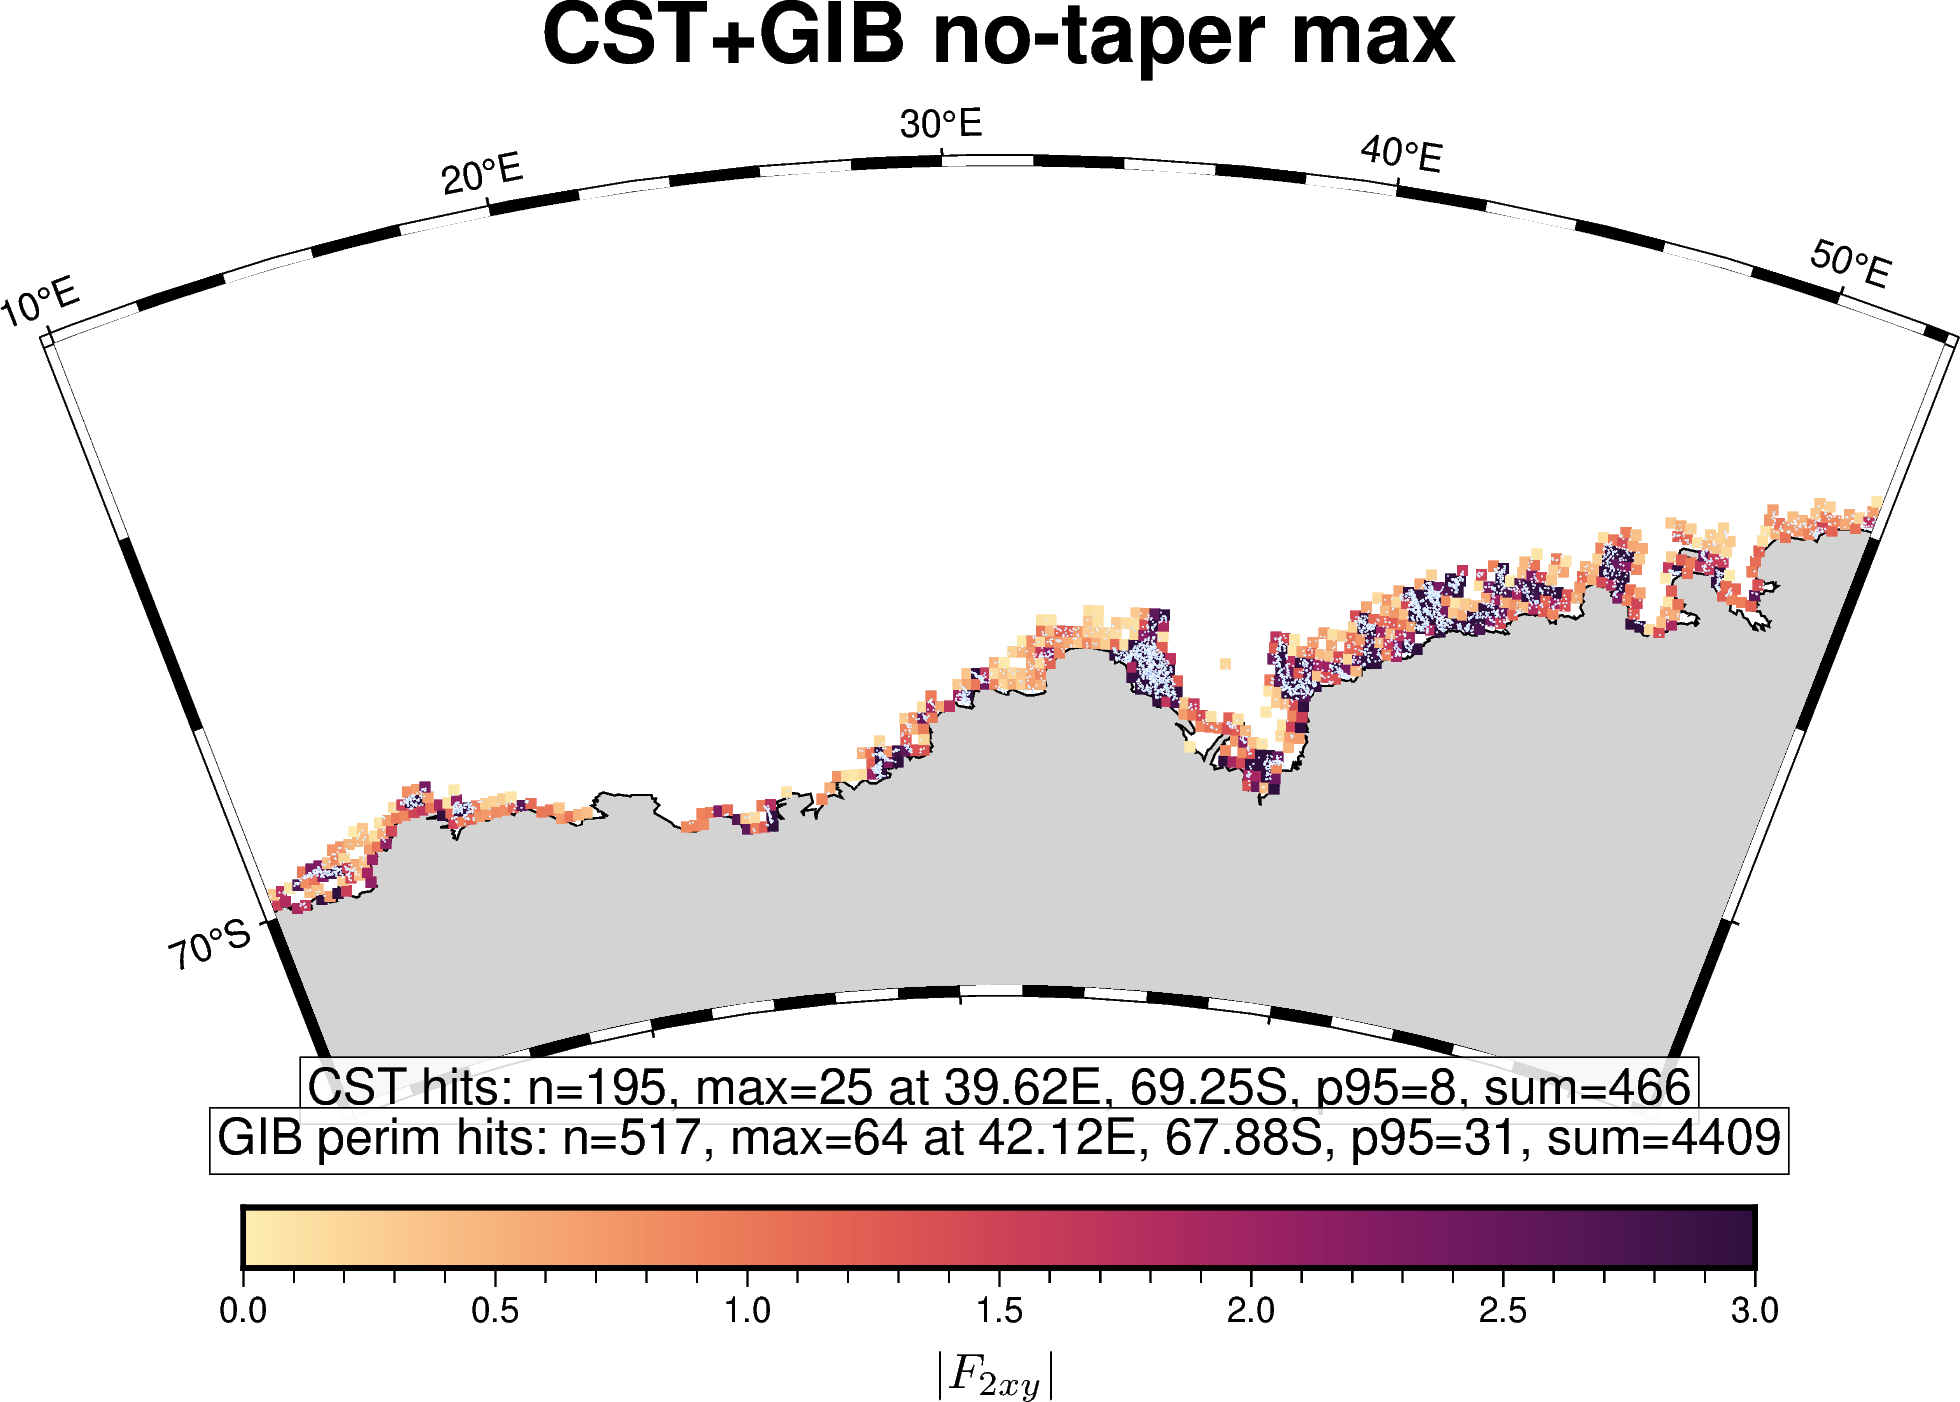

Saved: /g/data/gv90/da1339/GRAPHICAL/LD-pub-workspace/form-factors/cmb/no_taper/EIO/FF_cmb_meth-max_cst-v7p9_GIB-v1p2_EIO.png


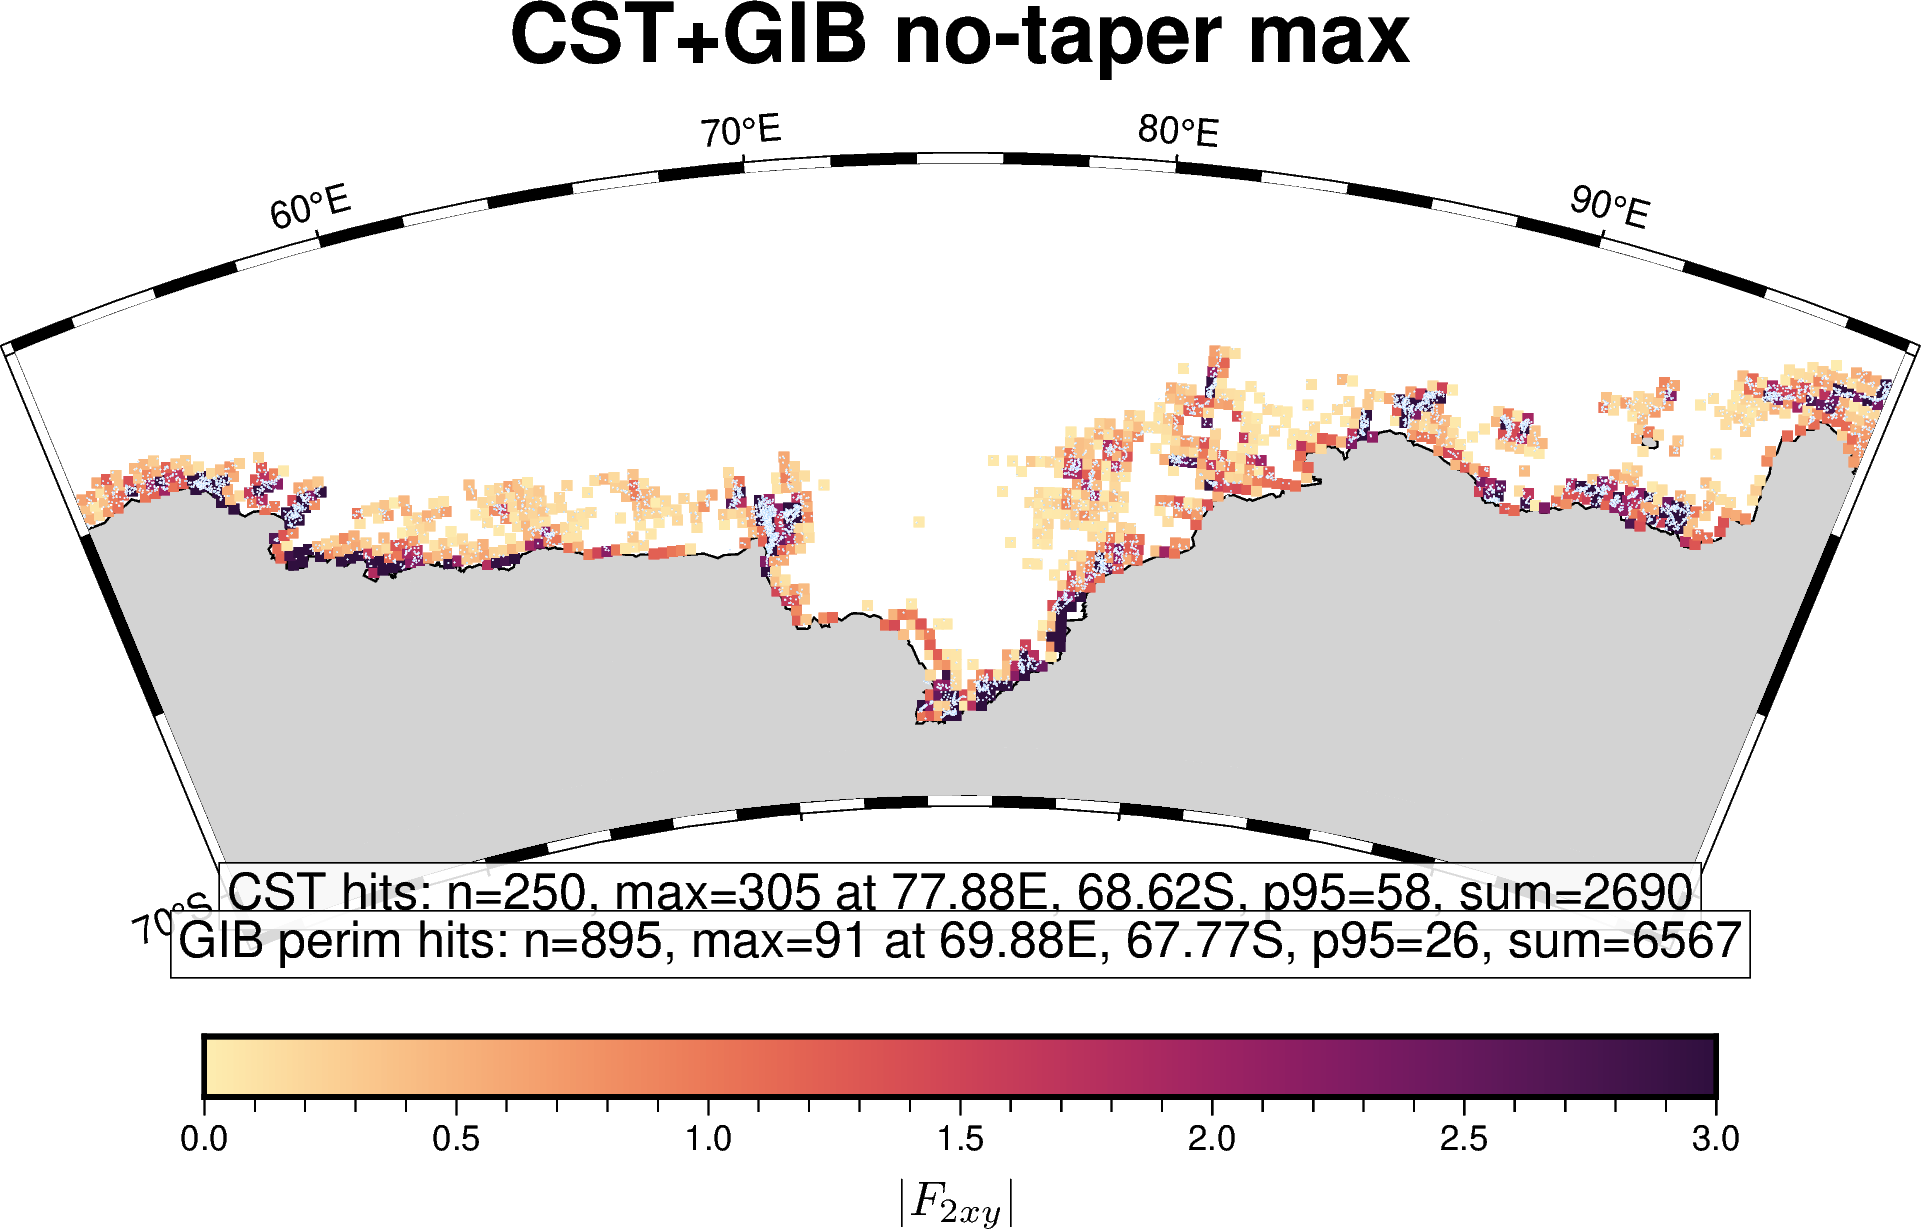

Saved: /g/data/gv90/da1339/GRAPHICAL/LD-pub-workspace/form-factors/cmb/no_taper/Aus/FF_cmb_meth-max_cst-v7p9_GIB-v1p2_Aus.png


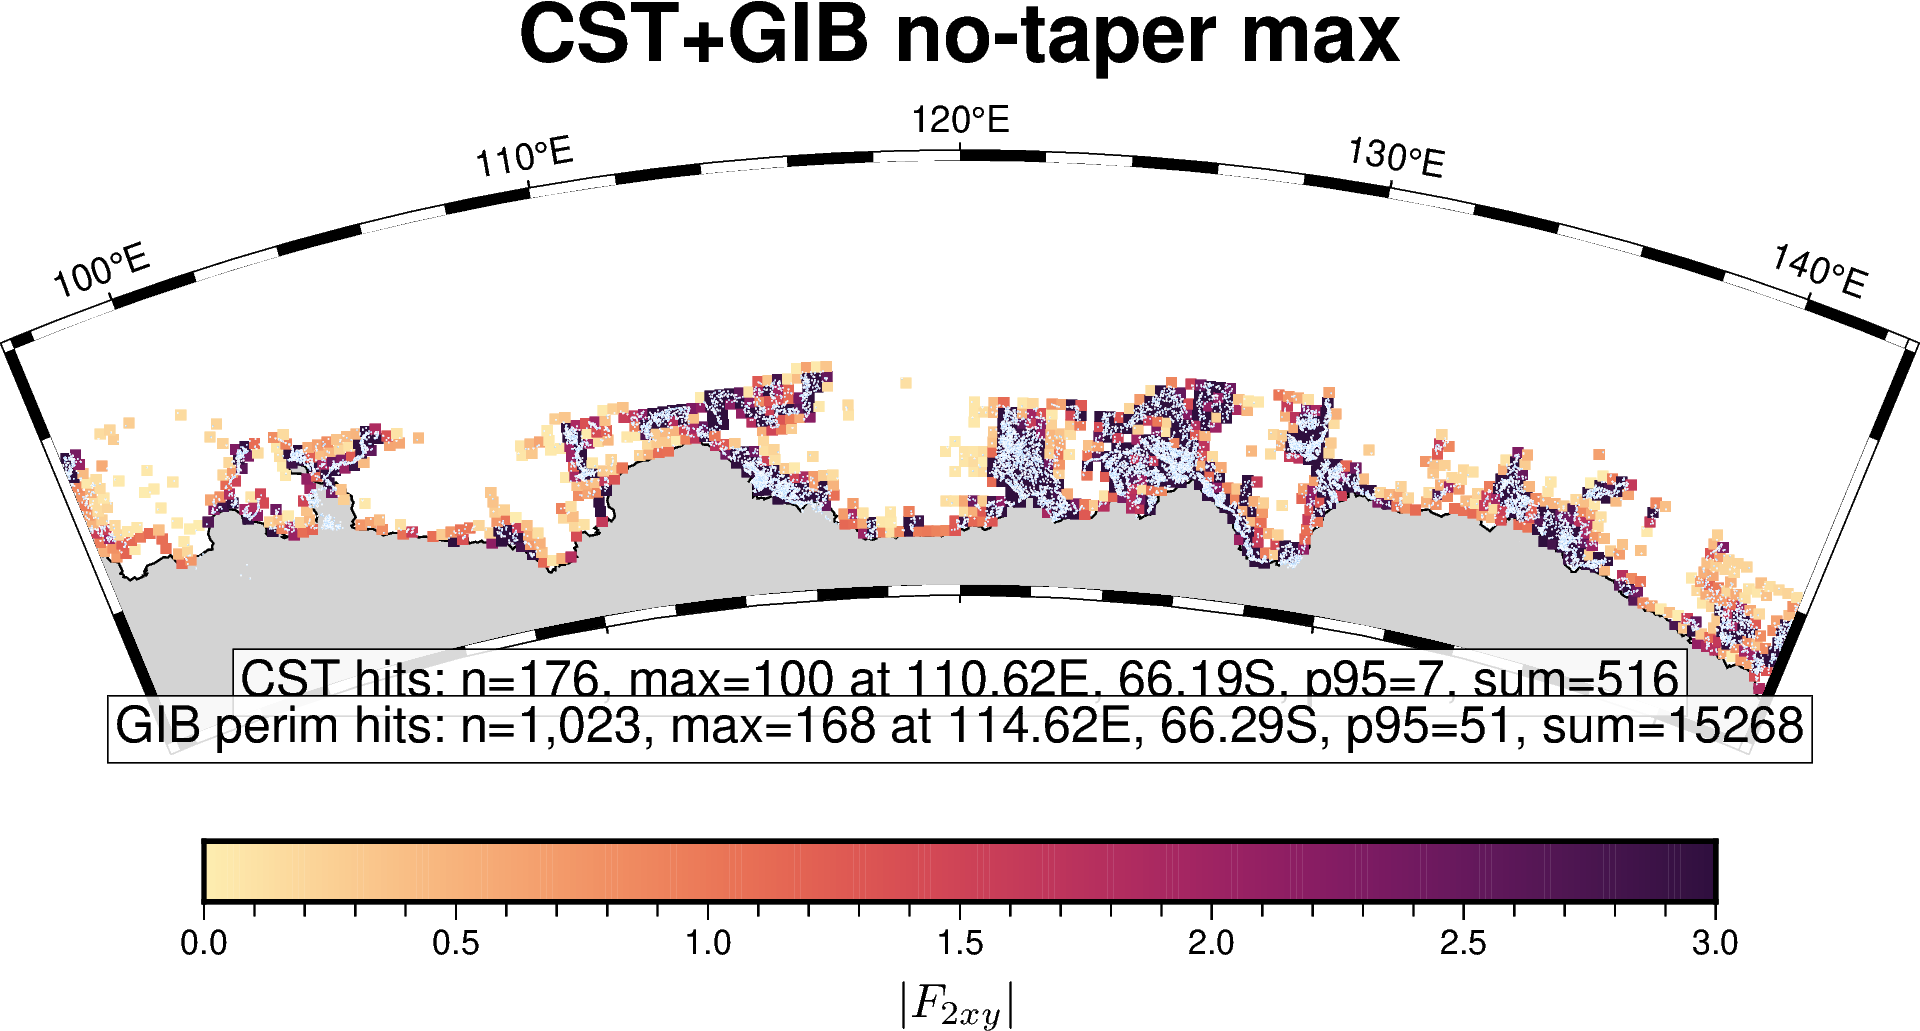

Saved: /g/data/gv90/da1339/GRAPHICAL/LD-pub-workspace/form-factors/cmb/no_taper/VOL/FF_cmb_meth-max_cst-v7p9_GIB-v1p2_VOL.png


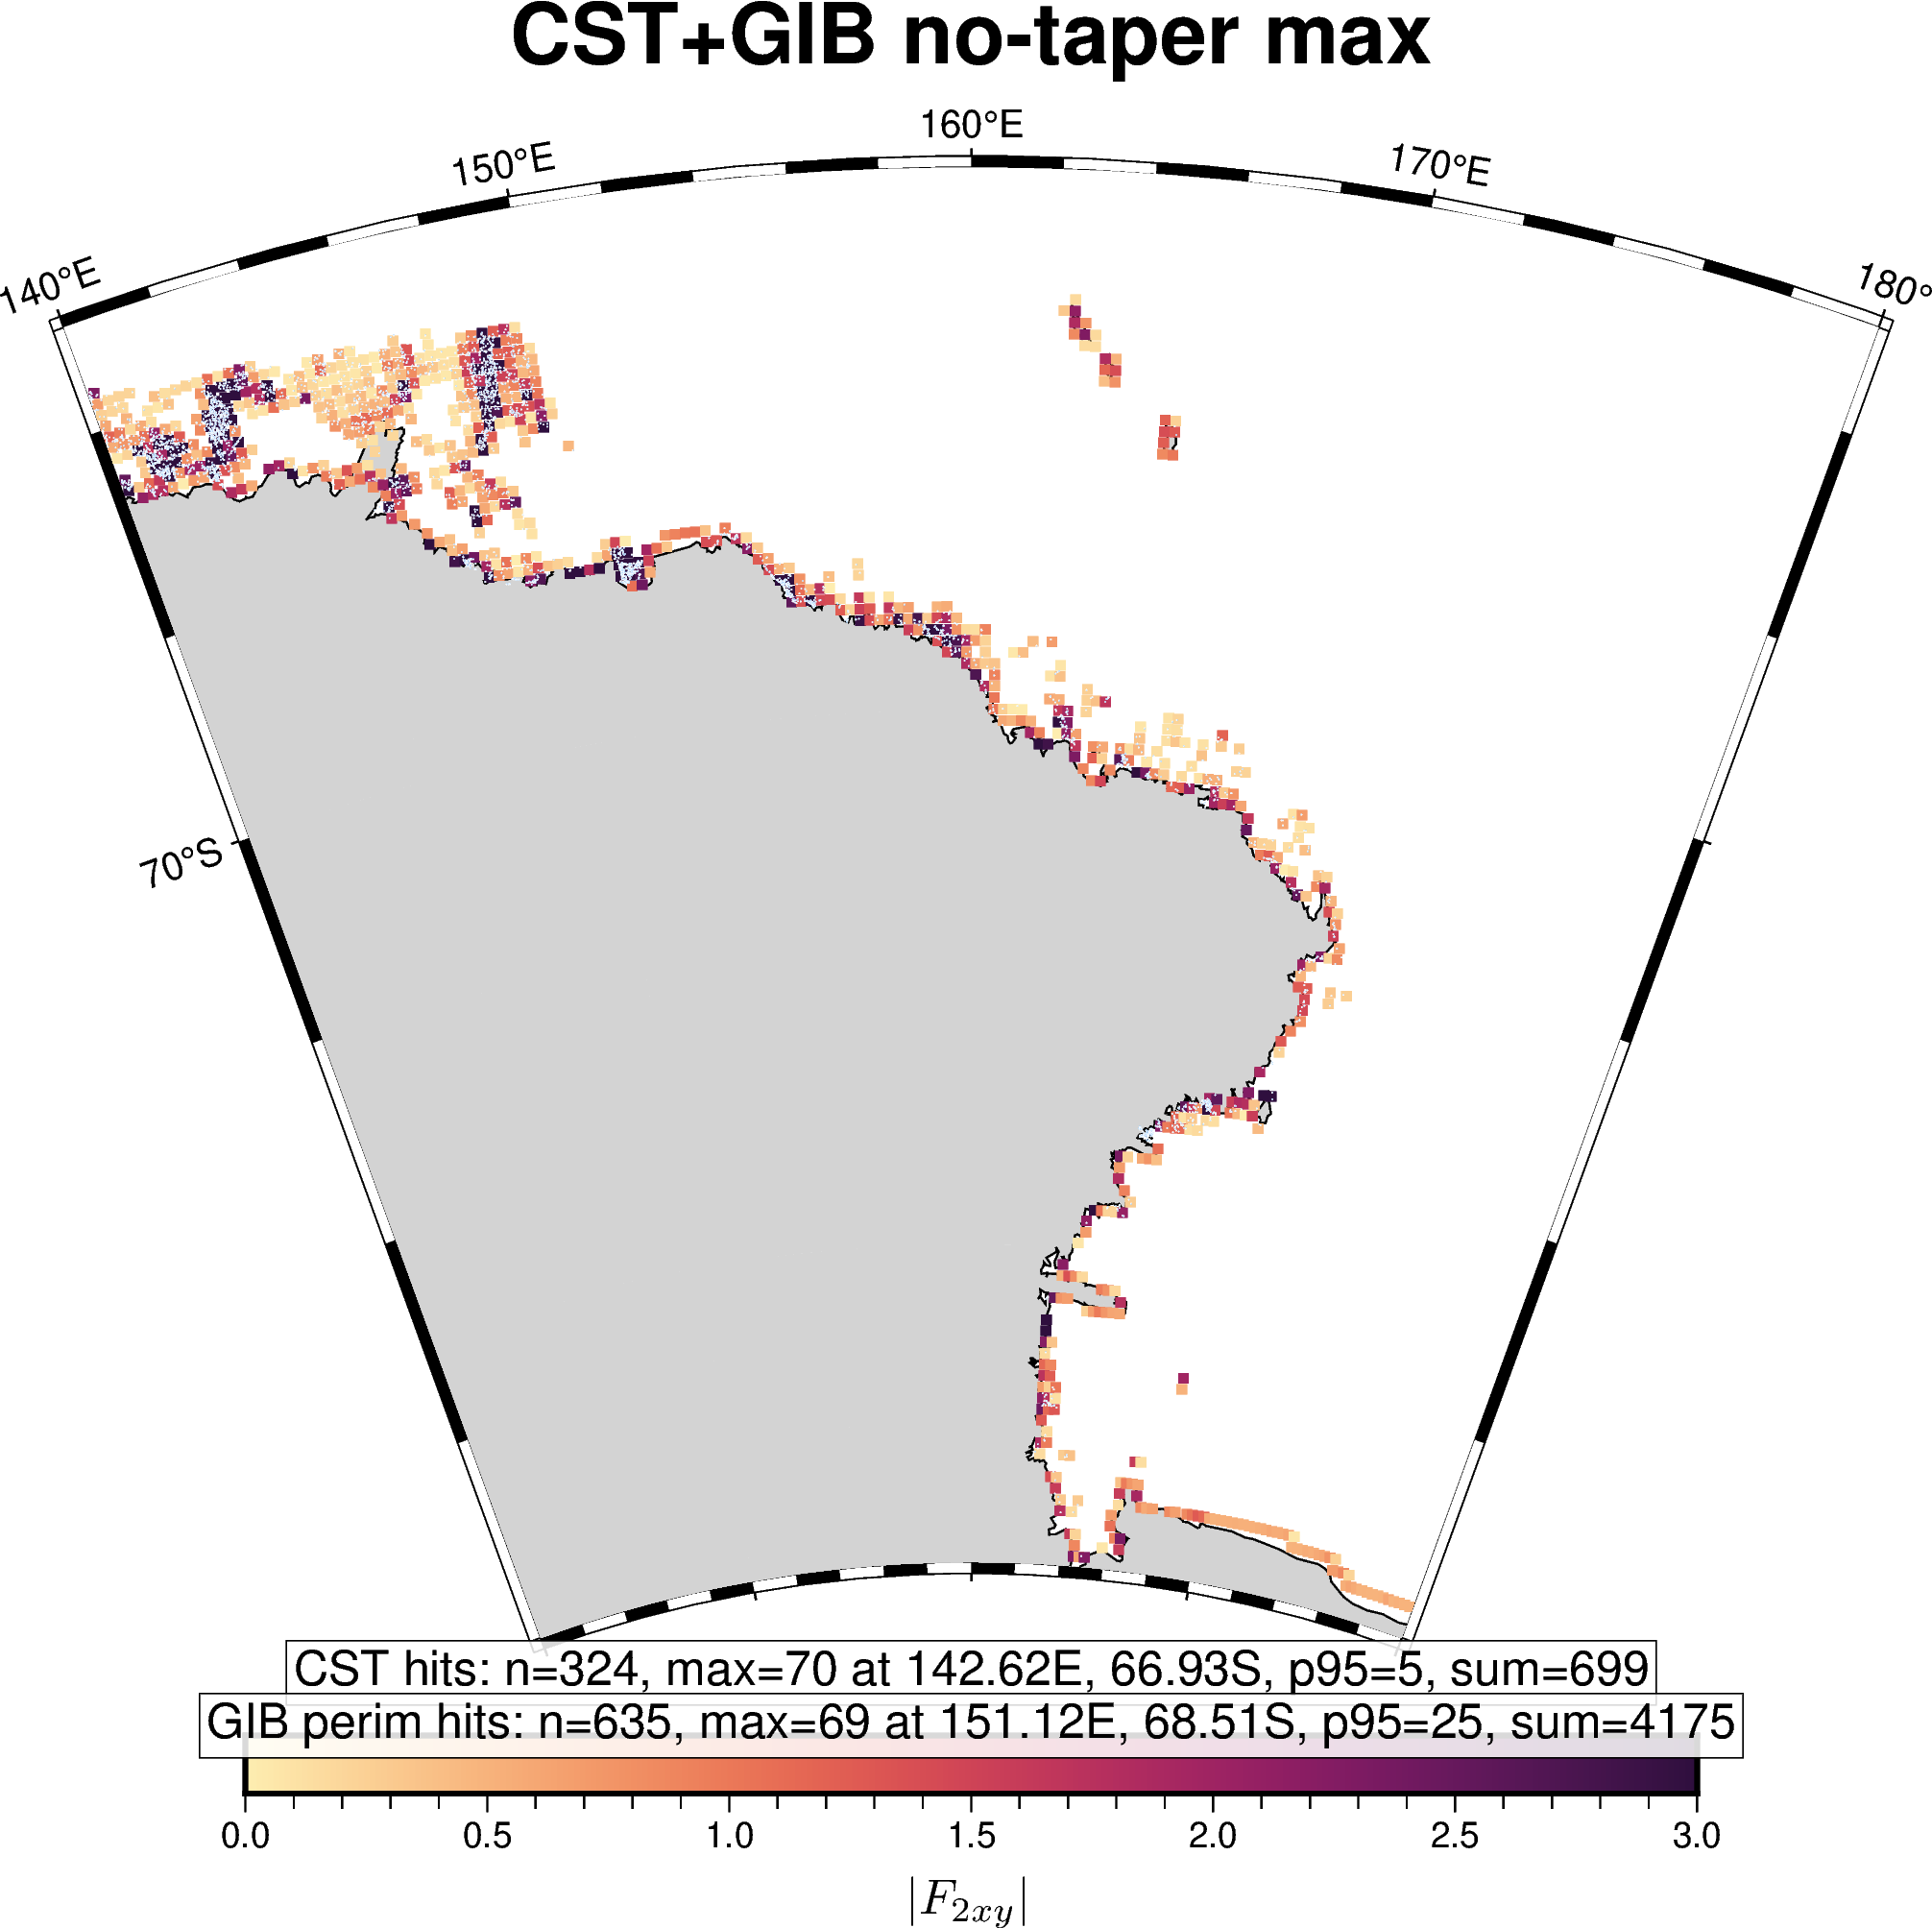

Saved: /g/data/gv90/da1339/GRAPHICAL/LD-pub-workspace/form-factors/cmb/no_taper/AS/FF_cmb_meth-max_cst-v7p9_GIB-v1p2_AS.png


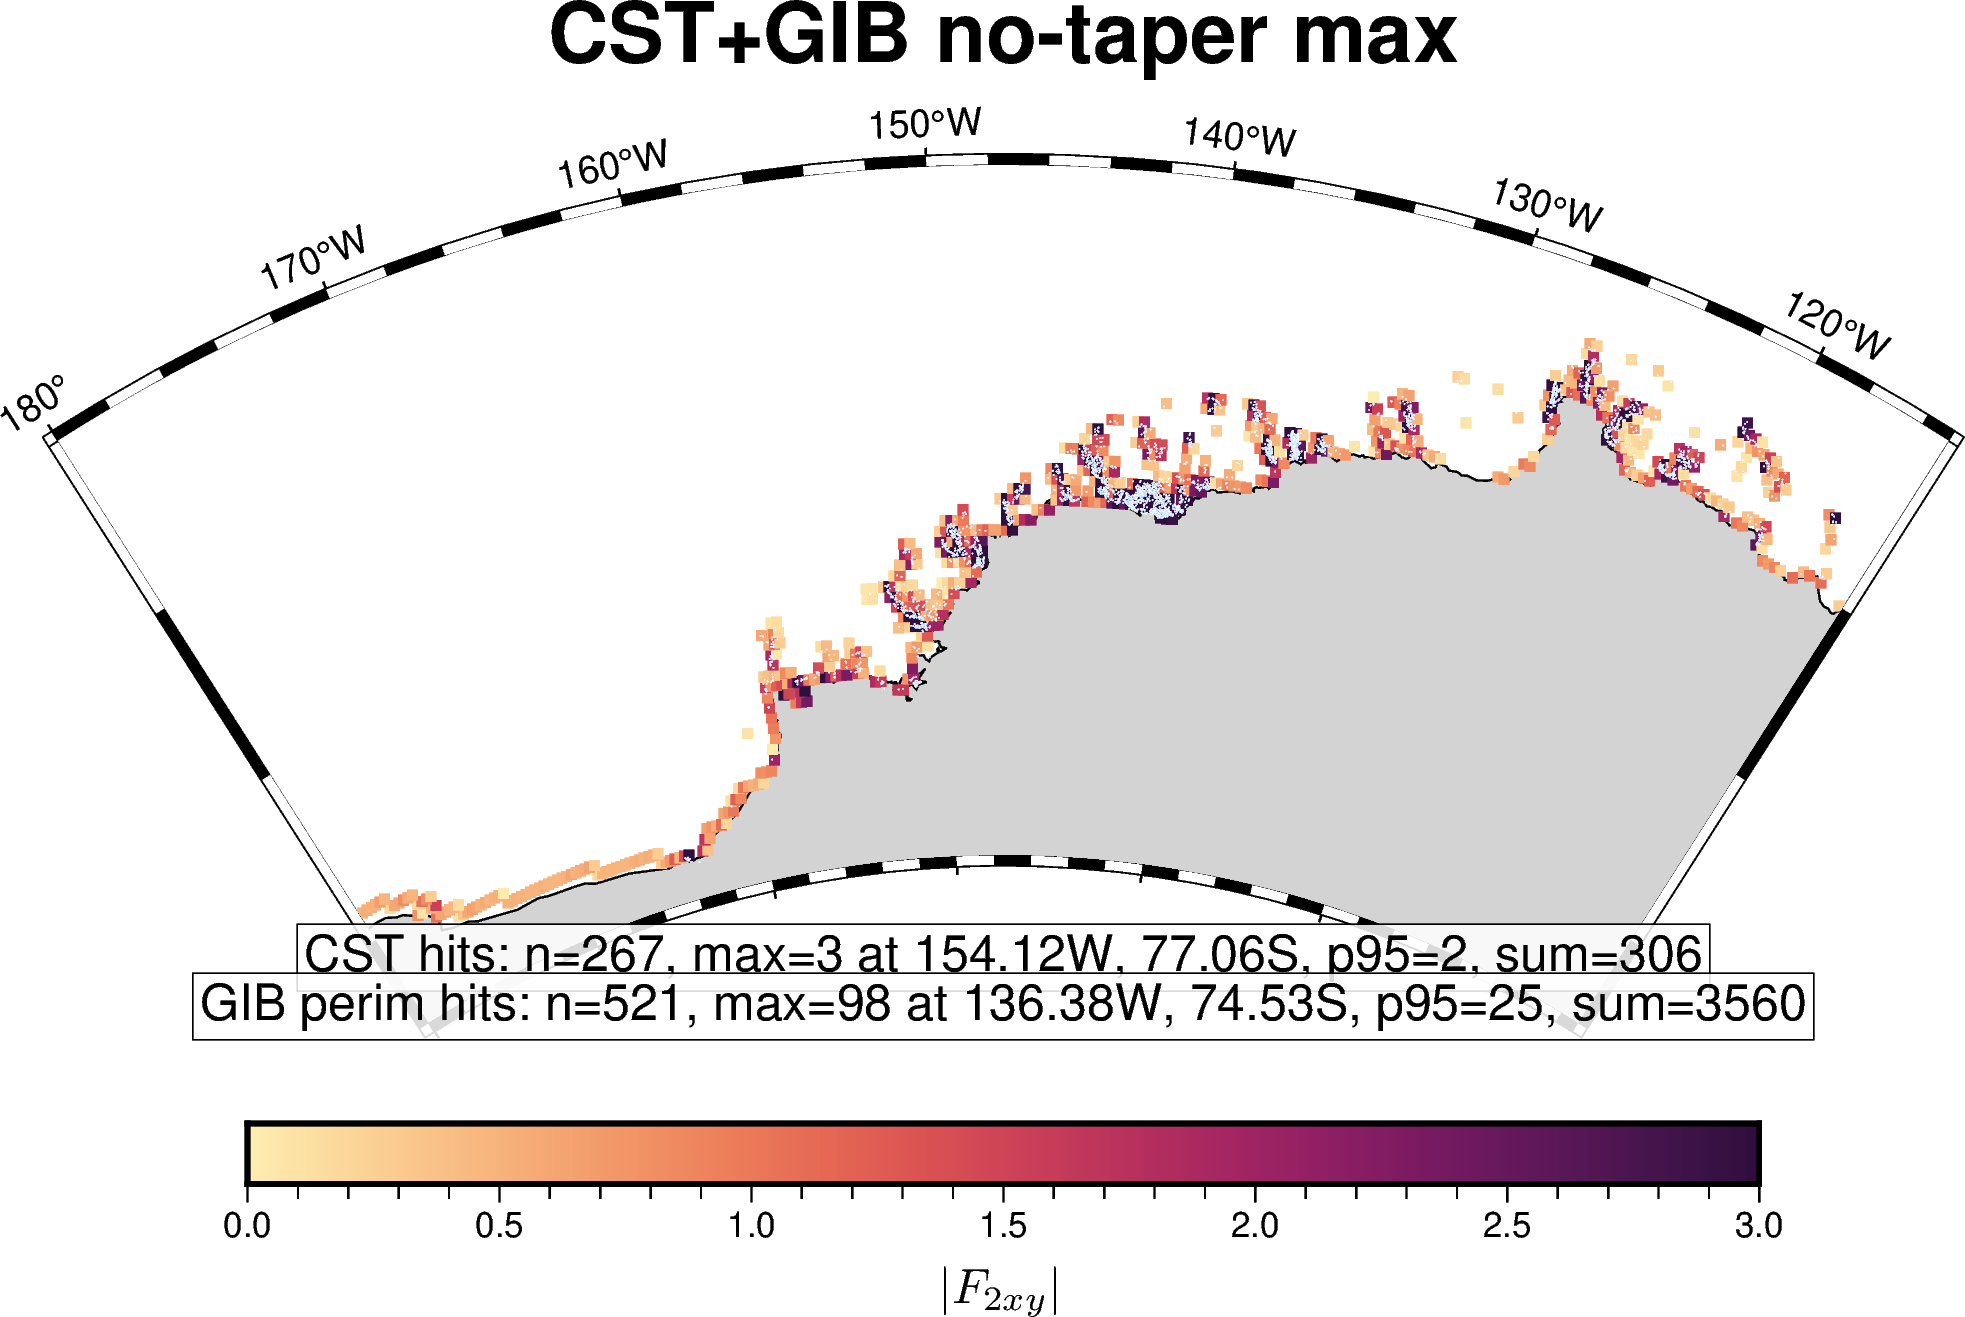

Saved: /g/data/gv90/da1339/GRAPHICAL/LD-pub-workspace/form-factors/cmb/no_taper/BS/FF_cmb_meth-max_cst-v7p9_GIB-v1p2_BS.png


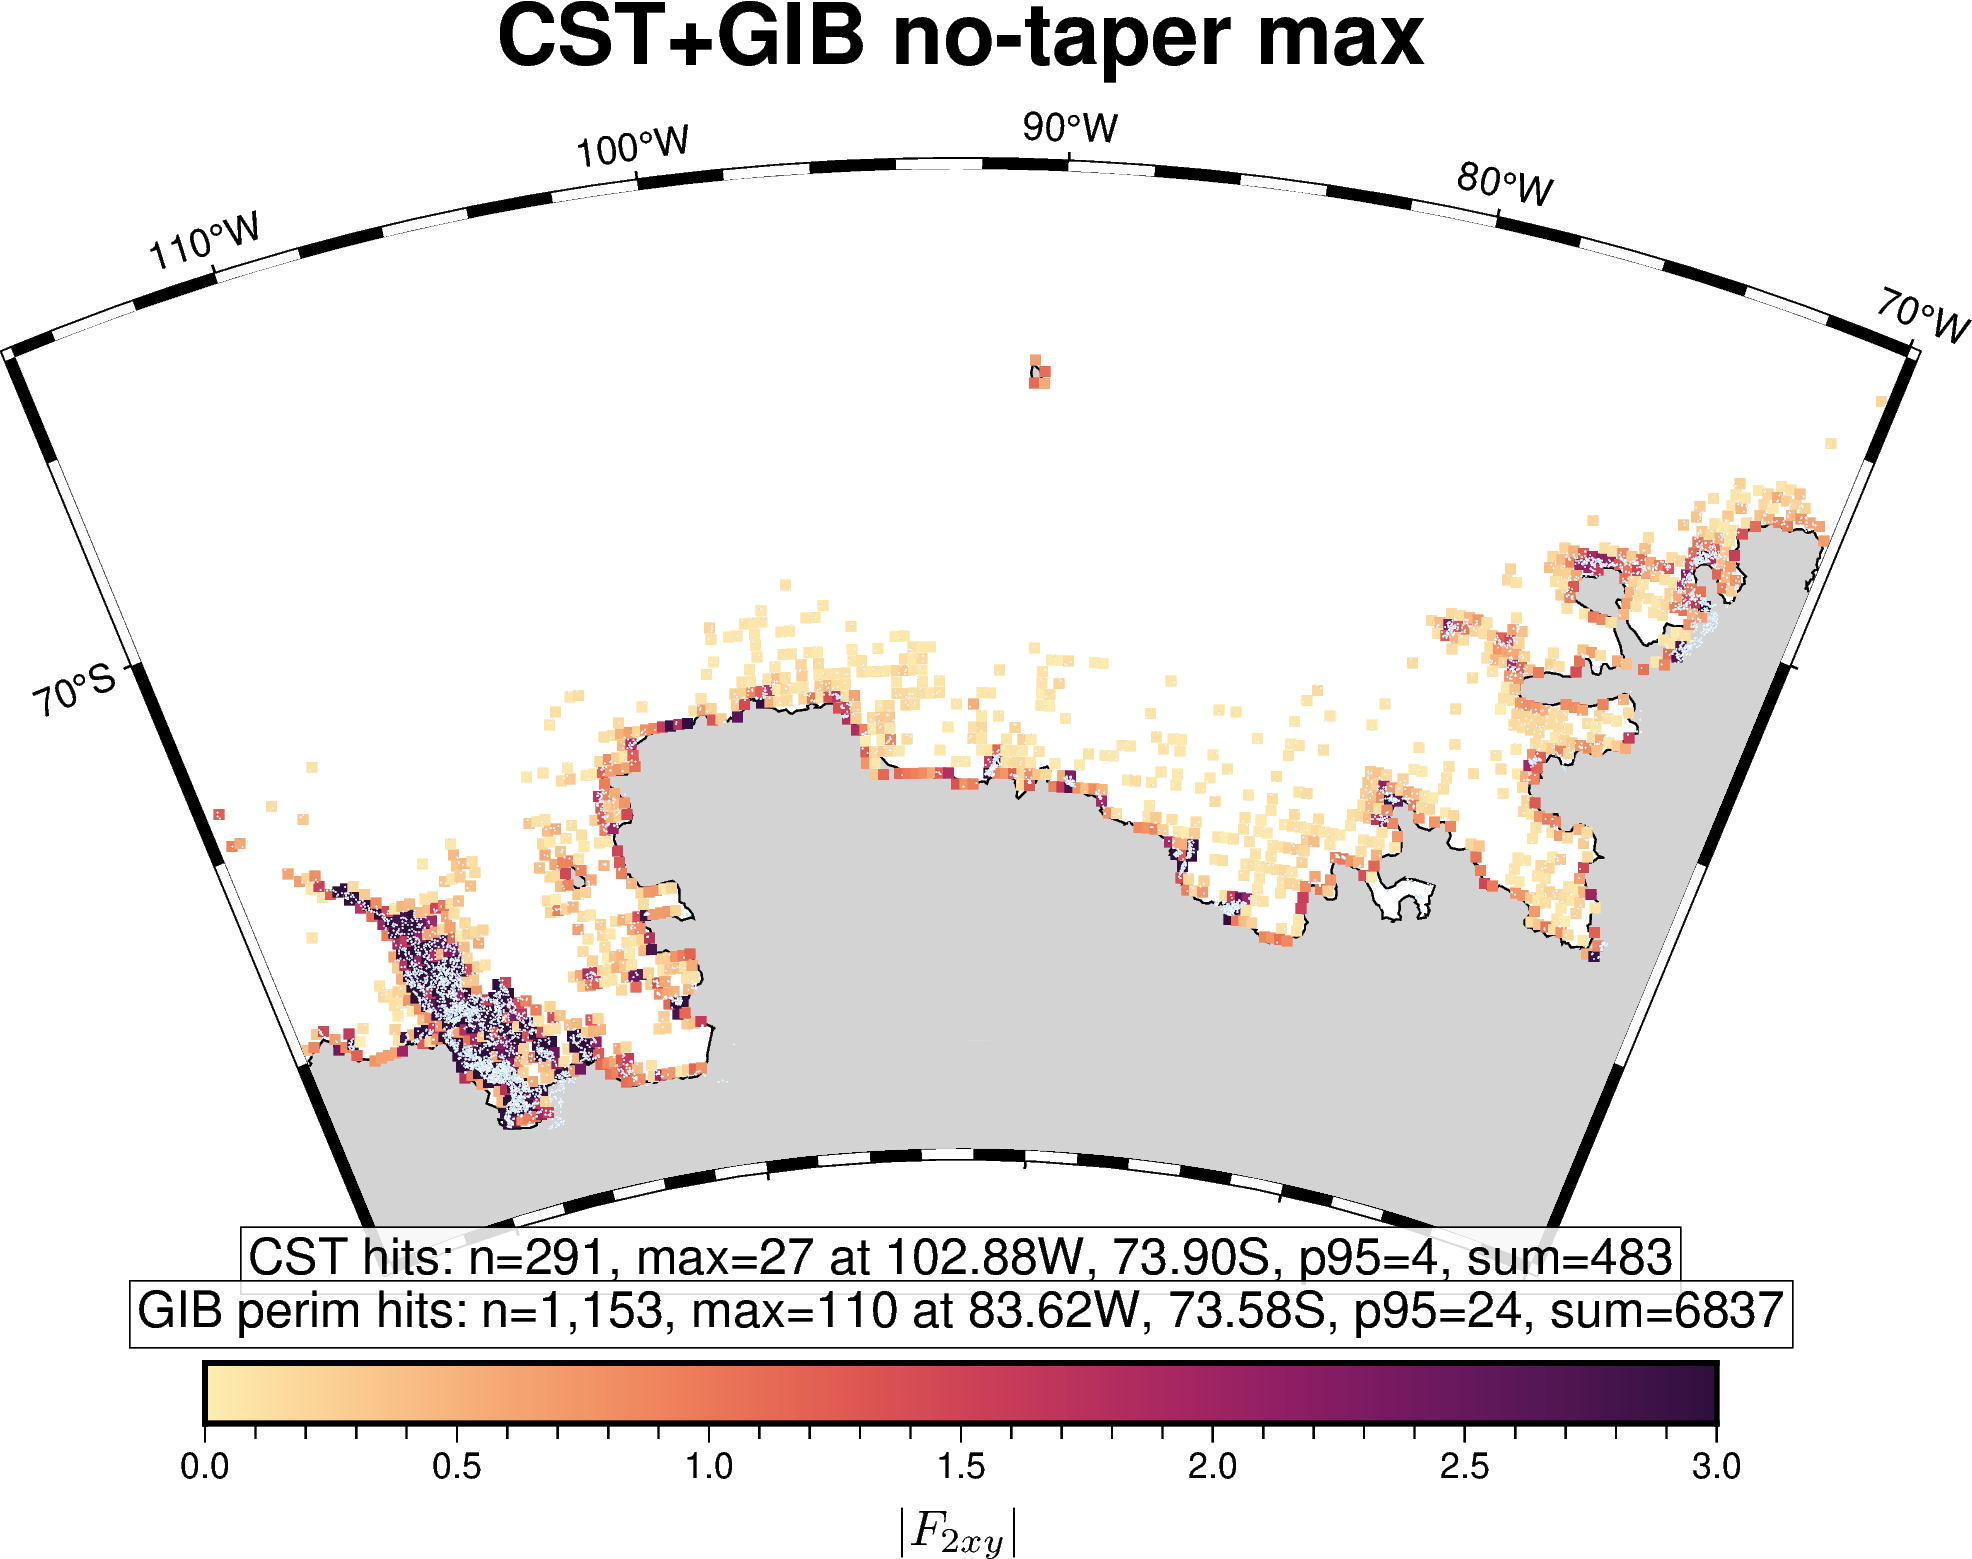

Saved: /g/data/gv90/da1339/GRAPHICAL/LD-pub-workspace/form-factors/cmb/no_taper/WS/FF_cmb_meth-max_cst-v7p9_GIB-v1p2_WS.png


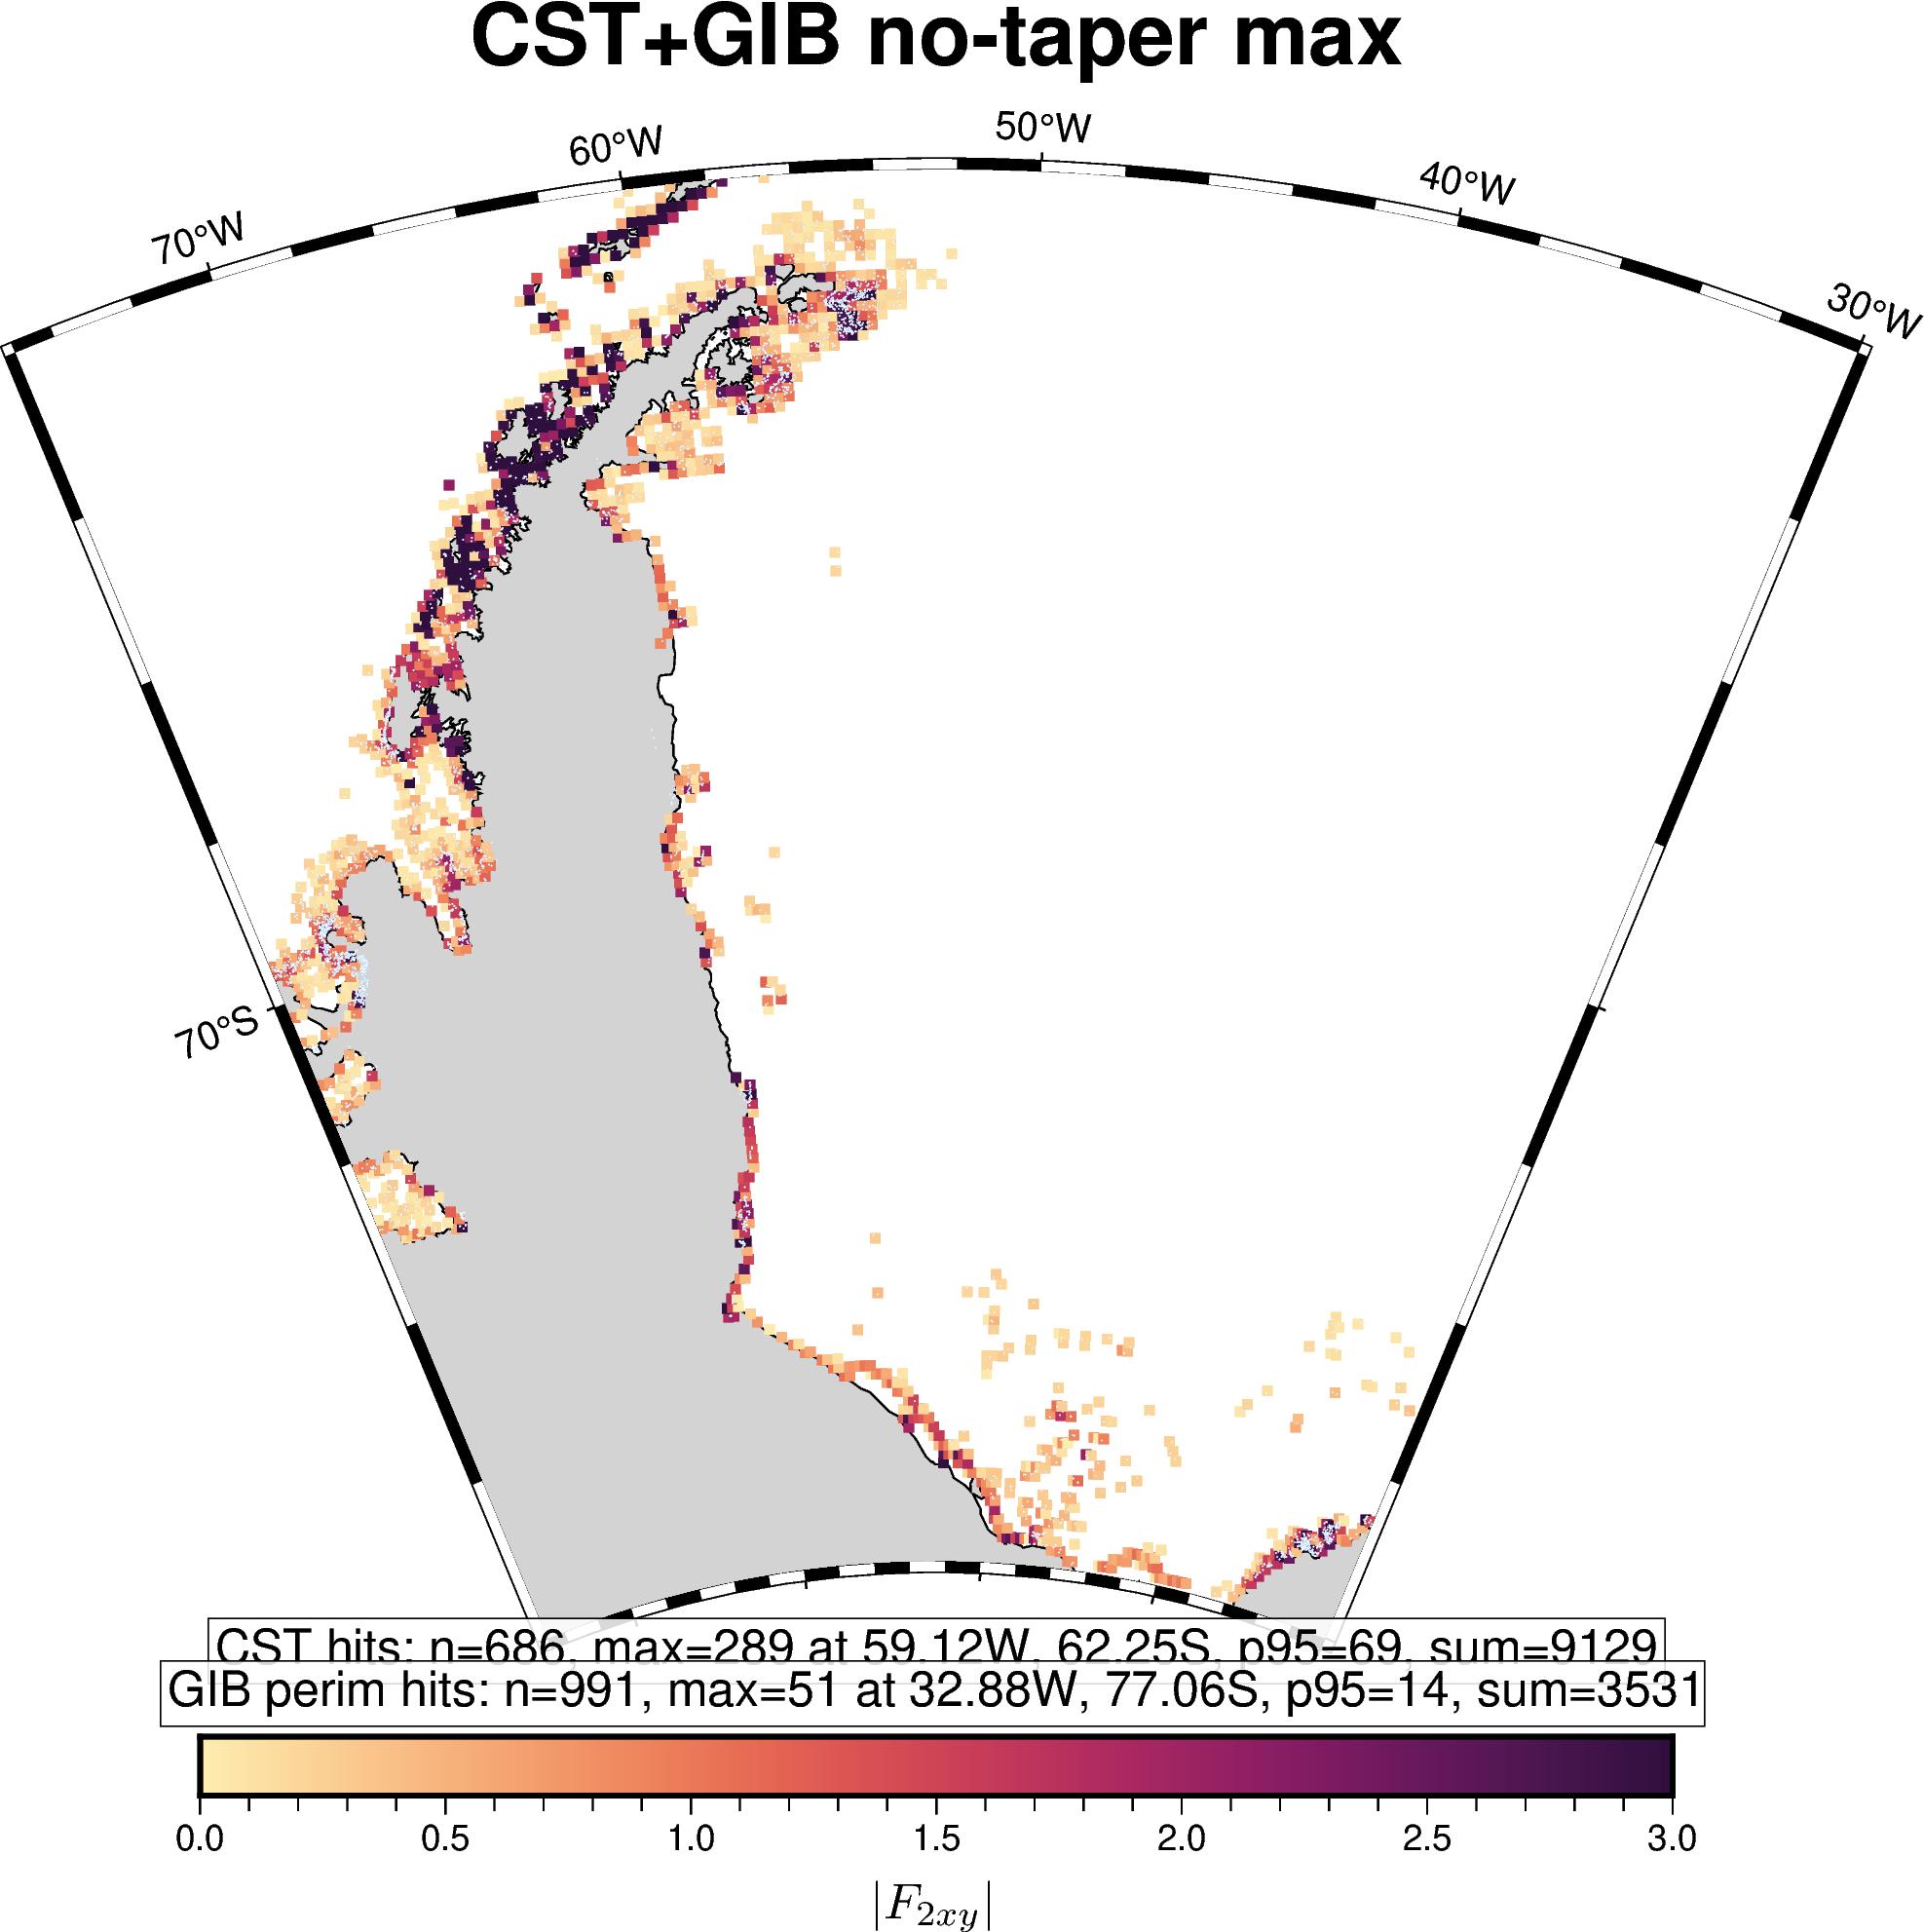

In [14]:
# Combined
with xr.open_dataset(P_FF_cmb) as ds:
    D_ = D_root_out / 'cmb' / 'no_taper'
    for region_name in ALL_REGIONS:
        P_png   = D_ / region_name / f'FF_cmb_meth-{cmb_meth}_cst-{cst_ver}_GIB-{gib_ver}_{region_name}.png'
        tit_str = f'CST+GIB no-taper {cmb_meth}'
        plot_form_factor_pygmt(ds                = ds,
                               out               = P_png,
                               title             = tit_str,
                               region_name       = region_name,
                               ANTARCTIC_REGIONS = ANTARCTIC_REGIONS,
                               product_kind      = 'cmb',
                               diagnostics       = ['coast_n_source_hits', 'GIB_n_perimeter_hits'],
                               show_diagnostics  = True,
                               gib_points        = GIB_pts,
                               show_gib_points   = SHOW_GIB_POINTS_ON_CMB)

## CICE namelist reminder

Use the combined product as `F2_file` and keep the variables as `FFx`/`FFy`.

In [ ]:
print(f"F2_file       = '{P_FF_cmb}'")
print("F2x_varname   = 'FFx'")
print("F2y_varname   = 'FFy'")
print("F2_map_method = 'max'    ! or 'avg'; this maps T-cell source fields to E/N faces inside CICE")